In [1]:
# papermill parameters -- overridden at runtime by pipeline.py
ARTIFACT_DIR = ""
SAMPLE_DIR   = ""
MODEL_ID     = ""
SNAPSHOT_ID  = ""  # optional override; notebook resolves from manifest if empty


In [2]:
# Parameters
ARTIFACT_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_s_fw60_2101_2605"
SAMPLE_DIR = "D:\\repos\\chronoquant\\artifacts\\lgbm_solusdt_s_fw60_2101_2605"
MODEL_ID = "lgbm_solusdt_s_fw60_2101_2605"
SNAPSHOT_ID = "solusdt_fw60_2101_2605__21668185"


## Cél

A `lgbm_solusdt_l_fw60_2101_2605` long modell összes feature-jének prediktív erejét vizsgáljuk `ContinuousOptimalBinning` segítségével (max 10 bin per feature). Minden feature-re:
- Optimális bin-ekre osztjuk a feature értékeit (max 10 bin)
- A bin-enkénti target átlagot scatter ploton ábrázoljuk regressziós egyenessel
- IV (Information Value) és MI (Mutual Information) értéket számolunk a prediktív erő összehasonlíthatóságához

**Struktúra:** Egy szekció = egy feature csoport (Momentum, Trend, Volatility stb.). Minden csoportnál: IV tábla → korrelációs mátrix → tabset (egy fül = egy feature).
**Összefoglaló tábla** a plotok után.

In [3]:
import sys
import io
import base64
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown
from optbinning import ContinuousOptimalBinning
from sklearn.feature_selection import mutual_info_regression

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))

import utils
from analyst.lib.table_formatting import display_analysis_table, analysis_table_html

# ── Matplotlib style ──────────────────────────────────────────────────────────
CQ_COLORS = {
    "blue":       "#1696d2",
    "black":      "#000000",
    "gray_dark":  "#353535",
    "gray":       "#696969",
    "gray_light": "#d2d2d2",
    "yellow":     "#fdbf11",
    "orange":     "#f15a24",
    "red":        "#ec008b",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   CQ_COLORS["gray"],
    "axes.labelcolor":  CQ_COLORS["gray_dark"],
    "xtick.color":      CQ_COLORS["gray_dark"],
    "ytick.color":      CQ_COLORS["gray_dark"],
    "grid.color":       CQ_COLORS["gray_light"],
    "grid.linewidth":   0.8,
    "axes.grid":        True,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

# ── Model constants ───────────────────────────────────────────────────────────
# ── Runtime paraméterek (papermill injektálja, fallback fejlesztéshez) ───────
MODEL_ID    = MODEL_ID    or "lgbm_solusdt_l_fw60_2101_2605"
SNAPSHOT_ID = SNAPSHOT_ID or "solusdt_fw60_2101_2605__21668185"
ARTIFACT_DIR_PATH = Path(ARTIFACT_DIR) if ARTIFACT_DIR else (
    _root / "artifacts" / MODEL_ID
)
_direction  = MODEL_ID.split("_")[2] if len(MODEL_ID.split("_")) > 2 else "l"
TARGET      = "long_mfe_fw60" if _direction == "l" else "short_mfe_fw60"

# ── GROUP_MAP ─────────────────────────────────────────────────────────────────
# FONTOS: prefix-egyeztetés sorrendérzékeny — specifikusabb prefix ELŐBB!
GROUP_MAP = {
    # Accel — delta prefixek a feat_rsi/roc/return_ előtt
    "feat_rsi_delta": "Accel", "feat_roc_delta": "Accel",
    "feat_return_momentum_delta": "Accel",
    # Interaction — a feat_rsi/feat_volume_ általánosabb prefixek előtt
    "feat_rsi_x_trend": "Interaction", "feat_volume_x_momentum": "Interaction",
    # Momentum
    "feat_rsi": "Momentum", "feat_roc": "Momentum", "feat_stoch_k": "Momentum",
    "feat_stoch_d": "Momentum", "feat_williams_r": "Momentum", "feat_cci": "Momentum",
    # Trend Slope bővítés — feat_ema_slope_ a feat_ema_ratio előtt
    "feat_ema_slope_": "Trend Slope",
    # Trend
    "feat_sma_ratio": "Trend", "feat_ema_ratio": "Trend", "feat_wma_ratio": "Trend",
    "feat_kama_ratio": "Trend", "feat_macd_signal": "Trend", "feat_macd_diff": "Trend",
    "feat_macd": "Trend", "feat_adx_pos": "Trend", "feat_adx_neg": "Trend",
    "feat_adx": "Trend",
    # Volatility — feat_atr_dist_ → Market Structure, feat_atr → Volatility
    "feat_bb_width": "Volatility", "feat_bb_position": "Volatility",
    "feat_atr_dist_high": "Market Structure", "feat_atr_dist_low": "Market Structure",
    "feat_atr": "Volatility", "feat_natr": "Volatility", "feat_hist_vol": "Volatility",
    "feat_parkinson_vol": "Volatility", "feat_gk_vol": "Volatility",
    # Volume — specifikusabb prefix előbb
    "feat_volume_confirmed_return_": "Volume",
    "feat_volume_accel_": "Volume",
    "feat_volume_rank_": "Volume",
    "feat_volume_sma": "Volume", "feat_volume_ratio": "Volume",
    "feat_obv_roc": "Volume", "feat_obv": "Volume",
    "feat_mfi": "Volume", "feat_ad_line": "Volume", "feat_cmf": "Volume",
    # Price Action — feat_returns_ (specifikus) a feat_return_ (általános) előtt
    "feat_returns_log": "Price Action", "feat_returns_sma": "Price Action",
    "feat_returns_std": "Price Action", "feat_returns_skew": "Price Action",
    "feat_returns_kurt": "Price Action",
    "feat_hml_range": "Price Action", "feat_ohlc_range": "Price Action",
    "feat_close_position": "Price Action",
    # Market Structure — specifikus session dist prefixek először
    "feat_prev_session_high_dist": "Market Structure",
    "feat_prev_session_low_dist": "Market Structure",
    "feat_rolling_drawdown_": "Market Structure",
    "feat_dist_rolling_": "Market Structure",
    "feat_range_expansion_": "Market Structure",
    "feat_recovery_ratio": "Market Structure", "feat_max_drawdown": "Market Structure",
    "feat_time_since_high": "Market Structure", "feat_time_since_low": "Market Structure",
    "feat_efficiency_ratio": "Market Structure",
    # Regime / Stats
    "feat_regime_rank": "Regime Rank", "feat_return_autocorr": "Autocorrelation",
    "feat_variance_ratio": "Autocorrelation",
    # Candle Pattern — specifikus wick prefixek a feat_wick_ratio előtt
    "feat_lower_wick_ratio": "Candle Pattern",
    "feat_upper_wick_ratio": "Candle Pattern",
    "feat_signed_body_": "Candle Pattern",
    "feat_wick_imbalance_": "Candle Pattern",
    "feat_doji": "Candle Pattern", "feat_hammer": "Candle Pattern",
    "feat_shooting_star": "Candle Pattern", "feat_inside_bar": "Candle Pattern",
    "feat_outside_bar": "Candle Pattern", "feat_engulf_bull": "Candle Pattern",
    "feat_engulf_bear": "Candle Pattern", "feat_bull_bars_ratio": "Candle Pattern",
    "feat_body_ratio": "Candle Pattern", "feat_wick_ratio": "Candle Pattern",
    # Trend Slope / LR
    "feat_lr_slope": "Trend Slope", "feat_lr_r2": "Trend Slope",
    "feat_lr_residual": "Trend Slope", "feat_trend_slope": "Trend Slope",
    # Tail Risk
    "feat_pos_return_mean": "Tail Risk", "feat_neg_return_mean": "Tail Risk",
    "feat_return_asymmetry": "Tail Risk",
    # Gap
    "feat_gap_open_abs_sma": "Gap", "feat_gap_open": "Gap",
    # Ichimoku — specifikus prefixek először
    "feat_tenkan_kijun_": "Ichimoku",
    "feat_price_vs_": "Ichimoku",
    "feat_tenkan_ratio": "Ichimoku", "feat_kijun_ratio": "Ichimoku",
    "feat_senkou_b_ratio": "Ichimoku", "feat_ichimoku_cloud_thickness": "Ichimoku",
    # Donchian
    "feat_donchian_width": "Donchian", "feat_donchian_position": "Donchian",
    "feat_donchian_breakout": "Donchian",
    # Time / Session
    "feat_hour_sin": "Time/Session", "feat_hour_cos": "Time/Session",
    "feat_dayofweek_sin": "Time/Session", "feat_dayofweek_cos": "Time/Session",
    "feat_weekend": "Time/Session", "feat_session_asia": "Time/Session",
    "feat_session_europe": "Time/Session", "feat_session_us": "Time/Session",
    "feat_bars_into_session_norm": "Time/Session", "feat_day_range_position": "Time/Session",
    "feat_day_open_return": "Time/Session", "feat_weekly_open_return": "Time/Session",
    # Return Distance
    "feat_dist_sma": "Return Distance", "feat_dist_bb": "Return Distance",
    # Price Action bővítés — feat_return_ UTÁNA (feat_returns_ és egyéb spec. prefixek már fent)
    "feat_return_z_": "Price Action",
    "feat_vol_adj_return_": "Price Action",
    "feat_return_": "Price Action",
    # Swing — új csoport
    "feat_higher_high_": "Swing",
    "feat_higher_low_": "Swing",
    "feat_lower_high_": "Swing",
    "feat_lower_low_": "Swing",
    "feat_swing_": "Swing",
    "feat_directional_agreement_": "Swing",
    # Taker Flow — új csoport
    "feat_taker_": "Taker Flow",
    "feat_avg_trade_": "Taker Flow",
    "feat_trade_count_": "Taker Flow",
    "feat_quote_volume_": "Taker Flow",
}


def assign_group(feat_name: str) -> str:
    for prefix, group in GROUP_MAP.items():
        if feat_name.startswith(prefix):
            return group
    return "Other"


# ── Data load ─────────────────────────────────────────────────────────────────
conn = utils.open_lab_connection("solusdt")
df_all = conn.execute(f"""
    SELECT s.*, m.split
    FROM snap."{SNAPSHOT_ID}" AS s
    INNER JOIN model."{MODEL_ID}__sample" AS m
        ON s.open_time = m.open_time
    ORDER BY s.open_time
""").fetchdf()
conn.close()

feat_cols = [c for c in df_all.columns if c.startswith("feat_")]
df_train  = df_all[df_all["split"] == 0].copy()

# ── Group index ───────────────────────────────────────────────────────────────
groups_df = pd.DataFrame([
    {"Group": assign_group(f), "Feature": f}
    for f in sorted(feat_cols)
]).sort_values(["Group", "Feature"]).reset_index(drop=True)

# ── Quality pre-filter (null / inf / variance) ──────────────────────────────
_null_rates = df_train[feat_cols].isnull().mean()
_inf_rates  = df_train[feat_cols].apply(lambda c: c.apply(lambda v: v == float('inf') or v == float('-inf')).mean())
_variances  = df_train[feat_cols].var()
_quality_bad = set(
    _null_rates[_null_rates > 0.01].index.tolist() +
    _inf_rates[_inf_rates   > 0.001].index.tolist() +
    _variances[_variances   < 1e-8].index.tolist()
)
feat_cols_quality_dropped = sorted(_quality_bad)
feat_cols = [f for f in feat_cols if f not in _quality_bad]
display(Markdown(f"**Quality szűrő:** {len(feat_cols_quality_dropped)} feature kizárva | Maradék: {len(feat_cols)}"))

n_other = (groups_df["Group"] == "Other").sum()
display(Markdown(
    f"**Adatbetöltés kész** | Train sorok: {len(df_train):,} "
    f"| Feature-ök: {len(feat_cols)} "
    f"| Csoportok: {groups_df['Group'].nunique()} "
    f"| Other (nem mappelt): {n_other}"
))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Quality szűrő:** 2 feature kizárva | Maradék: 206

**Adatbetöltés kész** | Train sorok: 37,939 | Feature-ök: 206 | Csoportok: 17 | Other (nem mappelt): 0

In [4]:
#| echo: false
import re as _re

# ── Csoport-szintű leírások ───────────────────────────────────────────────────
GROUP_DOCS = {
    "Accel": """\
**Gyorsulás (Accel)** — momentum-indikátorok változásának sebessége (2. derivált).
Azt méri, hogy az RSI, ROC és a 10-bári return-momentum az előző W bárhoz képest mennyit változott.
Gyorsuló pozitív momentum erősödő trendet, gyorsuló negatív értékek lassulást vagy fordulatot jelezhetnek.
Ablakméret: 10 és 30 bár.""",

    "Autocorrelation": """\
**Autokorrelációs jellemzők** — a log-return-sorozat önkorrelációja és varianciaarány-teszt.
Azt méri, hogy az egymást követő hozamok mennyire "emlékeznek" egymásra.
Pozitív autokorreláció → trend-tendencia, negatív → mean-reversion.
A variancia-arány (variance ratio) a random walk-hipotézis tesztje:
1.0 = véletlen bolyongás, >1 = trend, <1 = mean-reversion tendencia.
Lag-értékek: 1 és 5 bár; gördülő ablak: 30 és 60 bár.""",

    "Candle Pattern": """\
**Gyertyamintázat (Candle Pattern)** — az OHLC adatokból számolt gyertyaalak-jellemzők.
Az egyes gyertyák test/kanóc arányait, irányát és ismert technikai mintázatokat (doji, hammer, engulfing) kódolják.
A gördülő átlag változatok (SMA) a mintázat hosszabb távú fennállását mutatják.
Alap képletek: range = high - low, body = |close - open|,
upper_wick = high - max(open, close), lower_wick = min(open, close) - low.""",

    "Donchian": """\
**Donchian-csatorna (Donchian)** — az ár elhelyezkedése és a csatorna szélessége W bár alatt.
A Donchian-csatorna felső határa a W-periódusos gördülő maximum (rolling max),
alsó határa a gördülő minimum (rolling min).
Kitörés-jelzőként és range-volatilitás mérőként egyaránt használatos.
Ablakméret: 10, 30, 60 bár.""",

    "Gap": """\
**Gap jellemzők** — a nyitóár és az előző zárár közötti ugrás (rés) mértéke.
Kripto-piacokon a gap kisebb, de hír-eseményeknél és likvidáció-kaszkádoknál szignifikáns lehet.
A gap_open_abs_sma a gap abszolút értékének gördülő átlaga, ezzel gap-volatilitás proxy-ként használható.
Ablakméret: 10 és 30 bár.""",

    "Ichimoku": """\
**Ichimoku Cloud** — japán trendkövető rendszer 9/26/52-es periódusokkal.
- **Tenkan-sen** (Konverzió-vonal): (9-bár max + 9-bár min) / 2 — rövid trend
- **Kijun-sen** (Alap-vonal): (26-bár max + 26-bár min) / 2 — közepes trend
- **Senkou Span B** (Cloud határ): (52-bár max + 52-bár min) / 2
- A feature-ök az árhoz normalizált távolságokat adják vissza: (vonal / close) - 1""",

    "Market Structure": """\
**Piaci struktúra (Market Structure)** — az ár pozíciója a közelmúltbeli csúcsokhoz és mélypontokhoz képest,
drawdown, recovery és hatékonysági mutatók.
ATR-normalizált távolságok a W-periódusos rolling high/low-tól, drawdown és recovery mérők,
az előző napi session high/low-tól vett ATR-távolság, valamint efficiency ratio
(mennyire "egyenes" az ármozgás, 0 = kaotikus, 1 = tökéletes trend).
Ablakméret: 10, 30, 60 bár.""",

    "Momentum": """\
**Momentum jellemzők** — a leggyakoribb technikai momentum-indikátorok.
- **RSI**: Wilder-EWM alapú relatív erőindex (0-100), com = W-1
- **ROC**: Rate of Change = %-os árváltozás W bár alatt
- **Stochastic %K/%D**: az ár helyzete a W-bári HH-LL tartományban, %D = %K 3-bári SMA-ja
- **Williams %R**: inverz Stochastic (-100..0)
- **CCI**: Typical Price és annak SMA-jától való MAD-normalizált eltérés
- **ADX/+DI/-DI**: Wilder-EWM alapú iránymutató erőindex (+DI = felfelé, -DI = lefelé)""",

    "Price Action": """\
**Ármozgás (Price Action)** — az ár nyers mozgásából számolt statisztikai jellemzők.
- Log-return és annak gördülő átlaga/szórása/ferdesége/kurtózisa
- OHLC range-arányok: az egyetlen gyertya (high-low) tartománya normalizálva az árhoz — nem gördülő ablak
- Return-Z: az aktuális hozam normalizálva a gördülő volatilitáshoz
- Vol-adj-return: hozam osztva gördülő szórással (Sharpe-proxy egyedi bárra)""",

    "Swing": """\
**Swing struktúra (Swing)** — higher high/low és lower high/low darabszáma W bár alatt,
swing pontok és irányzategyezés mérői.
A directional_agreement azt mutatja, hogy a rövid és közepes trend iránya egyezik-e:
+1 = mindkét irány azonos (trendkonszisztencia), -1 = ellentétes (potenciális fordulat).
Ablakméret: 10, 30, 60 bár.""",

    "Tail Risk": """\
**Farok-kockázat (Tail Risk)** — az ár felfele és lefele irányú szélsőértékeinek aszimmetriája W bárra.
A return_asymmetry megmutatja, hogy a pozitív vagy a negatív irányú mozgások dominálnak-e.
Értéke > 1.0 => bullish aszimmetria (felfele nagyobb átlagos mozgás),
értéke < 1.0 => bearish aszimmetria.
Ablakméret: 10, 30, 60 bár.""",

    "Taker Flow": """\
**Taker flow és kereskedési aktivitás** — agresszív vevők/eladók jelenlétének mérése.
A Binance futures API-ból elérhető taker_buy_base, quote_volume és trades adatokból számolt arányok.
A taker flow azt méri, hogy a kötések mekkora hányada "taker" (piaci megbízás) és melyik irányba mutat.
Gördülő összegen számolva (rolling sum), ablakméret: 5, 10, 30, 60 bár.""",

    "Time/Session": """\
**Idő és session jellemzők** — determinisztikus időstruktúra-kódolás, session-relatív pozíciók.
A kör-kódolás (circular encoding) biztosítja, hogy az éjfél és hajnal közel essen egymáshoz
a feature-térben is. Session flag-ek UTC-időzóna alapján.
Ezek a feature-ök nem kapnak t-1 laget (P2 determinisztikus indexek — az időbélyeg alapján
pontosan kiszámíthatók, nem tartalmaznak jövőbeli infót).""",

    "Trend": """\
**Trend jellemzők** — mozgóátlag-alapú trend-indikátorok.
- **SMA/EMA/WMA/KAMA ratio**: close / MA — árpozíció a mozgóátlaghoz képest (1.0 = pontosan MA-n)
- **KAMA** (Kaufman Adaptive MA): az Efficiency Ratio alapján adaptív simítási faktort alkalmaz;
  gyors/lassú EMA közt interpolál a trendszerűség függvényében
- **MACD**: EMA_fast - EMA_slow, signal = MACD EWM-je, diff = MACD - signal (hisztogram)
- **ADX**: iránymutató mozgás erőssége""",

    "Trend Slope": """\
**Trend meredeksége (Trend Slope)** — EMA változásának sebessége és lineáris regressziós jellemzők.
- **ema_slope_W**: (EMA_W(t) - EMA_W(t-1)) / close — pillanatnyi meredekség, normalizálva
- **lr_slope_W**: OLS lineáris regresszió meredeksége W bárra illesztve, close-szal normalizálva
- **lr_r2_W**: OLS R2 — mennyire "lineáris" a trend (0 = semmi, 1 = tökéletes)
- **lr_residual_W**: (close - OLS_hat) / close — ár eltérése a trendvonaltól""",

    "Volatility": """\
**Volatilitás jellemzők** — az ármozgás szórás- és range-alapú mérői.
- **Bollinger-sávok**: bb_width = (upper - lower) / close, bb_position = (close - lower) / (upper - lower)
- **ATR/NATR**: Wilder-EWM alapú True Range átlag; NATR = ATR / close (normalizált)
- **Hist-vol**: log-return gördülő szórása W bárra (ddof=1)
- **Parkinson-vol**: sqrt(mean((ln(H/L))^2 / (4*ln2))) — csak H/L-t használ, pontosabb, mint a close-alapú vol
- **Garman-Klass-vol**: sqrt(mean(0.5*(ln(H/L))^2 - (2*ln2-1)*(ln(C/O))^2)) — OHLC-alapú, még pontosabb""",

    "Volume": """\
**Volume jellemzők** — a kereskedési volumen szintje, trendje és flow-összetétele.
- **volume_ratio**: aktuális volume / W-bári SMA — normalizált aktivitás szint
- **OBV**: On-Balance Volume = sum(sign(delta_close) * volume) — kumulált irányjelzett forgalom
- **MFI**: Money Flow Index — 100 - 100/(1 + pos_MF/neg_MF), ahol MF = TP * volume
- **A/D Line**: sum(CLV * volume), ahol CLV = ((C-L)-(H-C))/(H-L) — felhalmozás/elosztás
- **CMF**: Chaikin Money Flow = sum(MFV, W) / sum(V, W) — rövid távú flow (-1..+1)""",
}


def _feat_desc(feat: str) -> str:
    """1-soros keplet + leiras egy feature-nevhez (prefix-pattern alapjan)."""
    f = feat.replace("feat_", "")

    # Accel
    if m := _re.fullmatch(r"rsi_delta_(\d+)", f):
        return f"RSI(t) - RSI(t-{m[1]}) | Wilder EWM RSI-14 ertekenek {m[1]}-bari valtozasa"
    if m := _re.fullmatch(r"roc_delta_(\d+)", f):
        return f"ROC14(t) - ROC14(t-{m[1]}) | 14-periodusos ROC ertekenek {m[1]}-bari valtozasa"
    if m := _re.fullmatch(r"return_momentum_delta_(\d+)", f):
        return f"ret10(t) - ret10(t-{m[1]}) | ahol ret10 = close/close[-10]-1, {m[1]}-bari valtozasa"

    # Autocorrelation
    if m := _re.fullmatch(r"return_autocorr_lag(\d+)_(\d+)", f):
        return f"Pearson-korr: ret(t) * ret(t-{m[1]}) gordulo {m[2]}-bari ablakban | -1..+1"
    if m := _re.fullmatch(r"variance_ratio_(\d+)_(\d+)", f):
        return f"Var(ret_{m[1]}) / (Var(ret1)*{m[1]}) — {m[2]}-bari ablak | 1.0=random walk, >1=trend, <1=mean-rev"

    # Candle Pattern
    if f == "doji":
        return "|body|/range < 0.1 => doji gyertya (1/0) | egyforma nyito es zaro"
    if f == "hammer":
        return "lower_wick/range > 0.6 ES |body|/range < 0.3 ES bullish => kalapacs (1/0)"
    if f == "shooting_star":
        return "upper_wick/range > 0.6 ES |body|/range < 0.3 ES bearish => shooting star (1/0)"
    if f == "inside_bar":
        return "high < prev_high ES low > prev_low => inside bar (belso gyertya) (1/0)"
    if f == "outside_bar":
        return "high > prev_high ES low < prev_low => outside bar (kulso gyertya) (1/0)"
    if f == "engulf_bull":
        return "Bullish engulfing: elozo bearish bar teljes befoglalasa (1/0)"
    if f == "engulf_bear":
        return "Bearish engulfing: elozo bullish bar teljes befoglalasa (1/0)"
    if f == "body_ratio":
        return "|close - open| / (high - low) | test/tartomany arany (0-1)"
    if f in ("signed_body_ratio", "signed_body"):
        return "(close - open) / (high - low) | iranyjelzett test-arany (-1..+1)"
    if m := _re.fullmatch(r"body_ratio_sma_(\d+)", f):
        return f"|body|/range {m[1]}-bari gordulo atlaga"
    if m := _re.fullmatch(r"signed_body_sma_(\d+)", f):
        return f"(close-open)/range {m[1]}-bari gordulo atlaga | irany-konszisztencia"
    if m := _re.fullmatch(r"wick_imbalance_sma_(\d+)", f):
        return f"(lower_wick - upper_wick)/range {m[1]}-bari atlaga | pozitiv = bullish kanoc-aszimmetria"
    if f == "upper_wick_ratio":
        return "upper_wick / (high - low) | felso kanoc aranya (0-1)"
    if f == "lower_wick_ratio":
        return "lower_wick / (high - low) | also kanoc aranya (0-1)"
    if m := _re.fullmatch(r"bull_bars_ratio_(\d+)", f):
        return f"(close > open) barainak aranya az utolso {m[1]} barban (0-1)"

    # Donchian
    if m := _re.fullmatch(r"donchian_width_(\d+)", f):
        return f"(rolling_max_{m[1]}(H) - rolling_min_{m[1]}(L)) / close | csatorna szelessege close-normalizalva"
    if m := _re.fullmatch(r"donchian_position_(\d+)", f):
        return f"(close - rolling_min_{m[1]}) / (rolling_max_{m[1]} - rolling_min_{m[1]}) | pozicio a csatornan (0=aljan, 1=tetején)"
    if m := _re.fullmatch(r"donchian_breakout_(\d+)", f):
        return f"close >= rolling_max_{m[1]}(H) => {m[1]}-bari Donchian kitorés (1/0)"

    # Gap
    if f == "gap_open":
        return "(open - prev_close) / prev_close | nyitogap merteke (relativ)"
    if m := _re.fullmatch(r"gap_open_abs_sma_(\d+)", f):
        return f"|gap_open| {m[1]}-bari gordulo atlaga | gap-volatilitas proxy"

    # Ichimoku
    if f == "tenkan_ratio":
        return "tenkan_sen / close - 1 | Tenkan-sen = (9-bar max + 9-bar min) / 2"
    if f == "kijun_ratio":
        return "kijun_sen / close - 1 | Kijun-sen = (26-bar max + 26-bar min) / 2"
    if f == "senkou_b_ratio":
        return "senkou_b / close - 1 | Senkou Span B = (52-bar max + 52-bar min) / 2"
    if f in ("tenkan_kijun_delta",) or f.startswith("tenkan_kijun_"):
        return "(tenkan - kijun) / close | TK-kulonbseg (cloud bias iranyjelzo)"
    if f.startswith("price_vs_tenkan"):
        return "(close - tenkan) / close | ar vs. Tenkan-sen pozicio"
    if f.startswith("price_vs_kijun"):
        return "(close - kijun) / close | ar vs. Kijun-sen pozicio"
    if f == "ichimoku_cloud_thickness":
        return "((tenkan+kijun)/2 - senkou_b) / close | felho vastagsaga (pozitiv = bullish cloud)"

    # Market Structure
    if m := _re.fullmatch(r"atr_dist_high_(\d+)", f):
        return f"(rolling_max_{m[1]}(H) - close) / ATR14 | tavolsag a {m[1]}-bari csucstol ATR-egysegben"
    if m := _re.fullmatch(r"atr_dist_low_(\d+)", f):
        return f"(close - rolling_min_{m[1]}(L)) / ATR14 | tavolsag a {m[1]}-bari melyponttol ATR-egysegben"
    if f == "prev_session_high_dist":
        return "(elozo_napi_max - close) / ATR14 | tavolsag az elozo napi csucstol"
    if f == "prev_session_low_dist":
        return "(close - elozo_napi_min) / ATR14 | tavolsag az elozo napi melyponttol"
    if m := _re.fullmatch(r"recovery_ratio_(\d+)", f):
        return f"(close - rolling_min_{m[1]}) / (rolling_max_{m[1]} - rolling_min_{m[1]}) | recovery arany {m[1]} barban"
    if m := _re.fullmatch(r"max_drawdown_(\d+)", f):
        return f"(rolling_max_{m[1]}(H) - rolling_min_{m[1]}(L)) / rolling_max_{m[1]} | range / csocs arany {m[1]} barban"
    if m := _re.fullmatch(r"time_since_high_(\d+)", f):
        return f"(W-1 - argmax(H, {m[1]})) / {m[1]} | normalizalt ido a {m[1]}-bari csocs ota (0=most, 1=legelején volt)"
    if m := _re.fullmatch(r"time_since_low_(\d+)", f):
        return f"(W-1 - argmin(L, {m[1]})) / {m[1]} | normalizalt ido a {m[1]}-bari melypont ota"
    if m := _re.fullmatch(r"rolling_drawdown_(\d+)", f):
        return f"close / rolling_max_{m[1]}(close) - 1 | aktualis drawdown a {m[1]}-bari csocstol (<=0)"
    if m := _re.fullmatch(r"dist_rolling_high_(\d+)", f):
        return f"close / rolling_max_{m[1]}(H) - 1 | ar tavolsaga a {m[1]}-bari high-tol (<=0)"
    if m := _re.fullmatch(r"dist_rolling_low_(\d+)", f):
        return f"close / rolling_min_{m[1]}(L) - 1 | ar tavolsaga a {m[1]}-bari low-tol (>=0)"
    if m := _re.fullmatch(r"range_expansion_(\d+)_(\d+)", f):
        return f"mean(H-L, {m[1]}) / mean(H-L, {m[2]}) | rovid/kozepes range arany — >1 = bovulo volatilitas"
    if m := _re.fullmatch(r"efficiency_ratio_(\d+)", f):
        return f"|close-close[-{m[1]}]| / sum(|ret1|, {m[1]}) | mennyire egyenes a mozgas (0=kaotikus, 1=tokeletes trend)"

    # Momentum
    if m := _re.fullmatch(r"rsi_(\d+)", f):
        w = int(m[1])
        return f"RSI-{w}: 100 - 100/(1 + avg_gain/avg_loss) | Wilder EWM, com={w-1}, min_samples={w}"
    if m := _re.fullmatch(r"roc_(\d+)", f):
        return f"ROC-{m[1]}: (close / close[-{m[1]}] - 1) * 100 | {m[1]}-bari ar-ROC"
    if m := _re.fullmatch(r"stoch_k_(\d+)", f):
        return f"Stochastic %K-{m[1]}: (close - LL_{m[1]}) / (HH_{m[1]} - LL_{m[1]}) * 100"
    if m := _re.fullmatch(r"stoch_d_(\d+)", f):
        return f"Stochastic %D-{m[1]}: %K_{m[1]} 3-bari SMA-ja (signal)"
    if m := _re.fullmatch(r"williams_r_(\d+)", f):
        return f"Williams %R-{m[1]}: -(HH_{m[1]} - close) / (HH_{m[1]} - LL_{m[1]}) * 100 | -100..0"
    if m := _re.fullmatch(r"cci_(\d+)", f):
        return f"CCI-{m[1]}: (TP - SMA(TP,{m[1]})) / (0.015 * MAD(TP,{m[1]})) | TP=(H+L+C)/3"
    if m := _re.fullmatch(r"adx_pos_(\d+)", f):
        return f"+DI-{m[1]}: 100 * EWM(+DM,{m[1]}) / EWM(TR,{m[1]}) | felfele iranyulo mozgas ereje"
    if m := _re.fullmatch(r"adx_neg_(\d+)", f):
        return f"-DI-{m[1]}: 100 * EWM(-DM,{m[1]}) / EWM(TR,{m[1]}) | lefele iranyulo mozgas ereje"
    if m := _re.fullmatch(r"adx_(\d+)", f):
        return f"ADX-{m[1]}: Wilder-EWM alapu DX simítasa | irányjelzett mozgáserő-index"

    # Price Action
    if f == "returns_log":
        return "ln(close / close[-1]) | egyperiodusos log-return"
    if m := _re.fullmatch(r"returns_sma_(\d+)", f):
        return f"log-return {m[1]}-bari gordulo atlaga | rovid trend proxy"
    if m := _re.fullmatch(r"returns_std_(\d+)", f):
        return f"log-return {m[1]}-bari gordulo szorasa (ddof=1) | lokalis volatilitas"
    if m := _re.fullmatch(r"returns_skew_(\d+)", f):
        return f"log-return {m[1]}-bari gordulo ferdesege | Fisher, bias-corrected"
    if m := _re.fullmatch(r"returns_kurt_(\d+)", f):
        return f"log-return {m[1]}-bari gordulo kurtosisa | Fisher, excess (>0 = vastag farok)"
    if f == "hml_range":
        return "(high - low) / close | egyetlen gyertya tartomanya close-szal normalizalva (nem gordulo ablak)"
    if f == "ohlc_range":
        return "(high - low) / ((open+close)/2) | egyetlen gyertya tartomanya az OHLC-atlaghoz normalizalva"
    if f == "close_position":
        return "(close - low) / (high - low) | zaras helyzete az egyetlen gyertya tartomanyaban (0=aljan, 1=csucsnal)"
    if m := _re.fullmatch(r"return_z_(\d+)", f):
        return f"ret1 / rolling_std(log_ret, {m[1]}) | return normalizalva {m[1]}-bari volatilitassal"
    if m := _re.fullmatch(r"vol_adj_return_(\d+)", f):
        return f"ret1 / rolling_std(log_ret, {m[1]}) | volatilitas-korrigalt return (Sharpe-proxy per bar)"
    if m := _re.fullmatch(r"return_(\d+)", f):
        return f"(close - close[-{m[1]}]) / close[-{m[1]}] | {m[1]}-bari %-os arvaltozas"

    # Swing
    if m := _re.fullmatch(r"higher_high_count_(\d+)", f):
        return f"high > prev_high esetek szama az utolso {m[1]} barban"
    if m := _re.fullmatch(r"higher_low_count_(\d+)", f):
        return f"low > prev_low esetek szama az utolso {m[1]} barban"
    if m := _re.fullmatch(r"lower_high_count_(\d+)", f):
        return f"high < prev_high esetek szama az utolso {m[1]} barban"
    if m := _re.fullmatch(r"lower_low_count_(\d+)", f):
        return f"low < prev_low esetek szama az utolso {m[1]} barban"
    if m := _re.fullmatch(r"swing_high_(\d+)", f):
        return f"high >= rolling_max(H, {m[1]}) => {m[1]}-bari swing high (1/0)"
    if m := _re.fullmatch(r"swing_low_(\d+)", f):
        return f"low <= rolling_min(L, {m[1]}) => {m[1]}-bari swing low (1/0)"
    if m := _re.fullmatch(r"directional_agreement_(\d+)_(\d+)", f):
        return f"sign(ret_{m[1]}) * sign(ret_{m[2]}) | {m[1]} es {m[2]} bari return iranyanak egyezese (+1/-1)"

    # Tail Risk
    if m := _re.fullmatch(r"pos_return_mean_(\d+)", f):
        return f"rolling_mean(max(ret,0), {m[1]}) | pozitiv hozamok {m[1]}-bari atlaga (upside intenzitas)"
    if m := _re.fullmatch(r"neg_return_mean_(\d+)", f):
        return f"rolling_mean(|min(ret,0)|, {m[1]}) | negativ hozamok abszolut {m[1]}-bari atlaga (downside)"
    if m := _re.fullmatch(r"return_asymmetry_(\d+)", f):
        return f"pos_return_mean_{m[1]} / neg_return_mean_{m[1]} | >1 = bullish aszimmetria, <1 = bearish"

    # Taker Flow
    if m := _re.fullmatch(r"taker_buy_base_ratio_(\d+)", f):
        return f"sum(taker_buy_base,{m[1]}) / sum(volume,{m[1]}) | taker vasarlasok aranya (0-1)"
    if m := _re.fullmatch(r"taker_buy_quote_ratio_(\d+)", f):
        return f"sum(taker_buy_quote,{m[1]}) / sum(quote_volume,{m[1]}) | taker buy USD-arany (0-1)"
    if m := _re.fullmatch(r"trade_count_ratio_(\d+)", f):
        return f"trades / rolling_mean(trades,{m[1]}) | kotesszam / {m[1]}-bari SMA (>1 = atlag felett)"
    if m := _re.fullmatch(r"avg_trade_quote_(\d+)", f):
        return f"sum(quote_volume,{m[1]}) / sum(trades,{m[1]}) | atlagos kotesmeret USD-ben ({m[1]} bar)"
    if m := _re.fullmatch(r"quote_volume_ratio_(\d+)", f):
        return f"quote_volume / rolling_mean(quote_volume,{m[1]}) | USD-forgalom / {m[1]}-bari SMA"
    if m := _re.fullmatch(r"trade_count_accel_(\d+)_(\d+)", f):
        return f"mean(trades,{m[1]}) / mean(trades,{m[2]}) | kotesszam gyorsulasa (rovid/kozepes SMA arany)"
    if m := _re.fullmatch(r"trade_count_rank_(\d+)", f):
        return f"percentile rank of trades over {m[1]} bars | 0=legkisebb, 1=legnagyobb (gordulo)"
    if m := _re.fullmatch(r"taker_flow_confirmed_return_(\d+)", f):
        return f"ret1 * taker_buy_ratio_{m[1]} | return * taker-buy arany (iranyjelzett flow-erositets)"

    # Time / Session
    if f == "hour_sin":
        return "sin(2*pi * ora / 24) | napszak kor-kodolasa (szinusz)"
    if f == "hour_cos":
        return "cos(2*pi * ora / 24) | napszak kor-kodolasa (koszinusz)"
    if f == "dayofweek_sin":
        return "sin(2*pi * napszam / 7) | het napjanak kor-kodolasa (szinusz)"
    if f == "dayofweek_cos":
        return "cos(2*pi * napszam / 7) | het napjanak kor-kodolasa (koszinusz)"
    if f == "weekend":
        return "weekday >= 5 => hetvege (1/0) | szombat=5, vasarnap=6"
    if f == "session_asia":
        return "0h <= UTC_ora < 8h => azs session (1/0)"
    if f == "session_europe":
        return "7h <= UTC_ora < 16h => europai session (1/0)"
    if f == "session_us":
        return "13h <= UTC_ora < 22h => US session (1/0)"
    if f == "bars_into_session_norm":
        return "cumcount_within_day / 1440, klippelve 0-1 | a nap hanyadán vagyunk"
    if f == "day_range_position":
        return "(close - exp_low) / (exp_high - exp_low) | ar helyzete a nap kumulalt csocs-melypont tartomanyan"
    if f == "day_open_return":
        return "(close - aznapi_elso_open) / aznapi_elso_open | return az aznapi nyitoartol"
    if f == "weekly_open_return":
        return "(close - hetfoi_open) / hetfoi_open | return a heti nyitoartol"

    # Trend
    if m := _re.fullmatch(r"sma_ratio_(\d+)", f):
        return f"close / SMA_{m[1]} | ar / {m[1]}-bari egyszeru mozgoatlag (1 = pontosan SMA-n)"
    if m := _re.fullmatch(r"ema_ratio_(\d+)", f):
        return f"close / EMA_{m[1]} | ar / {m[1]}-bari EMA (span={m[1]}, adjust=False)"
    if m := _re.fullmatch(r"wma_ratio_(\d+)", f):
        return f"close / WMA_{m[1]} | ar / {m[1]}-bari linearis sulyú WMA (sulyok: 1..{m[1]})"
    if m := _re.fullmatch(r"kama_ratio_(\d+)_(\d+)_(\d+)", f):
        return f"close / KAMA(W={m[1]},fast={m[2]},slow={m[3]}) | Kaufman Adaptive MA — ER alapu adaptiv EMA"
    if m := _re.fullmatch(r"macd_(\d+)_(\d+)", f):
        return f"EMA_{m[1]} - EMA_{m[2]} | MACD vonal (fast={m[1]}, slow={m[2]})"
    if m := _re.fullmatch(r"macd_signal_(\d+)_(\d+)_(\d+)", f):
        return f"EWM(MACD, span={m[3]}) | MACD signal vonal ({m[1]}/{m[2]}/{m[3]})"
    if f == "macd_diff":
        return "MACD - signal | MACD hisztogram (ero es iranyjelzo)"

    # Trend Slope
    if m := _re.fullmatch(r"ema_slope_(\d+)", f):
        return f"(EMA_{m[1]}(t) - EMA_{m[1]}(t-1)) / close | EMA {m[1]} pillanatnyi meredeksege (close-normalizalva)"
    if m := _re.fullmatch(r"lr_slope_(\d+)", f):
        return f"OLS_slope_{m[1]} / close | {m[1]}-bari linearis regresszio meredeksege, close-normalizalva"
    if m := _re.fullmatch(r"lr_r2_(\d+)", f):
        return f"OLS R2 {m[1]}-barra | illeszkedés minősége (0=semmi, 1=tokéletes linearis trend)"
    if m := _re.fullmatch(r"lr_residual_(\d+)", f):
        return f"(close - OLS_hat_{m[1]}) / close | ar eltérese a {m[1]}-bari regressziós egyenestol"

    # Volatility
    if m := _re.fullmatch(r"bb_width_(\d+)", f):
        return f"(BB_upper - BB_lower) / close | Bollinger-sav szelessege ({m[1]}-bar SMA +/- 2*sigma)"
    if m := _re.fullmatch(r"bb_position_(\d+)", f):
        return f"(close - BB_lower_{m[1]}) / (BB_upper_{m[1]} - BB_lower_{m[1]}) | pozicio a savon belul (0=alap, 1=teteje)"
    if m := _re.fullmatch(r"atr_(\d+)", f):
        return f"ATR-{m[1]}: Wilder EWM alapu True Range atlag | TR=max(H-L, |H-C[-1]|, |L-C[-1]|)"
    if m := _re.fullmatch(r"natr_(\d+)", f):
        return f"NATR-{m[1]}: ATR_{m[1]} / close | normalizalt ATR (osszehasonlithato idosoron at)"
    if m := _re.fullmatch(r"hist_vol_(\d+)", f):
        return f"rolling_std(log_ret, {m[1]}, ddof=1) | historikus volatilitas {m[1]} barra"
    if m := _re.fullmatch(r"parkinson_vol_(\d+)", f):
        return f"sqrt(mean((ln(H/L))^2 / (4*ln2), {m[1]})) | Parkinson range-alapu vol-becslő"
    if m := _re.fullmatch(r"gk_vol_(\d+)", f):
        return f"sqrt(mean(0.5*(ln(H/L))^2 - (2*ln2-1)*(ln(C/O))^2, {m[1]})) | Garman-Klass OHLC vol-becslő"

    # Volume
    if m := _re.fullmatch(r"volume_sma_(\d+)", f):
        return f"rolling_mean(volume, {m[1]}) | volume {m[1]}-bari SMA-ja (abszolut)"
    if m := _re.fullmatch(r"volume_ratio_(\d+)", f):
        return f"volume / rolling_mean(volume,{m[1]}) | aktualis volume / {m[1]}-bari SMA (>1 = atlag felett)"
    if f == "obv":
        return "sum(sign(delta_close) * volume) | On-Balance Volume: kumulalt iranyjelzett forgalom"
    if m := _re.fullmatch(r"obv_roc_(\d+)", f):
        return f"OBV.pct_change({m[1]}) | OBV {m[1]}-bari Rate of Change"
    if m := _re.fullmatch(r"mfi_(\d+)", f):
        return f"MFI-{m[1]}: 100-100/(1+pos_MF/neg_MF) | TP*V alapu RSI-analog (0-100)"
    if f == "ad_line":
        return "sum(CLV*V) | A/D Line — felhalmozas/elosztás, CLV=((C-L)-(H-C))/(H-L)"
    if m := _re.fullmatch(r"cmf_(\d+)", f):
        return f"sum(CLV*V,{m[1]}) / sum(V,{m[1]}) | Chaikin Money Flow (-1..+1)"
    if m := _re.fullmatch(r"volume_confirmed_return_(\d+)", f):
        return f"ret1 * volume_rank_{m[1]} | return * volume percentile rank (volume-erositett hozam)"
    if m := _re.fullmatch(r"volume_accel_(\d+)_(\d+)", f):
        return f"mean(volume,{m[1]}) / mean(volume,{m[2]}) | volume gyorsulasa: rovid/kozepes SMA arany"
    if m := _re.fullmatch(r"volume_rank_(\d+)", f):
        return f"percentile rank of volume over {m[1]} bars | 0=legkisebb, 1=legnagyobb"

    return ""


In [5]:
#| label: tbl-iv-precompute
#| echo: false

iv_results = {}  # feat -> {"iv": float, "n_bins": int, "bin_data": df|None}

for feat in feat_cols:
    x = df_train[feat].dropna()
    y = df_train.loc[x.index, TARGET]
    if len(x) < 50:
        iv_results[feat] = {"iv": float("nan"), "n_bins": 0, "bin_data": None}
        continue
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            ob = ContinuousOptimalBinning(name=feat, max_n_bins=10)
            ob.fit(x.values, y.values)
            bt = ob.binning_table.build()
            bin_data = bt[~bt["Bin"].isin(["Special", "Missing"])].copy()
            iv_results[feat] = {
                "iv":       ob.binning_table.iv,
                "n_bins":   len(bin_data),
                "bin_data": bin_data,
                "ob":       ob,
            }
    except Exception:
        iv_results[feat] = {"iv": float("nan"), "n_bins": 0, "bin_data": None}

n_ok = sum(1 for v in iv_results.values() if v["bin_data"] is not None)
print(f"IV számítás kész: {n_ok}/{len(feat_cols)} feature OK")
# ── MI (Mutual Information) számítás ─────────────────────────────────────────
from scipy.stats import rankdata as _rankdata

_X_mi     = df_train[feat_cols].fillna(df_train[feat_cols].median())
_valid_mi = df_train[TARGET].notna()
_y_mi     = df_train.loc[_valid_mi, TARGET].copy()
# short_mfe_fw60 is concentrated near 0 in bullish periods; rank-transform gives
# uniform marginals so the k-NN estimator does not underestimate tail-predictive features
if _direction == "s":
    _y_mi = pd.Series(
        _rankdata(_y_mi.values) / len(_y_mi),
        index=_y_mi.index,
    )
_mi_vals = mutual_info_regression(
    _X_mi[_valid_mi], _y_mi,
    discrete_features=False, random_state=42,
)
_mi_dict = dict(zip(feat_cols, _mi_vals))
for _f in feat_cols:
    iv_results[_f]["mi"] = round(_mi_dict.get(_f, float("nan")), 5)

n_ok_mi = sum(1 for v in iv_results.values() if not (v.get("mi") != v.get("mi")))
print(f"MI számítás kész: {n_ok_mi}/{len(feat_cols)} feature OK")

IV számítás kész: 206/206 feature OK


MI számítás kész: 206/206 feature OK



## Price Action

**Ármozgás (Price Action)** — az ár nyers mozgásából számolt statisztikai jellemzők.

- Log-return és annak gördülő átlaga/szórása/ferdesége/kurtózisa

- OHLC range-arányok: az egyetlen gyertya (high-low) tartománya normalizálva az árhoz — nem gördülő ablak

- Return-Z: az aktuális hozam normalizálva a gördülő volatilitáshoz

- Vol-adj-return: hozam osztva gördülő szórással (Sharpe-proxy egyedi bárra)

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `close_position` | (close - low) / (high - low) — zaras helyzete az egyetlen gyertya tartomanyaban (0=aljan, 1=csucsnal) |
| `hml_range` | (high - low) / close — egyetlen gyertya tartomanya close-szal normalizalva (nem gordulo ablak) |
| `ohlc_range` | (high - low) / ((open+close)/2) — egyetlen gyertya tartomanya az OHLC-atlaghoz normalizalva |
| `return_10` | (close - close[-10]) / close[-10] — 10-bari %-os arvaltozas |
| `return_30` | (close - close[-30]) / close[-30] — 30-bari %-os arvaltozas |
| `return_6

<style type="text/css">
#T_f54f1  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_f54f1 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_f54f1 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_f54f1 thead th {
  border-bottom: 2px solid black;
}
#T_f54f1_row0_col0, #T_f54f1_row0_col4, #T_f54f1_row1_col0, #T_f54f1_row1_col4, #T_f54f1_row2_col0, #T_f54f1_row2_col4, #T_f54f1_row3_col0, #T_f54f1_row3_col4, #T_f54f1_row4_col0, #T_f54f1_row4_col4, #T_f54f1_row5_col0, #T_f54f1_row5_col4, #T_f54f1_row6_col0, #T_f54f1_row6_col4, #T_f54f1_row7_col0, #T_f54f1_row7_col4, #T_f54f1_row8_col0, #T_f54f1_row8_col4, #T_f54f1_row9_col0, #T_f54f1_row9_col4, #T_f54f1_row10_col0, #T_f54f1_row10_col4, #T_f54f1_row11_col0, #T_f54f1_row11_col4, #T_f54f1_row12_col0, #T_f54f1_row12_col4, #T_f54f1_row13_col0, #T_f54f1_row13_col4, #T_f54f1_row14_col0, #T_f54f1_row14_col4, #T_f54f1_row15_col0, #T_f54f1_row15_col4 {
  text-align: left;
}
#T_f54f1_row0_col1, #T_f54f



::: {.panel-tabset}


### feat_close_position


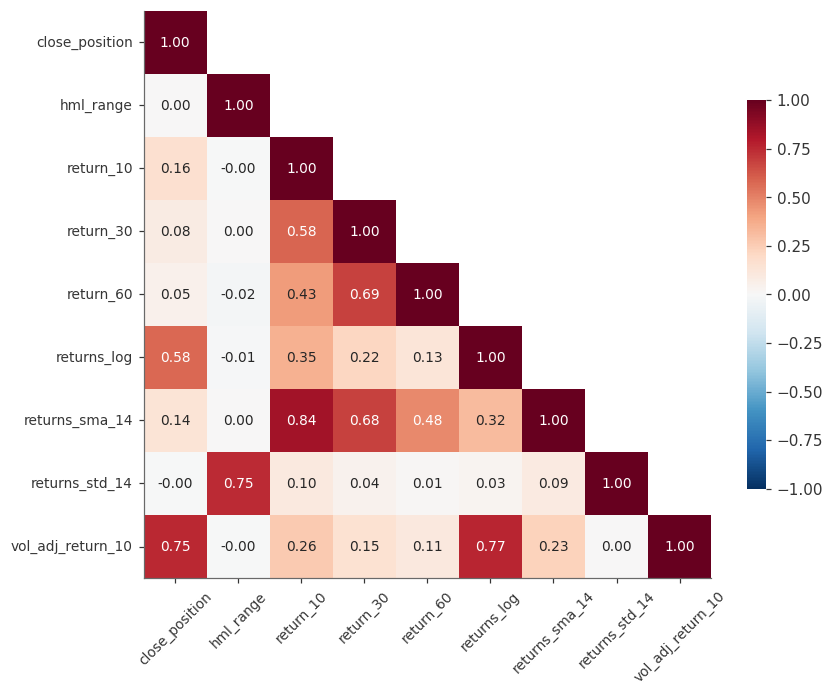




### feat_hml_range


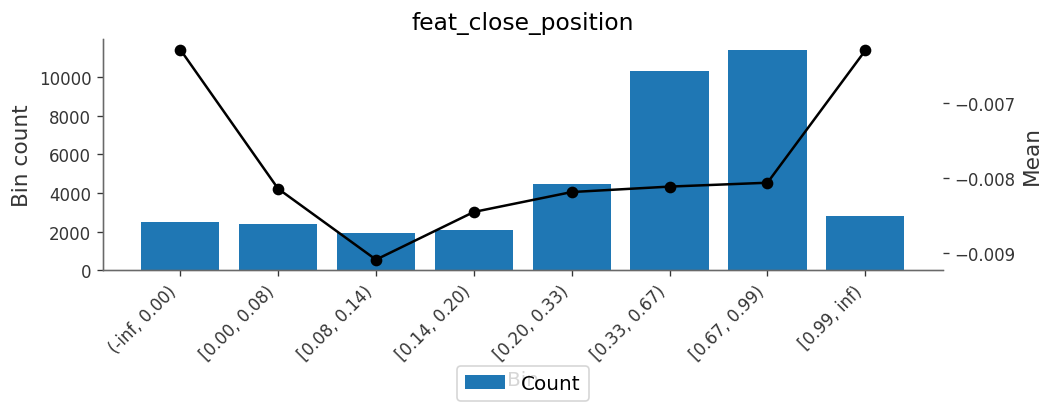




### feat_return_10


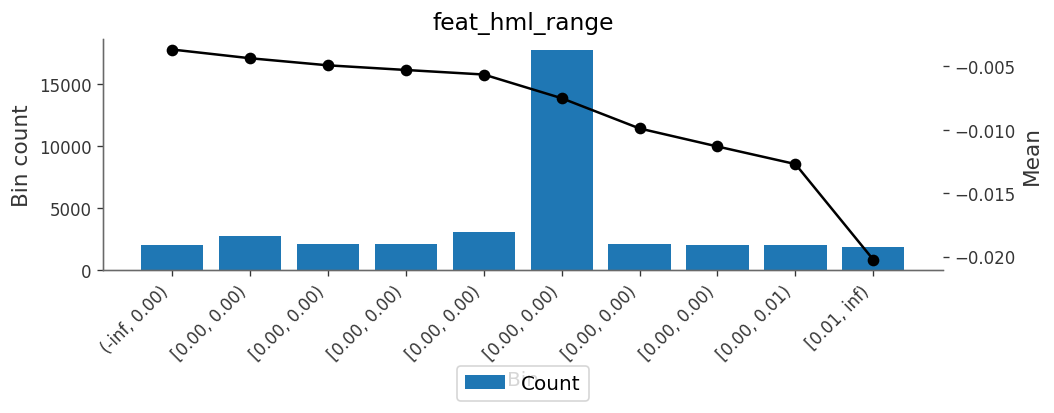




### feat_return_30


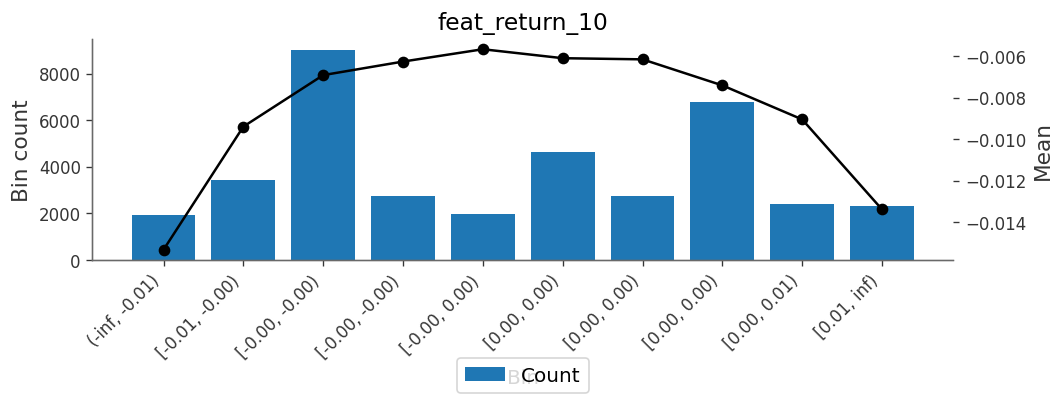




### feat_return_60


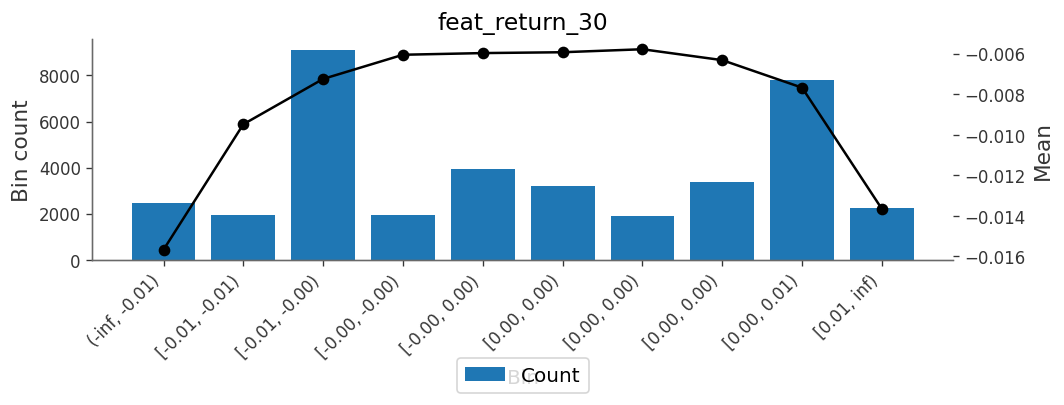




### feat_returns_log


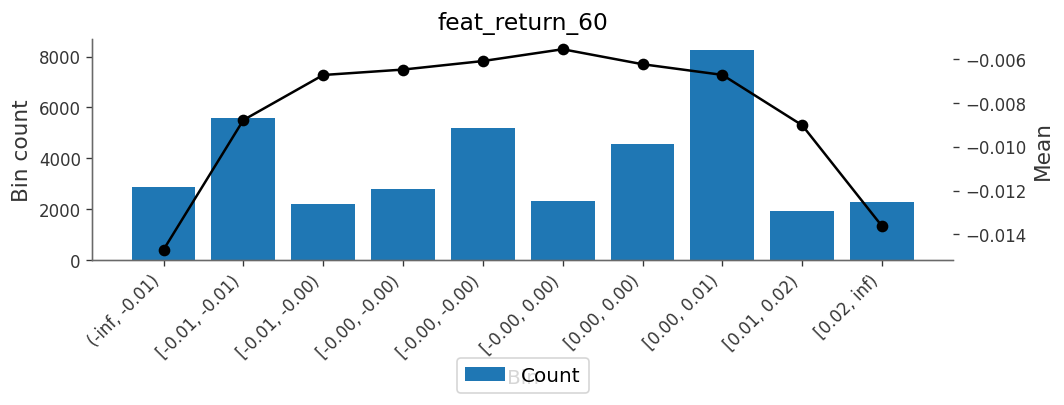




### feat_returns_sma_14


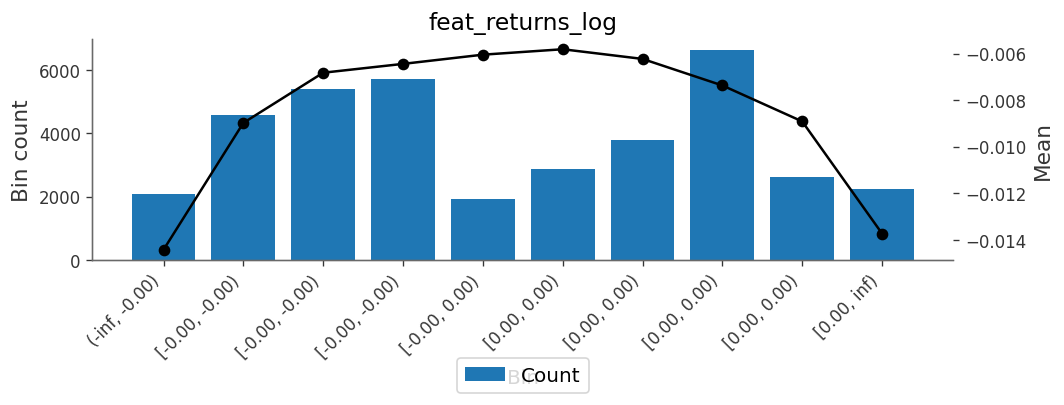




### feat_returns_std_14


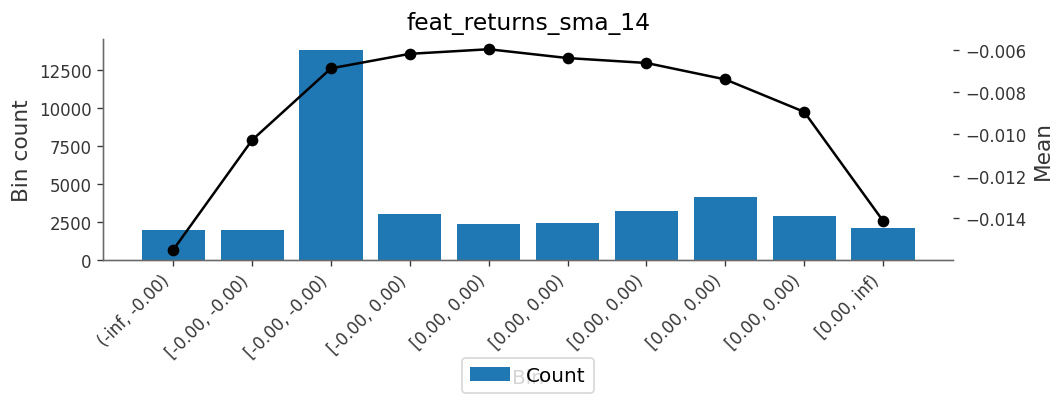




### feat_vol_adj_return_10



:::


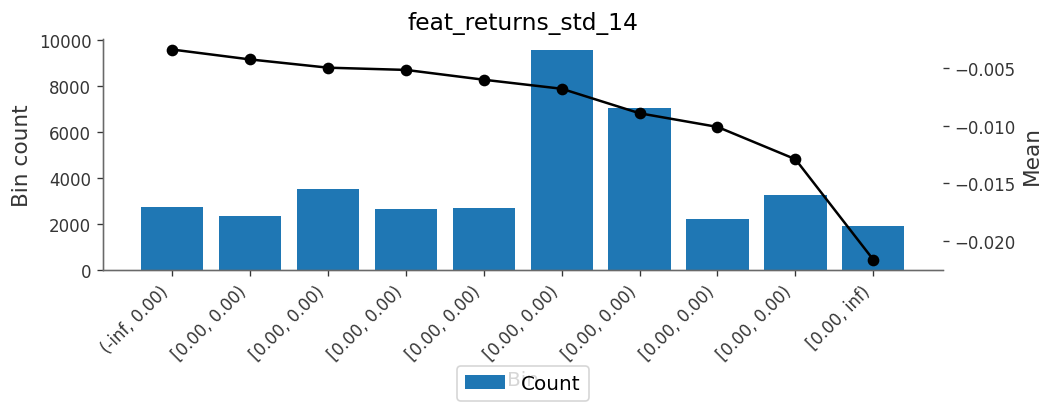
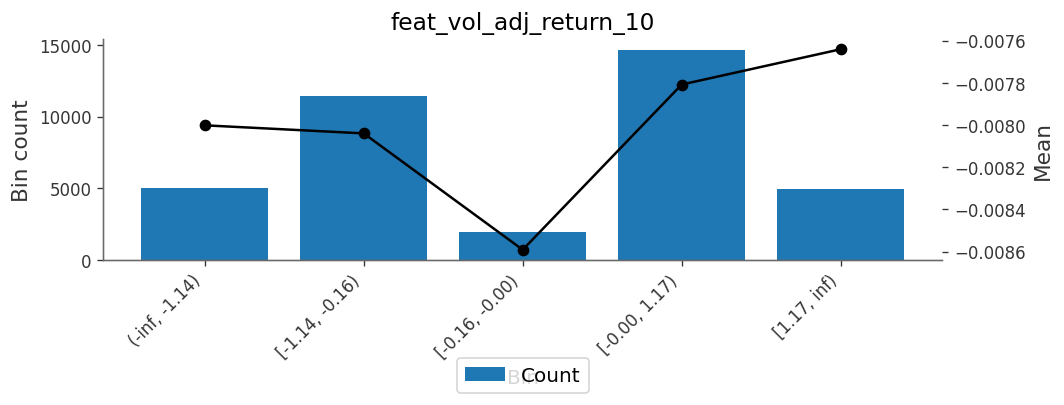


## Volatility

**Volatilitás jellemzők** — az ármozgás szórás- és range-alapú mérői.

- **Bollinger-sávok**: bb_width = (upper - lower) / close, bb_position = (close - lower) / (upper - lower)

- **ATR/NATR**: Wilder-EWM alapú True Range átlag; NATR = ATR / close (normalizált)

- **Hist-vol**: log-return gördülő szórása W bárra (ddof=1)

- **Parkinson-vol**: sqrt(mean((ln(H/L))^2 / (4*ln2))) — csak H/L-t használ, pontosabb, mint a close-alapú vol

- **Garman-Klass-vol**: sqrt(mean(0.5*(ln(H/L))^2 - (2*ln2-1)*(ln(C/O))^2)) — OHLC-alapú, még pontosabb

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `atr_14` | ATR-14: Wilder EWM alapu True Range atlag — TR=max(H-L, |H-C[-1]|, |L-C[-1]|) |
| `bb_position_14` | (close - BB_lower_14) / (BB_upper_14 - BB_lower_14) — pozicio a savon belul (0=alap, 1=teteje) |
| `bb_position_140` | (close - BB_lower_140) / (BB_upper_140 - BB_lower_140) — pozicio a savon belul (0=alap, 1=teteje) |
| `bb_width_14` | (BB_upper - BB_lower) / close —



::: {.panel-tabset}


### feat_atr_14


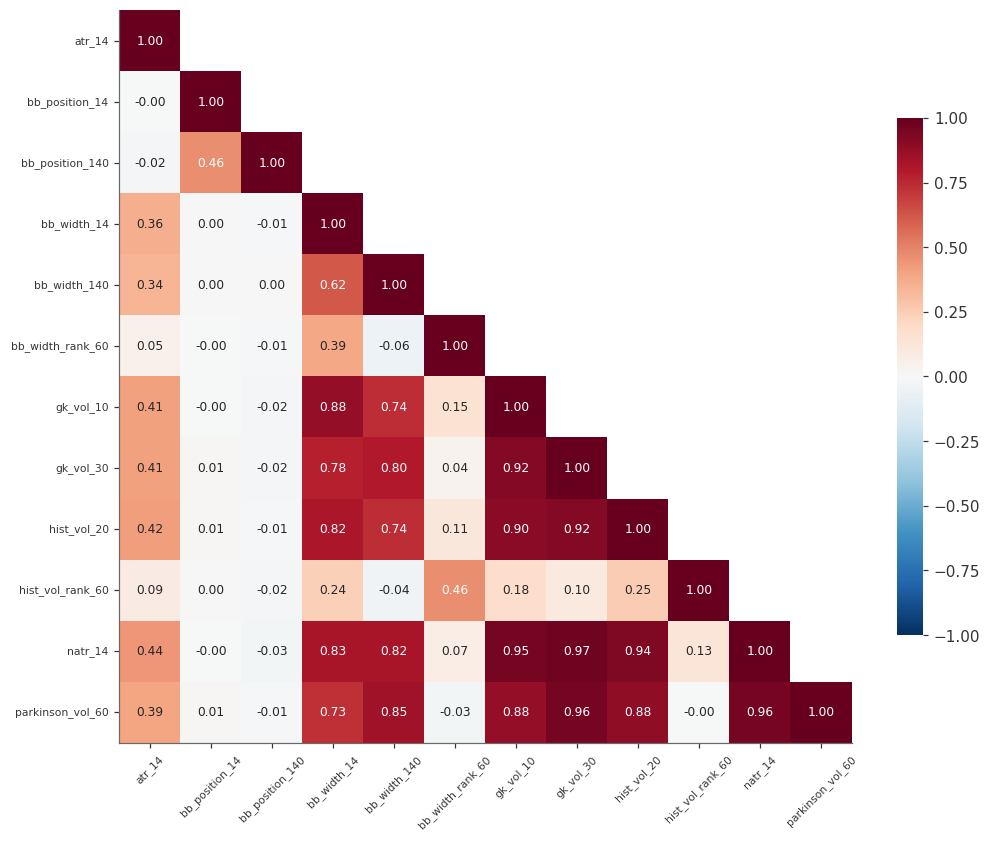




### feat_bb_position_14


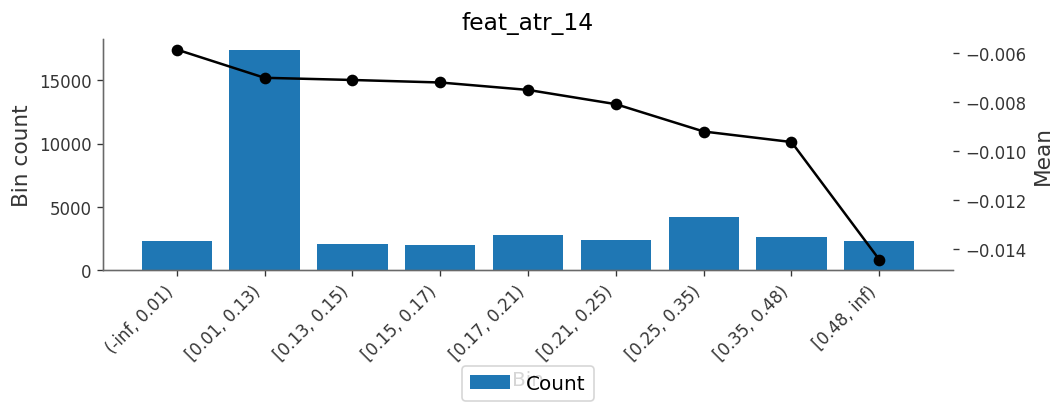




### feat_bb_position_140


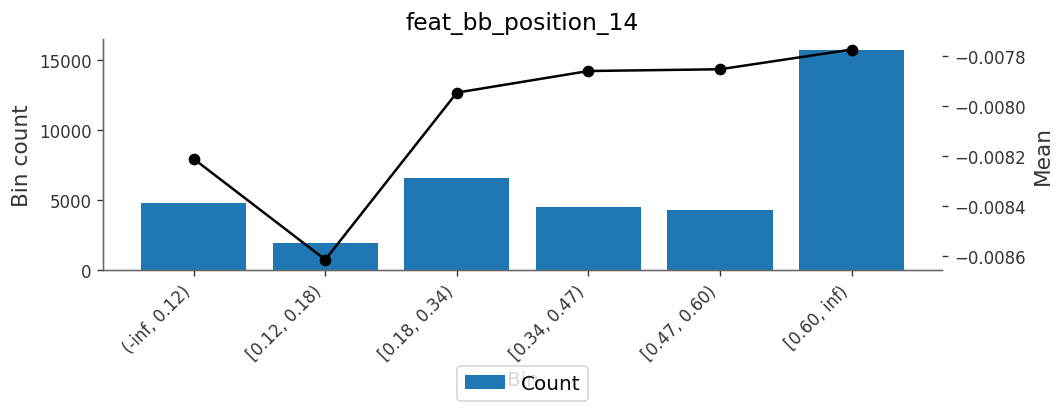




### feat_bb_width_14


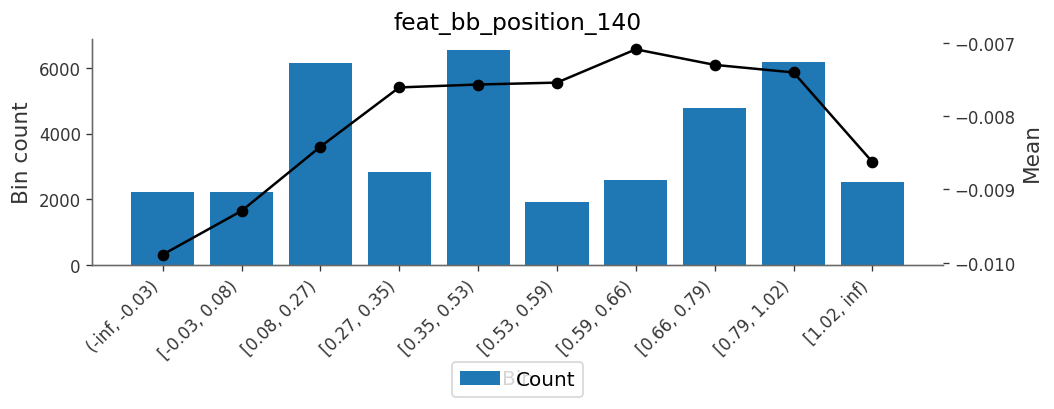




### feat_bb_width_140


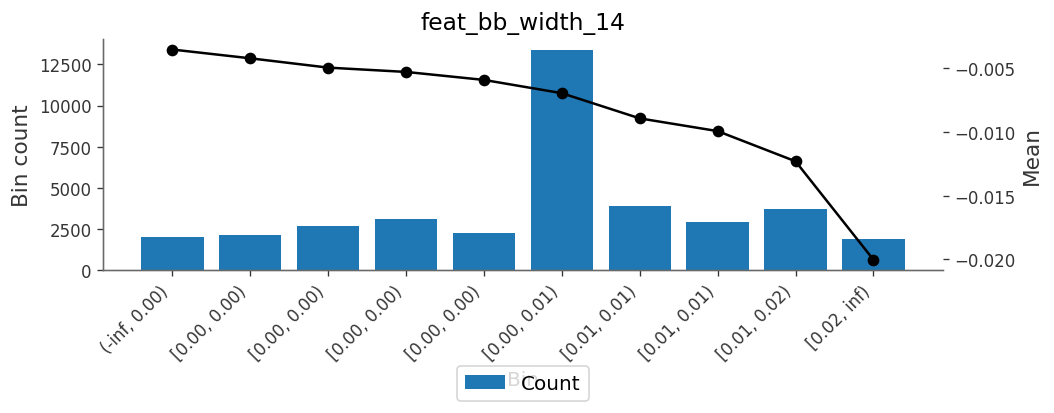




### feat_bb_width_rank_60


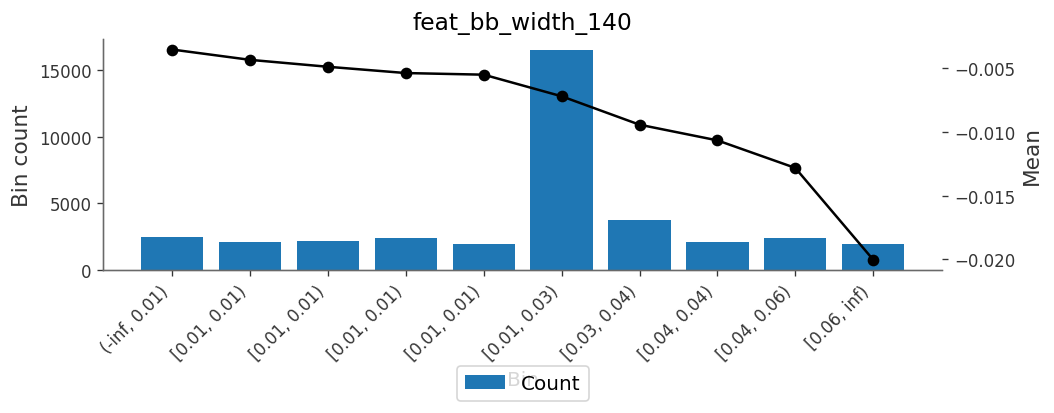




### feat_gk_vol_10




### feat_gk_vol_30


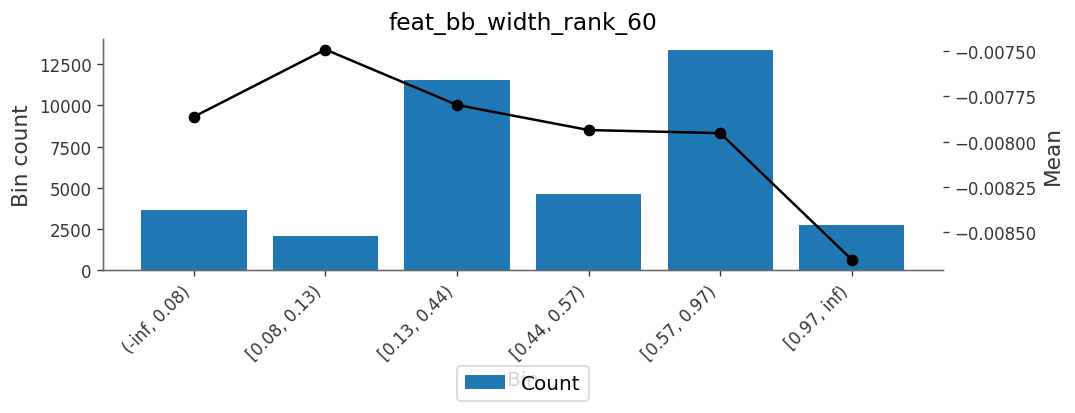
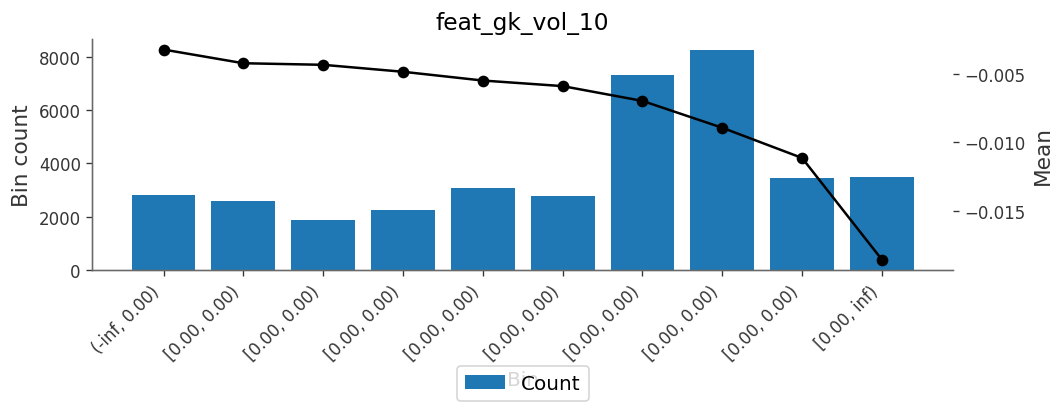




### feat_hist_vol_20


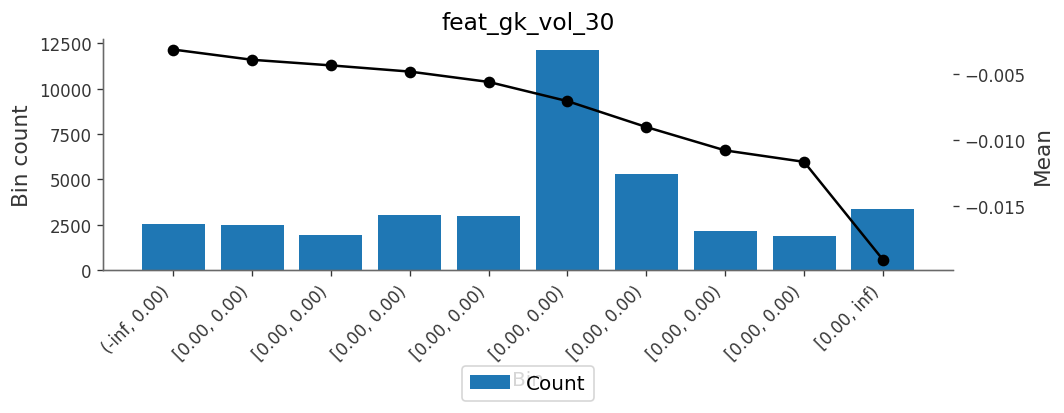




### feat_hist_vol_rank_60


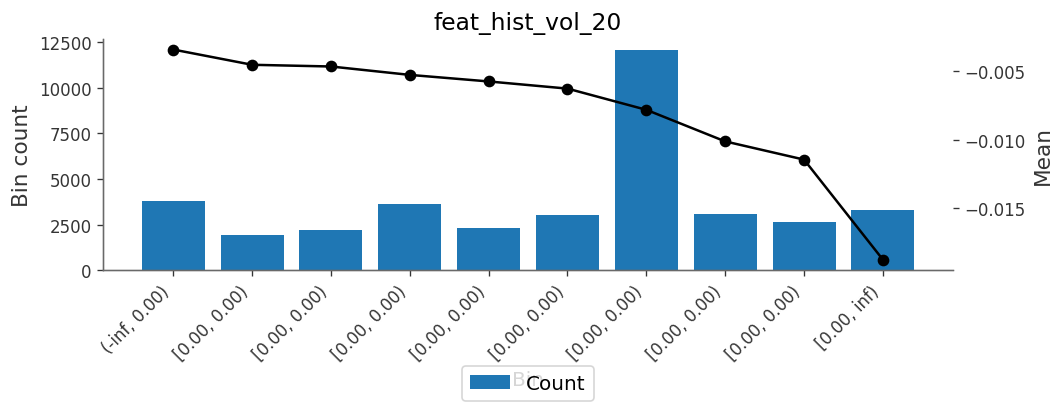




### feat_natr_14


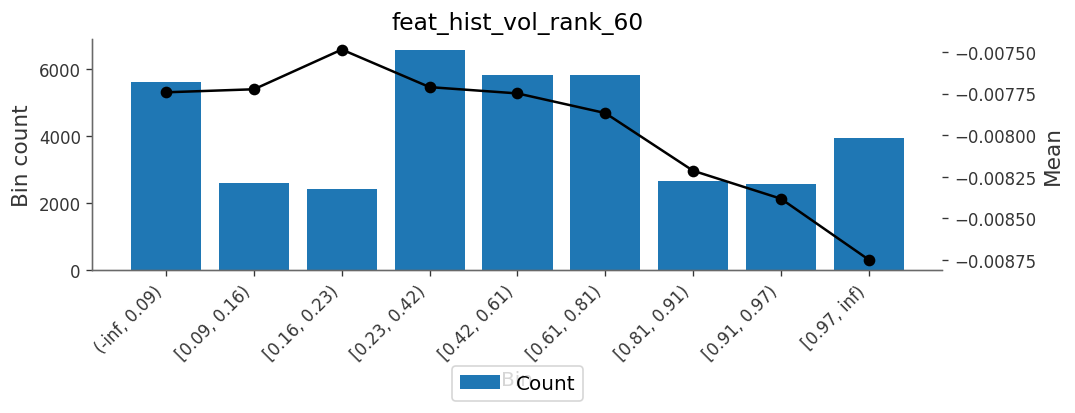




### feat_parkinson_vol_60


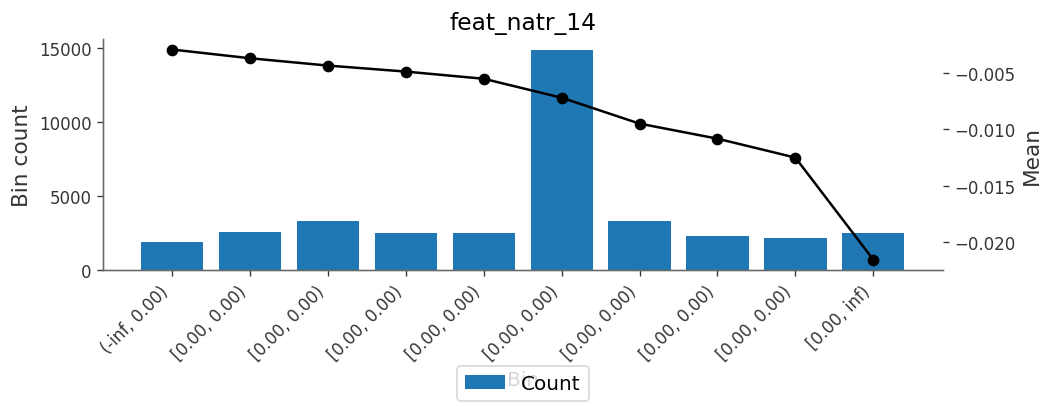



:::


## Volume

**Volume jellemzők** — a kereskedési volumen szintje, trendje és flow-összetétele.

- **volume_ratio**: aktuális volume / W-bári SMA — normalizált aktivitás szint

- **OBV**: On-Balance Volume = sum(sign(delta_close) * volume) — kumulált irányjelzett forgalom

- **MFI**: Money Flow Index — 100 - 100/(1 + pos_MF/neg_MF), ahol MF = TP * volume

- **A/D Line**: sum(CLV * volume), ahol CLV = ((C-L)-(H-C))/(H-L) — felhalmozás/elosztás

- **CMF**: Chaikin Money Flow = sum(MFV, W) / sum(V, W) — rövid távú flow (-1..+1)

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `ad_line` | sum(CLV*V) — A/D Line — felhalmozas/elosztás, CLV=((C-L)-(H-C))/(H-L) |
| `cmf_20` | sum(CLV*V,20) / sum(V,20) — Chaikin Money Flow (-1..+1) |
| `mfi_14` | MFI-14: 100-100/(1+pos_MF/neg_MF) — TP*V alapu RSI-analog (0-100) |
| `obv` | sum(sign(delta_close) * volume) — On-Balance Volume: kumulalt iranyjelzett forgalom |
| `obv_roc_14` | OBV.pct_change(14) — OBV 14-bari Rate of Change |
|
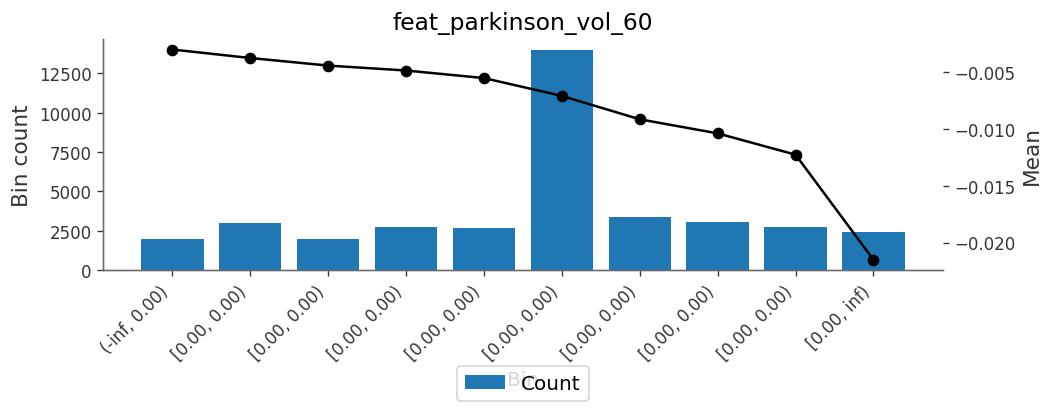



::: {.panel-tabset}


### feat_ad_line




### feat_cmf_20


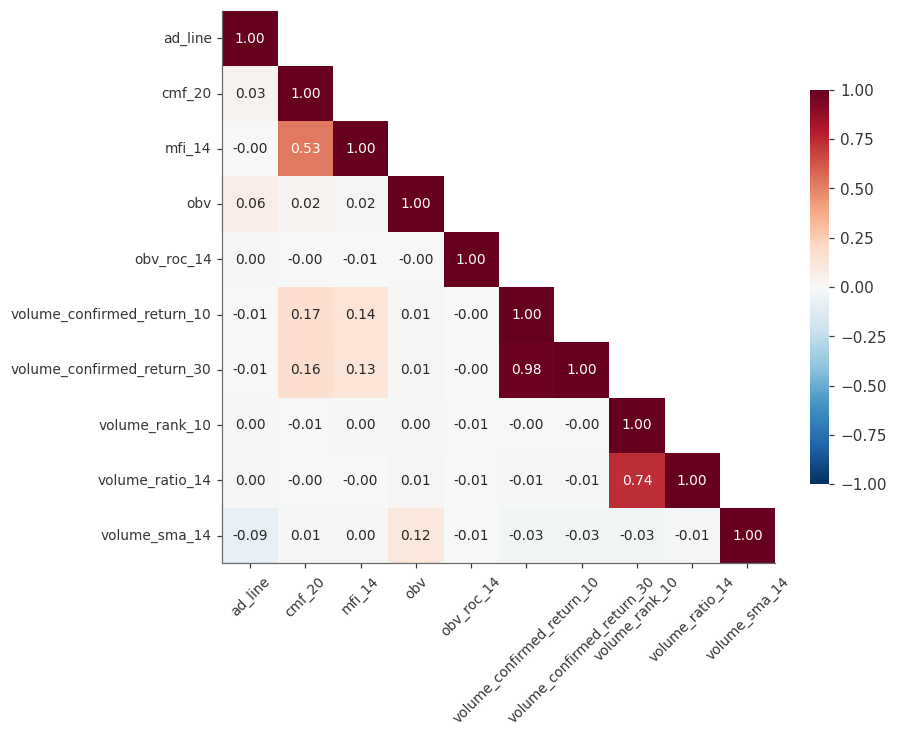
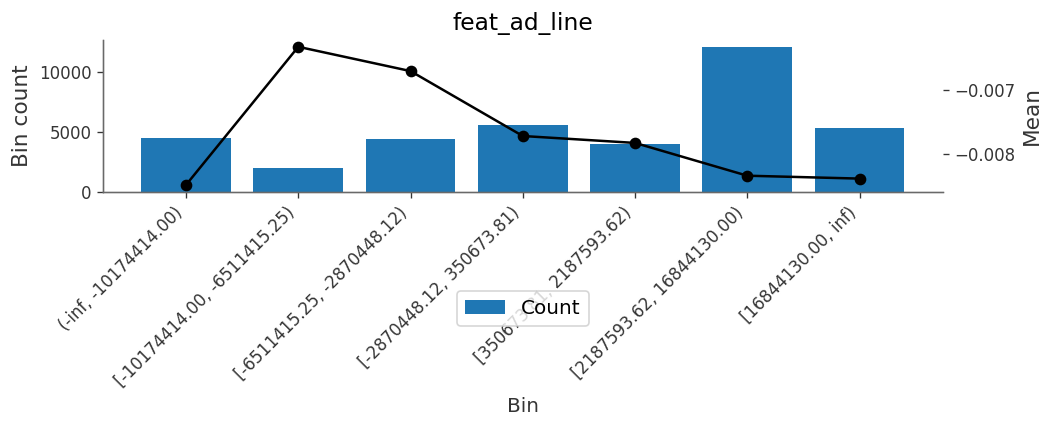




### feat_mfi_14


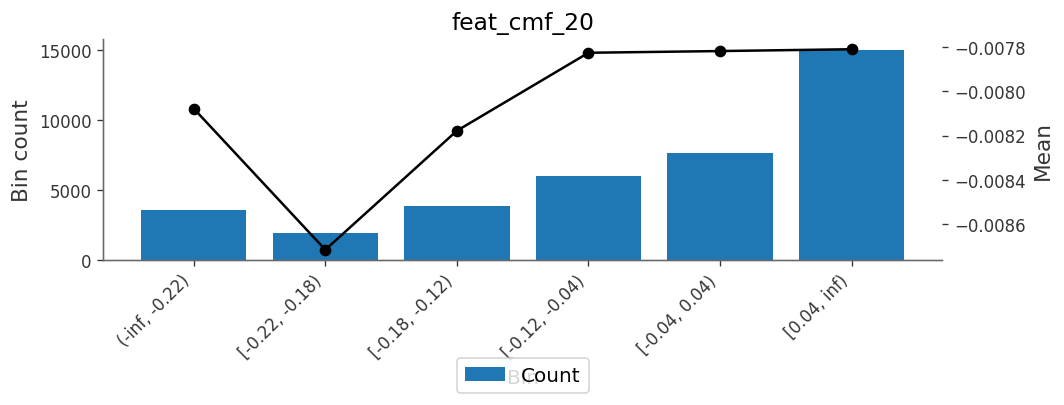




### feat_obv


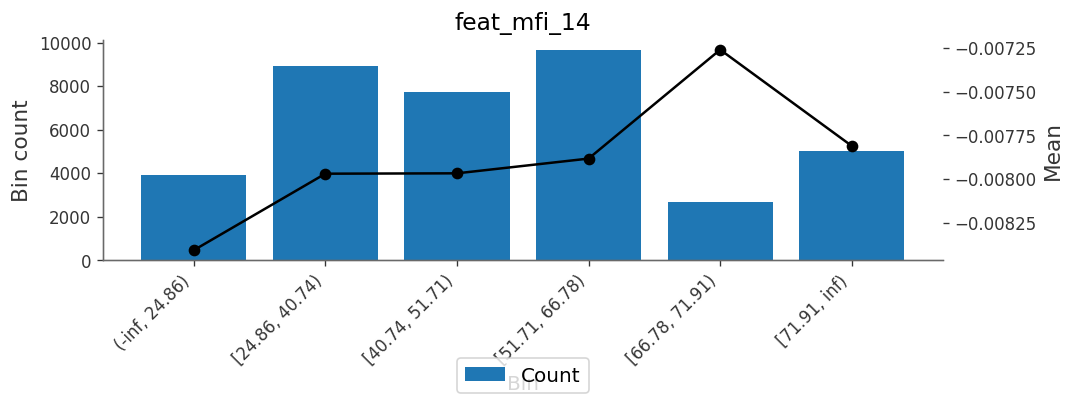




### feat_obv_roc_14


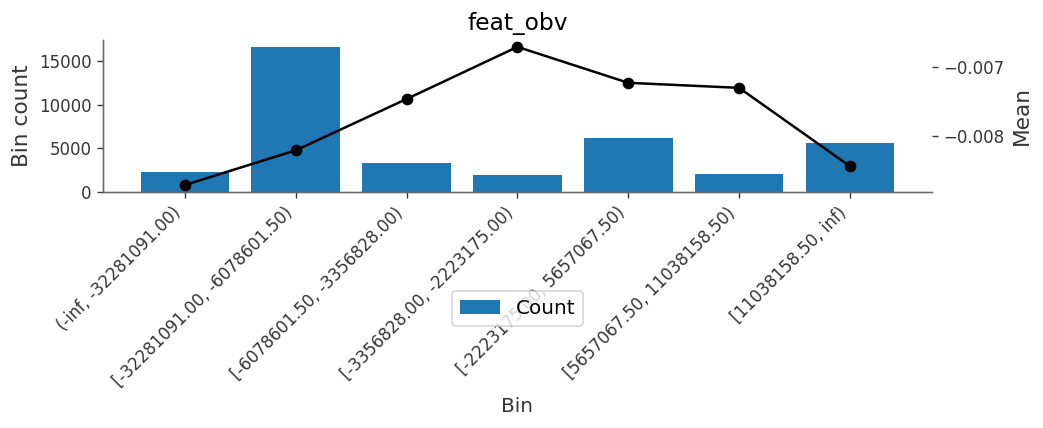




### feat_volume_confirmed_return_10


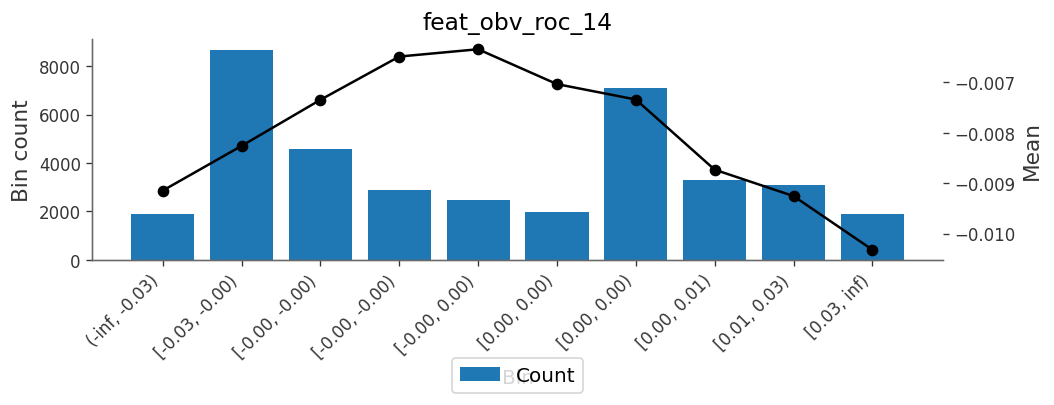




### feat_volume_confirmed_return_30


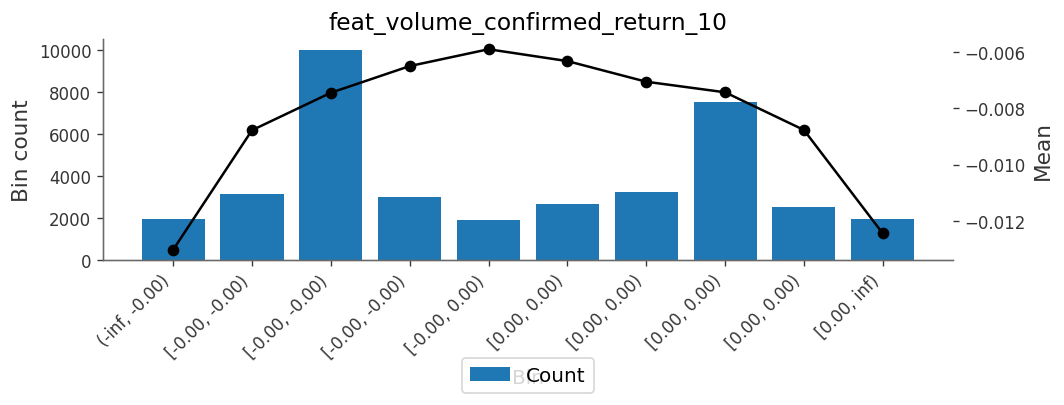




### feat_volume_rank_10




### feat_volume_ratio_14


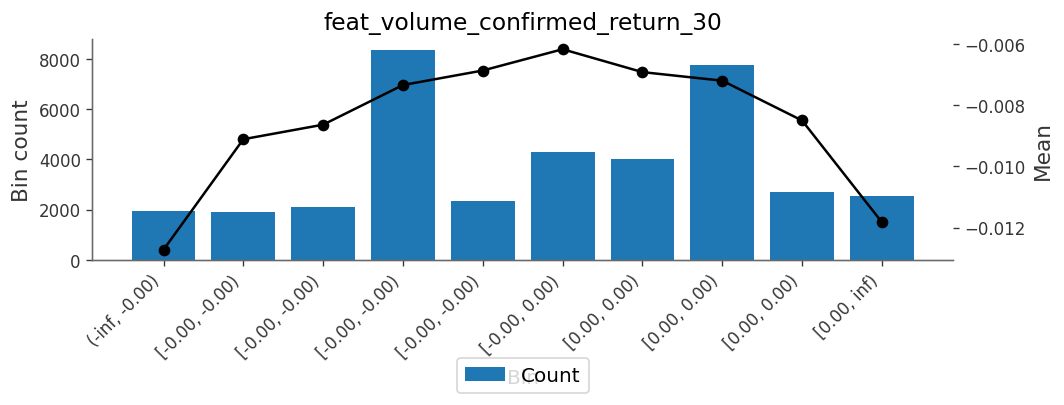
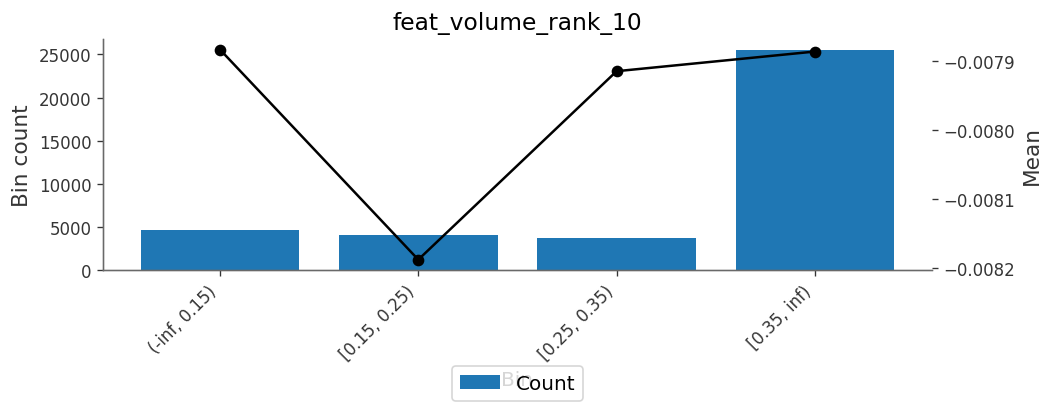




### feat_volume_sma_14


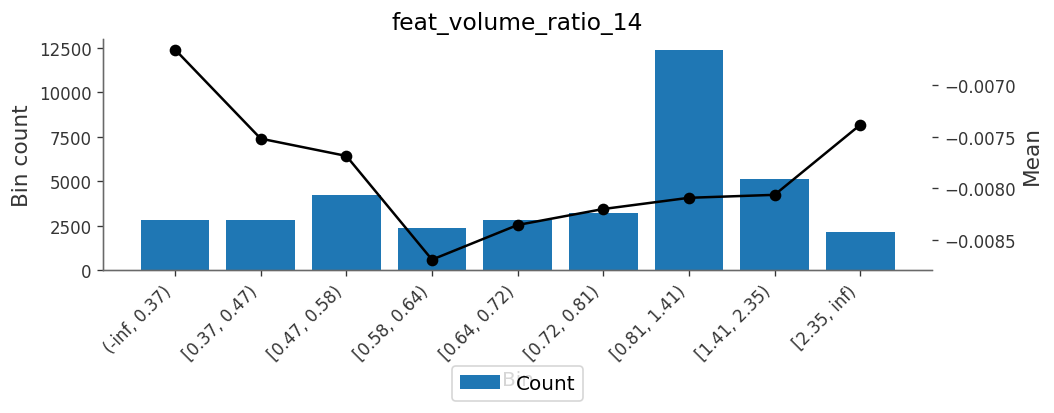



:::


## Gap

**Gap jellemzők** — a nyitóár és az előző zárár közötti ugrás (rés) mértéke.
Kripto-piacokon a gap kisebb, de hír-eseményeknél és likvidáció-kaszkádoknál szignifikáns lehet.
A gap_open_abs_sma a gap abszolút értékének gördülő átlaga, ezzel gap-volatilitás proxy-ként használható.
Ablakméret: 10 és 30 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `gap_open` | (open - prev_close) / prev_close — nyitogap merteke (relativ) |
| `gap_open_abs_sma_10` | |gap_open| 10-bari gordulo atlaga — gap-volatilitas proxy |
| `gap_open_abs_sma_30` | |gap_open| 30-bari gordulo atlaga — gap-volatilitas proxy |

<style type="text/css">
#T_54778  {
  border-collapse: collapse;
  border: 1px solid black;
}
#T_54778 th {
  border: 1px solid black;
  padding: 4px 8px;
  text-align: center;
}
#T_54778 td {
  border: 1px solid black;
  padding: 4px 8px;
}
#T_54778 thead th {
  border-bottom: 2px solid black;
}
#T_54778_row0_col0, #T_54778_row0_col4, #T_54778_row1_col0, #T_5477
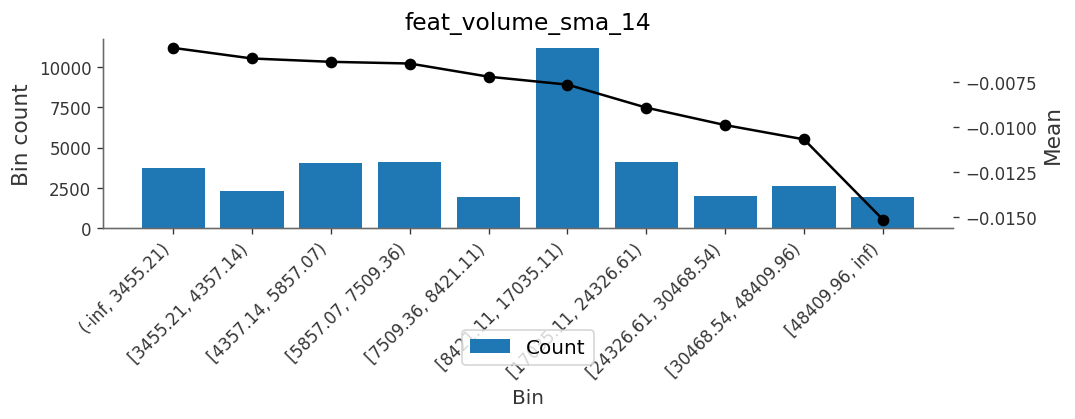



:::


## Candle Pattern

**Gyertyamintázat (Candle Pattern)** — az OHLC adatokból számolt gyertyaalak-jellemzők.
Az egyes gyertyák test/kanóc arányait, irányát és ismert technikai mintázatokat (doji, hammer, engulfing) kódolják.
A gördülő átlag változatok (SMA) a mintázat hosszabb távú fennállását mutatják.
Alap képletek: range = high - low, body = |close - open|,
upper_wick = high - max(open, close), lower_wick = min(open, close) - low.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `body_ratio` | |close - open| / (high - low) — test/tartomany arany (0-1) |
| `body_ratio_sma_10` | |body|/range 10-bari gordulo atlaga |
| `body_ratio_sma_30` | |body|/range 30-bari gordulo atlaga |
| `bull_bars_ratio_10` | (close > open) barainak aranya az utolso 10 barban (0-1) |
| `bull_bars_ratio_30` | (close > open) barainak aranya az utolso 30 barban (0-1) |
| `bull_bars_ratio_60` | (close > open) barainak aranya az utolso 60 barban (0-1) |
| `doji` | |body|/range < 0.1 => doji gye
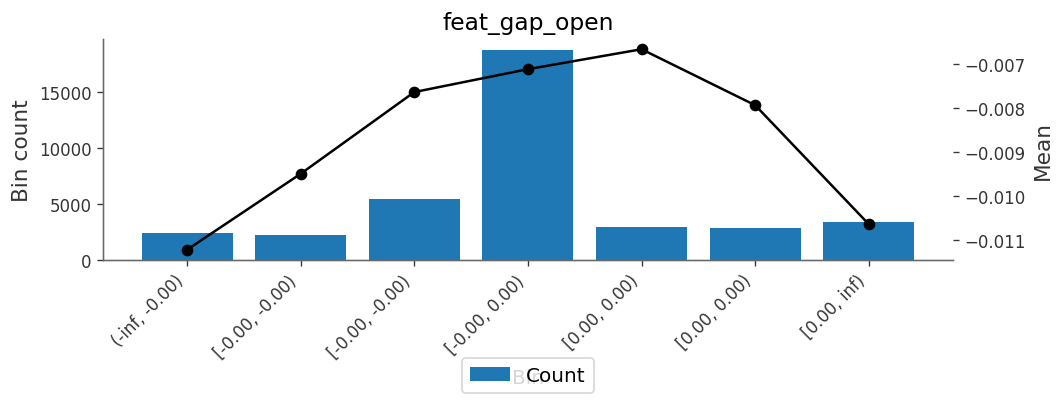



::: {.panel-tabset}


### feat_body_ratio


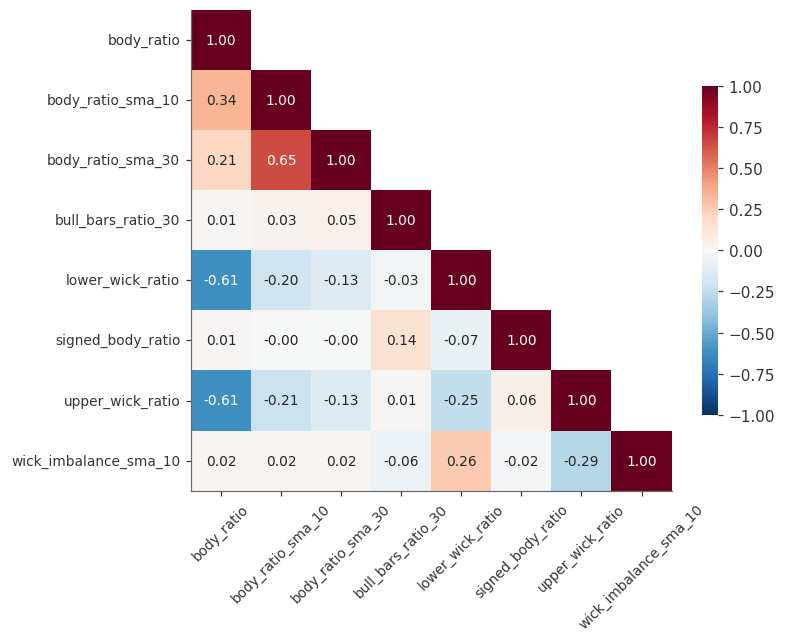




### feat_body_ratio_sma_10


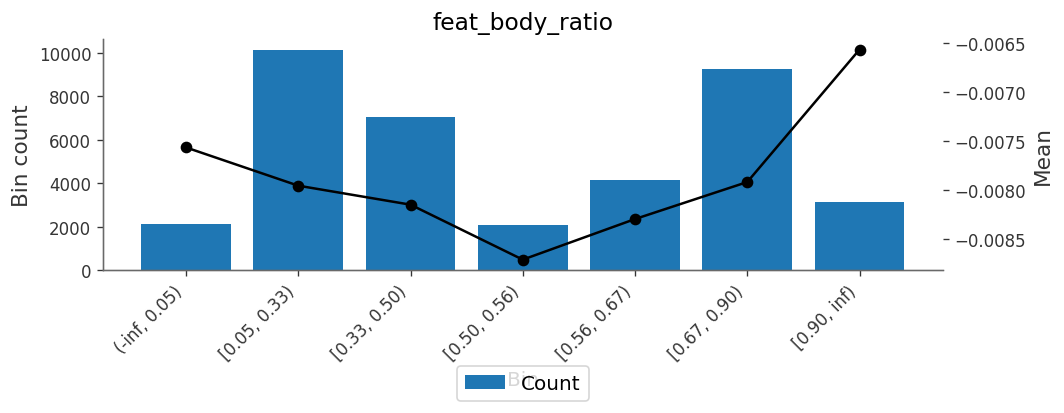




### feat_body_ratio_sma_30


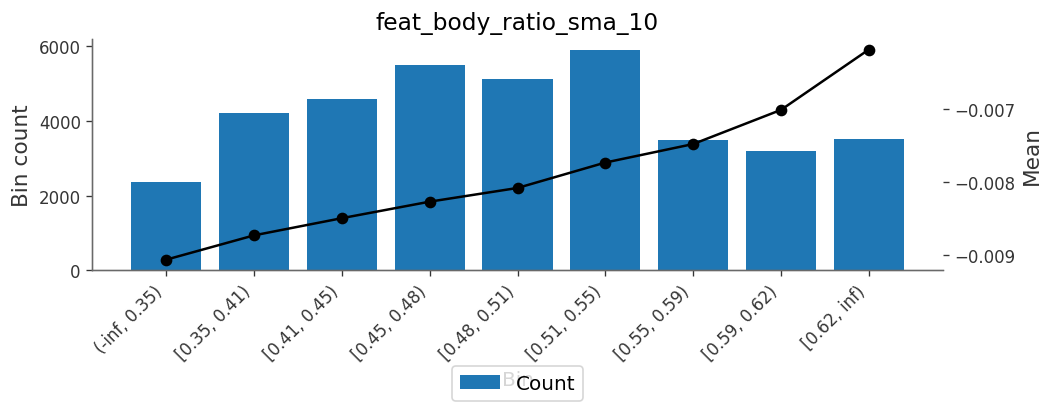




### feat_bull_bars_ratio_30


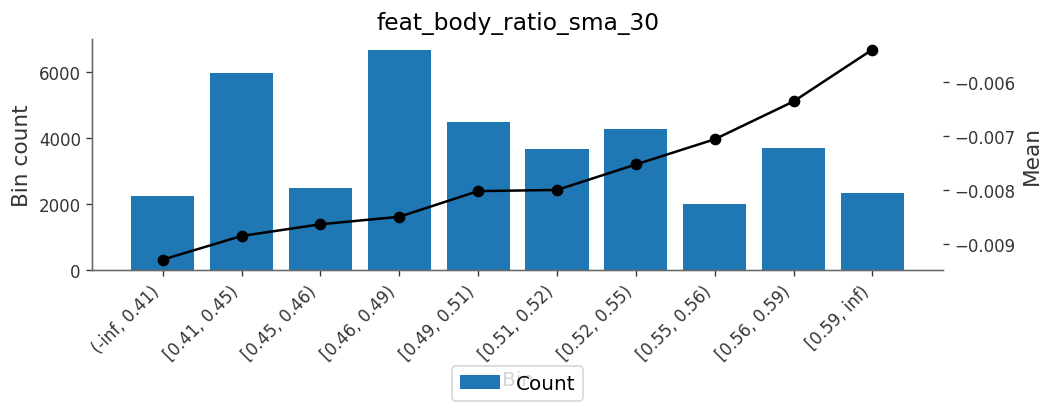




### feat_lower_wick_ratio


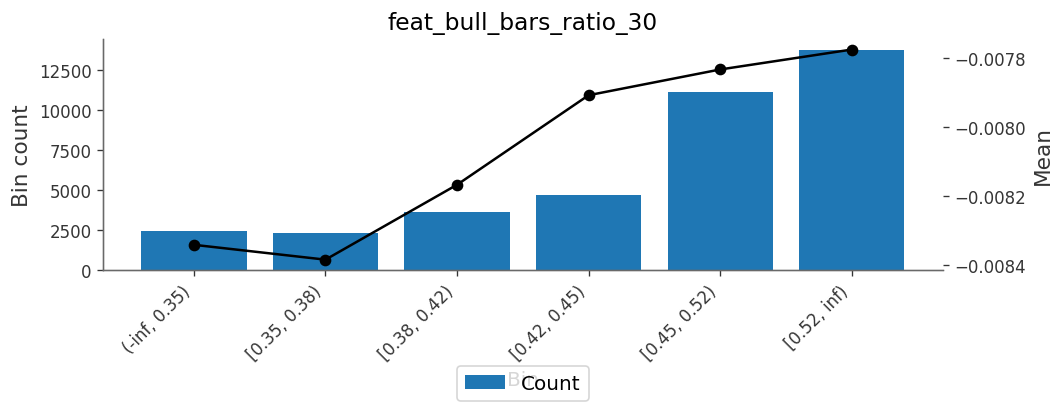




### feat_signed_body_ratio


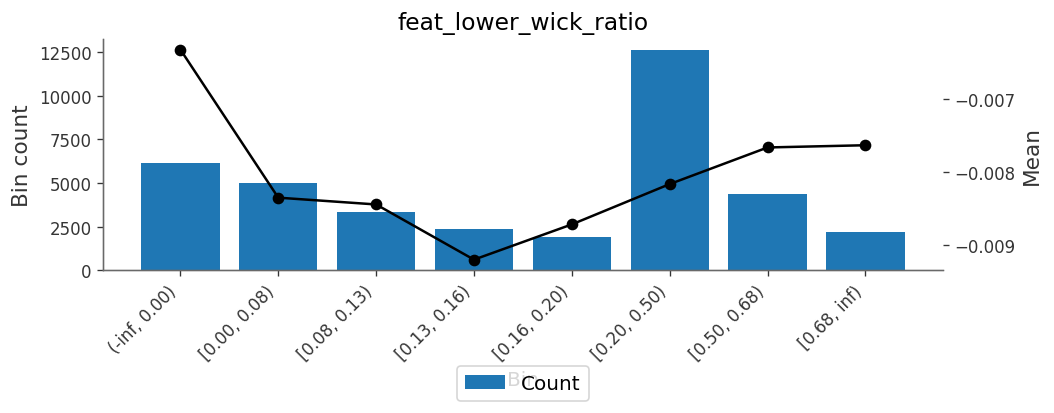




### feat_upper_wick_ratio


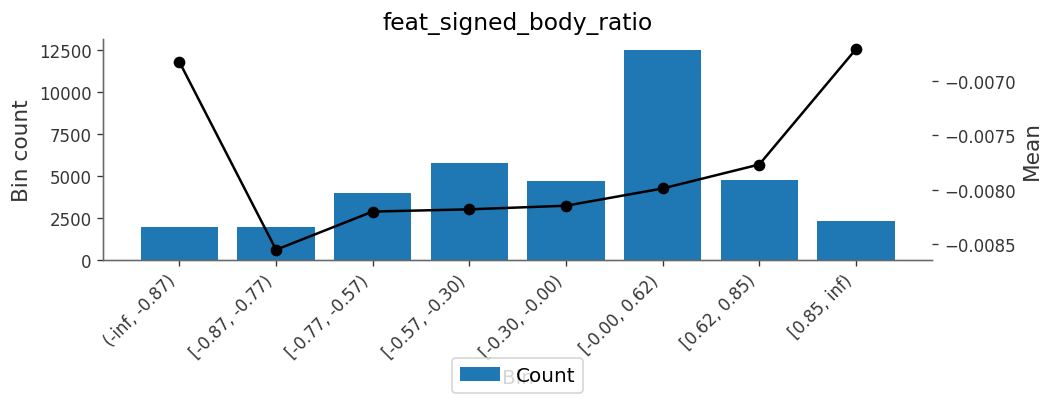




### feat_wick_imbalance_sma_10


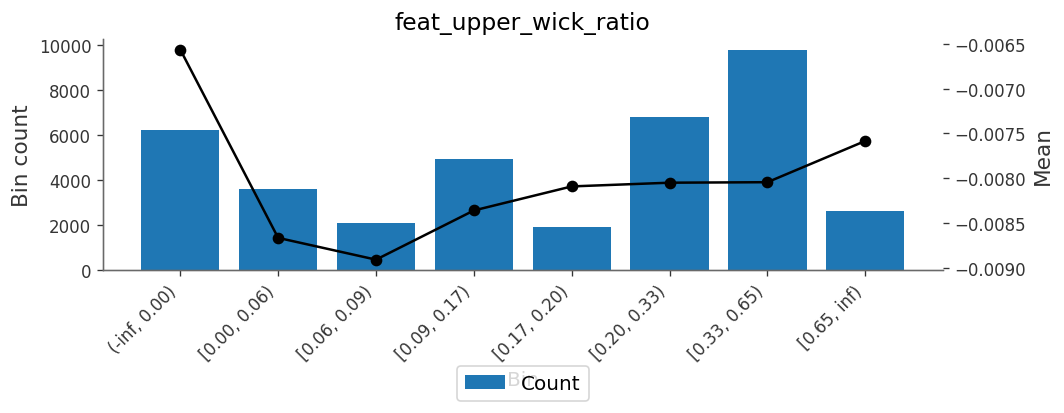



:::


## Time/Session

**Idő és session jellemzők** — determinisztikus időstruktúra-kódolás, session-relatív pozíciók.
A kör-kódolás (circular encoding) biztosítja, hogy az éjfél és hajnal közel essen egymáshoz
a feature-térben is. Session flag-ek UTC-időzóna alapján.
Ezek a feature-ök nem kapnak t-1 laget (P2 determinisztikus indexek — az időbélyeg alapján
pontosan kiszámíthatók, nem tartalmaznak jövőbeli infót).

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `bars_into_session_norm` | cumcount_within_day / 1440, klippelve 0-1 — a nap hanyadán vagyunk |
| `day_open_return` | (close - aznapi_elso_open) / aznapi_elso_open — return az aznapi nyitoartol |
| `day_range_position` | (close - exp_low) / (exp_high - exp_low) — ar helyzete a nap kumulalt csocs-melypont tartomanyan |
| `dayofweek_cos` | cos(2*pi * napszam / 7) — het napjanak kor-kodolasa (koszinusz) |
| `dayofweek_sin` | sin(2*pi * napszam / 7) — het napjanak kor-kodolasa (szinusz) |
| `hour_cos` | cos(2*pi * o
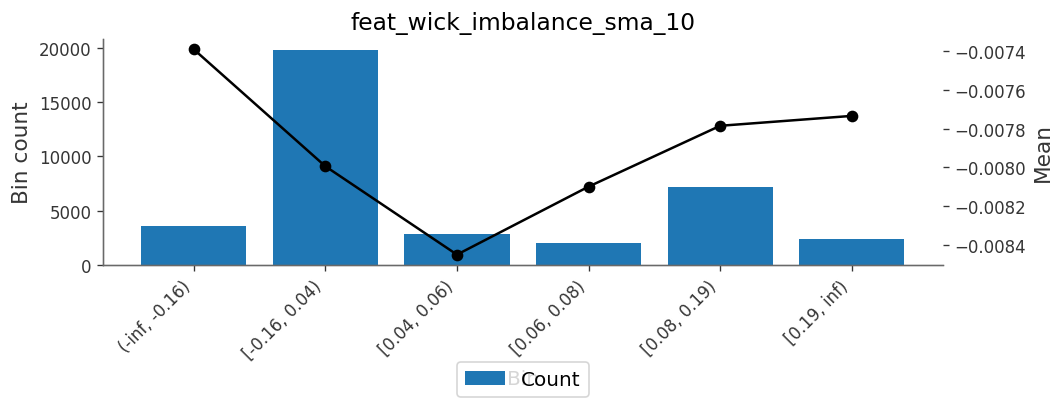



::: {.panel-tabset}


### feat_bars_into_session_norm


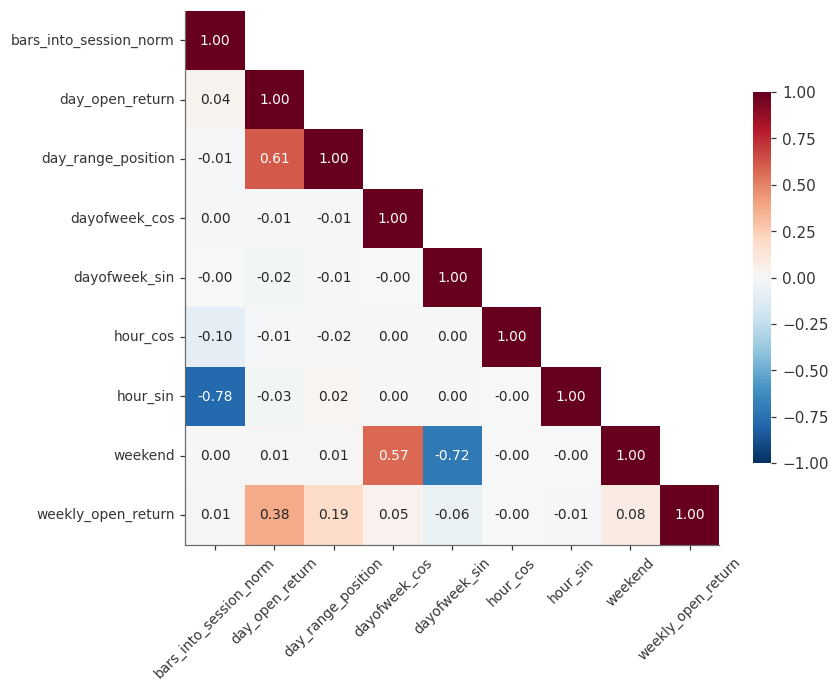




### feat_day_open_return


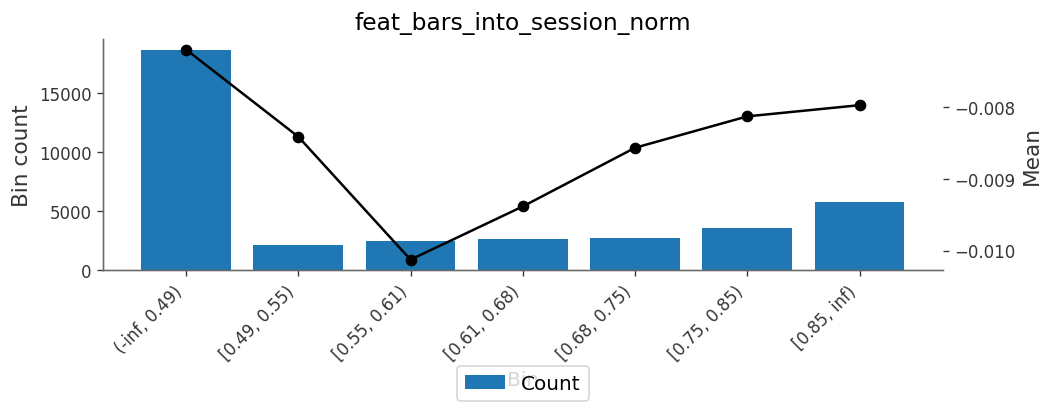




### feat_day_range_position


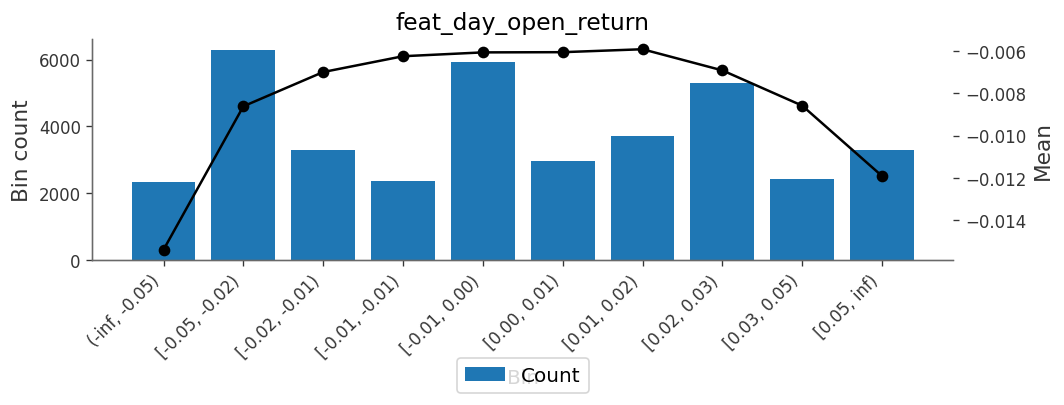




### feat_dayofweek_cos


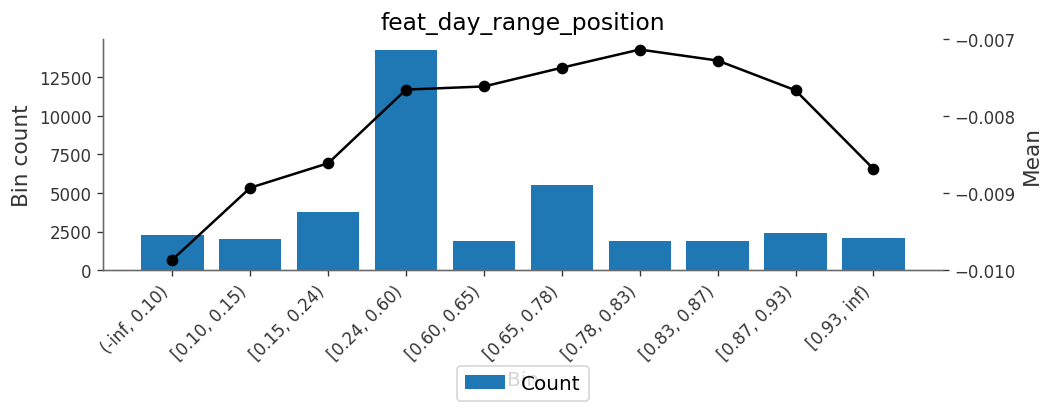




### feat_dayofweek_sin


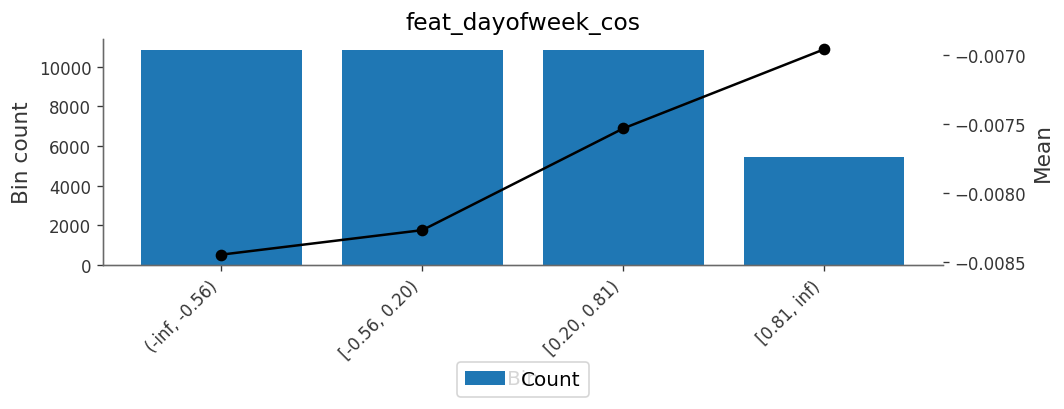




### feat_hour_cos


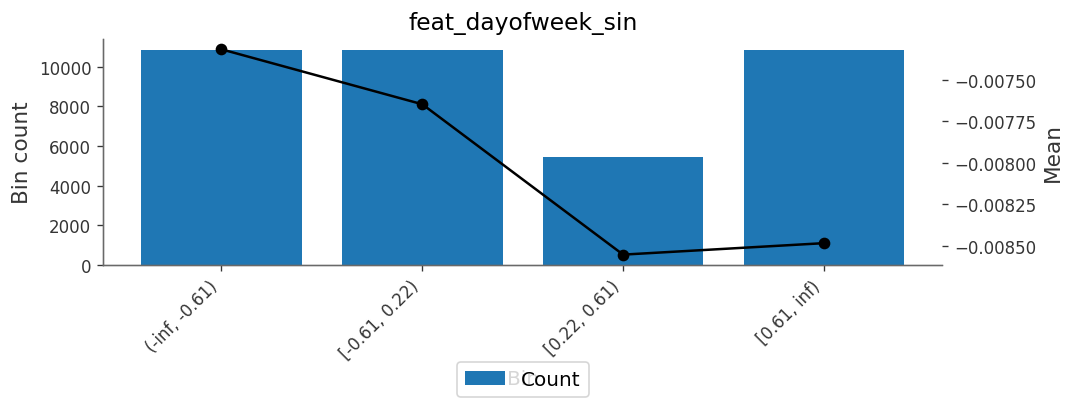




### feat_hour_sin


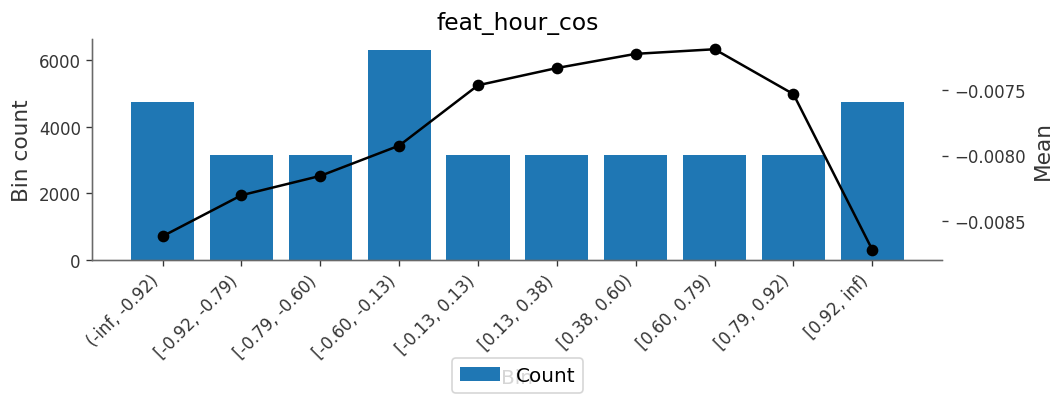




### feat_weekend




### feat_weekly_open_return


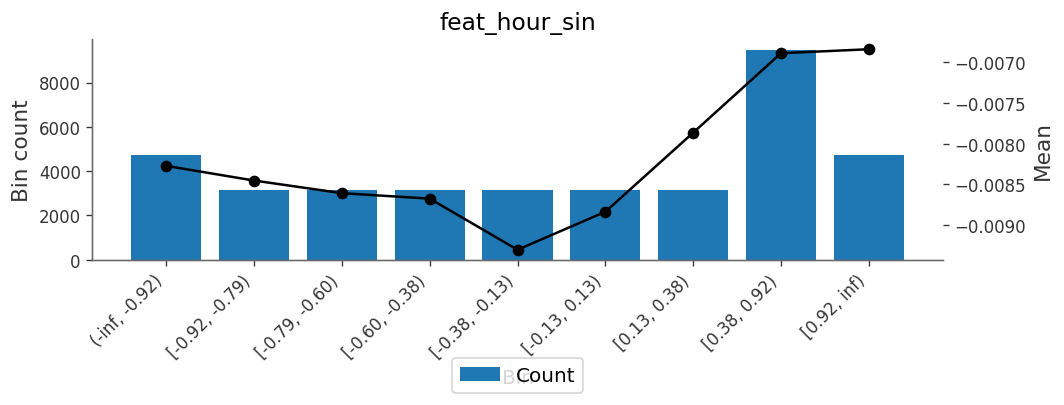
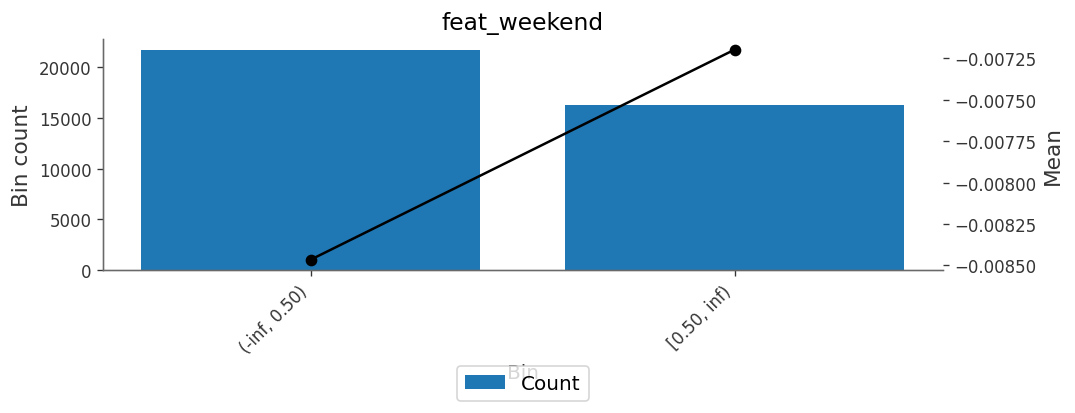



:::


## Taker Flow

**Taker flow és kereskedési aktivitás** — agresszív vevők/eladók jelenlétének mérése.
A Binance futures API-ból elérhető taker_buy_base, quote_volume és trades adatokból számolt arányok.
A taker flow azt méri, hogy a kötések mekkora hányada "taker" (piaci megbízás) és melyik irányba mutat.
Gördülő összegen számolva (rolling sum), ablakméret: 5, 10, 30, 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `avg_trade_quote_30` | sum(quote_volume,30) / sum(trades,30) — atlagos kotesmeret USD-ben (30 bar) |
| `quote_volume_ratio_10` | quote_volume / rolling_mean(quote_volume,10) — USD-forgalom / 10-bari SMA |
| `quote_volume_ratio_30` | quote_volume / rolling_mean(quote_volume,30) — USD-forgalom / 30-bari SMA |
| `quote_volume_ratio_60` | quote_volume / rolling_mean(quote_volume,60) — USD-forgalom / 60-bari SMA |
| `taker_buy_base_ratio_10` | sum(taker_buy_base,10) / sum(volume,10) — taker vasarlasok aranya (0-1) |
| `taker_buy_base_ratio_30` | sum(
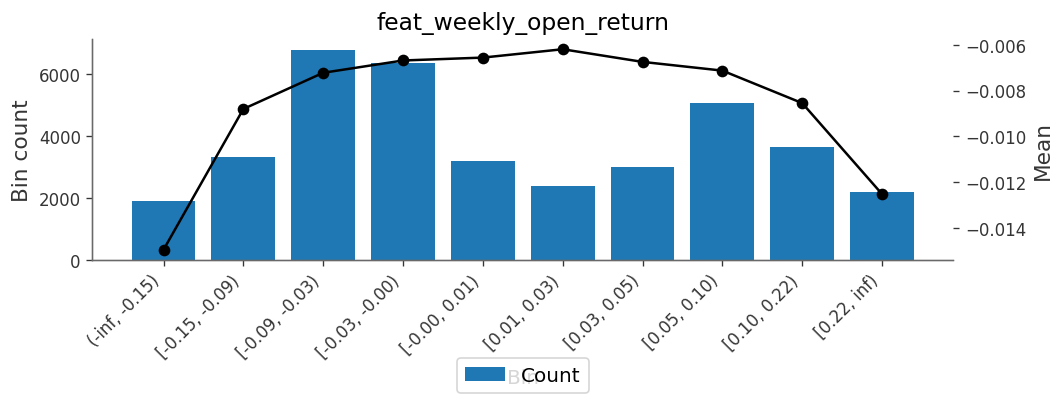



::: {.panel-tabset}


### feat_avg_trade_quote_30


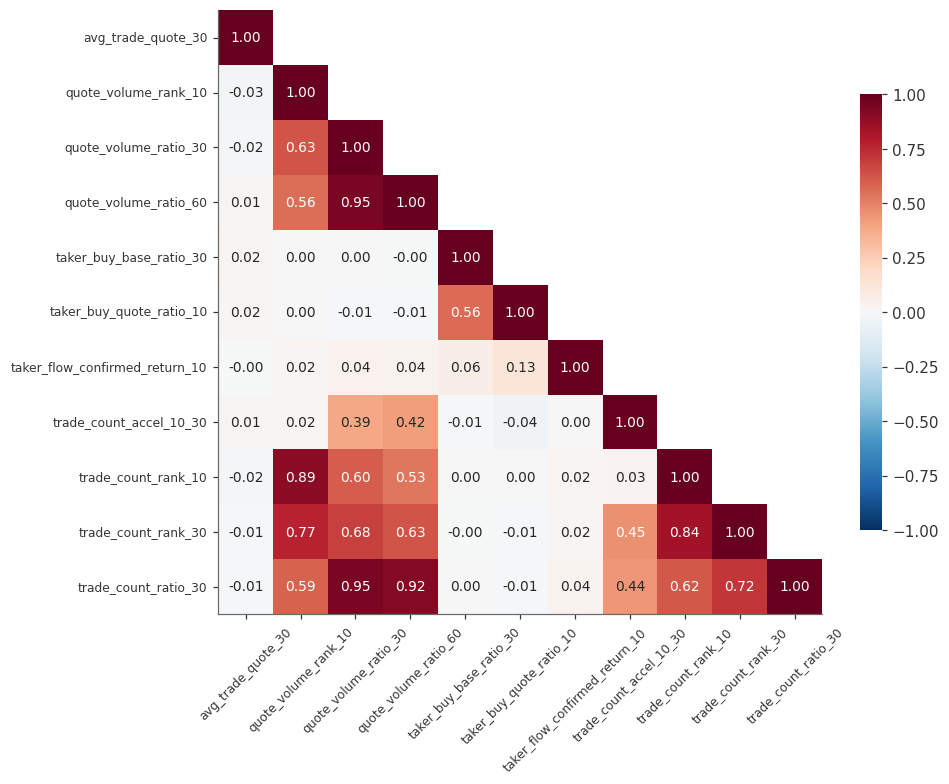




### feat_quote_volume_rank_10


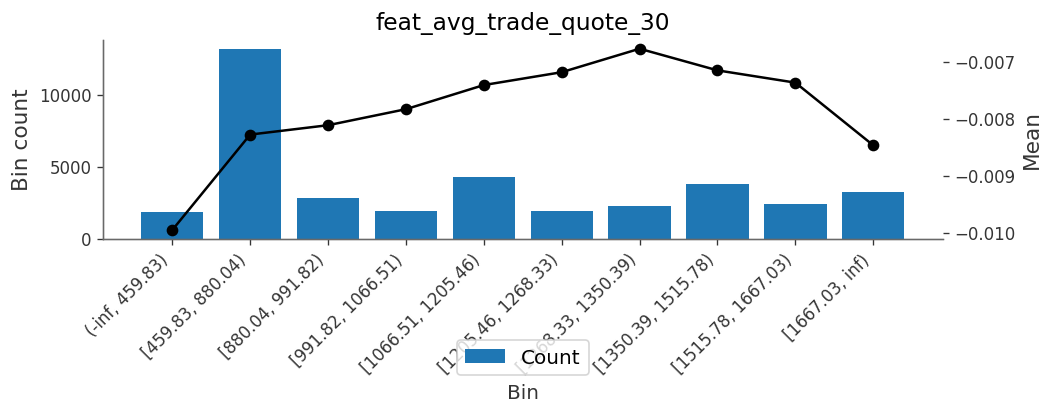




### feat_quote_volume_ratio_30


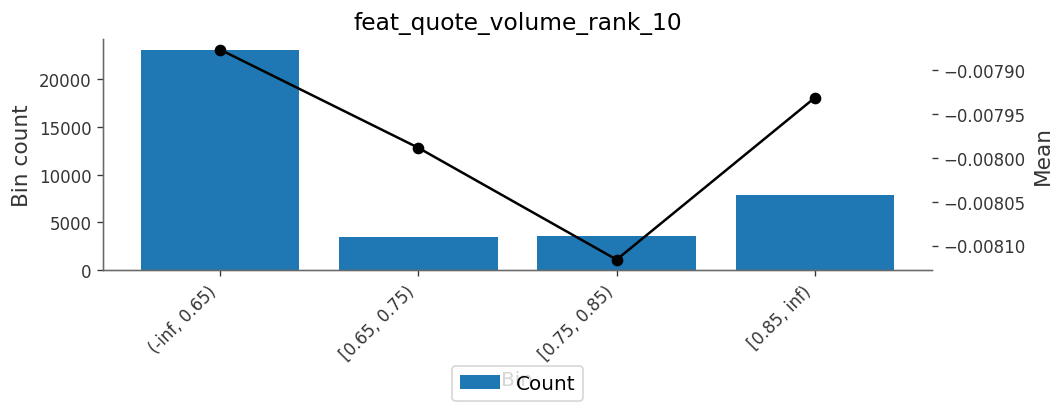




### feat_quote_volume_ratio_60




### feat_taker_buy_base_ratio_30


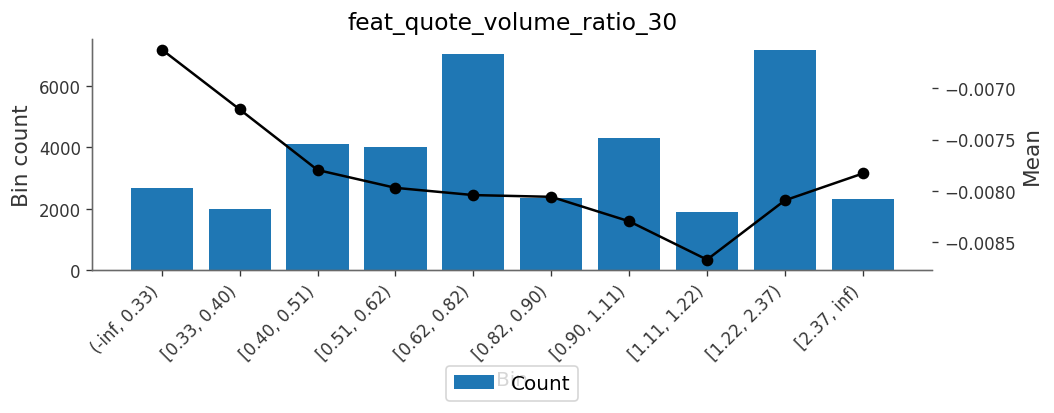
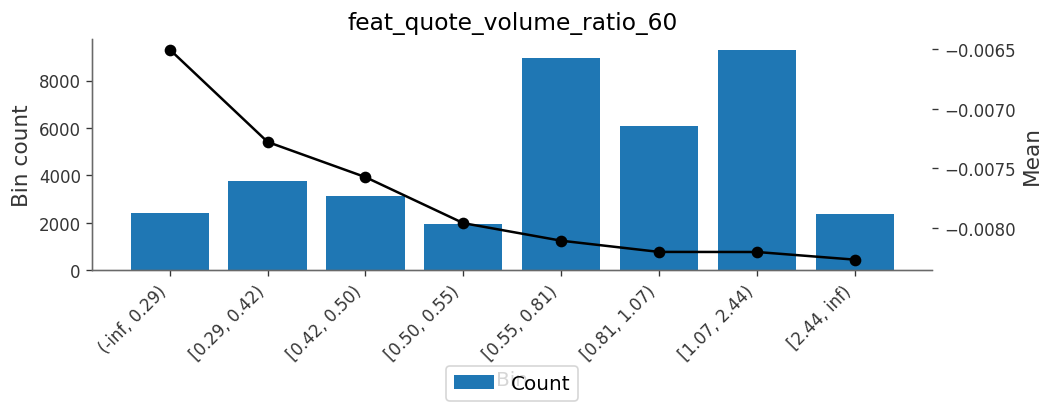




### feat_taker_buy_quote_ratio_10


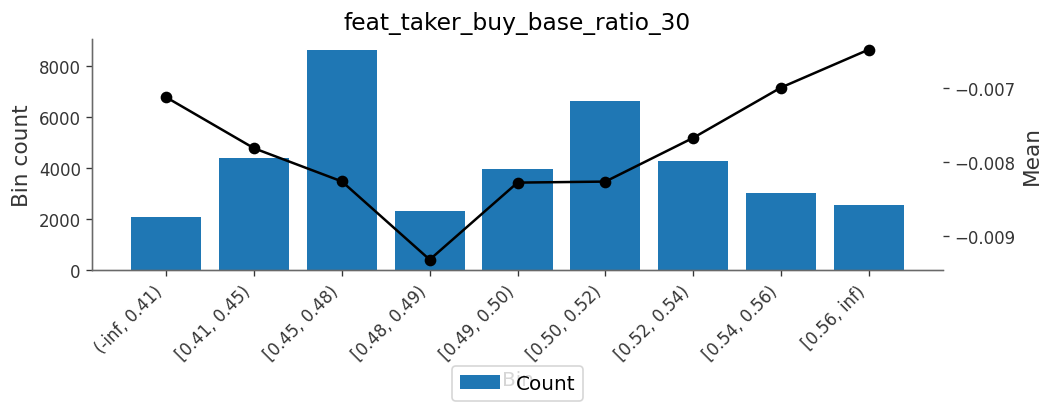




### feat_taker_flow_confirmed_return_10


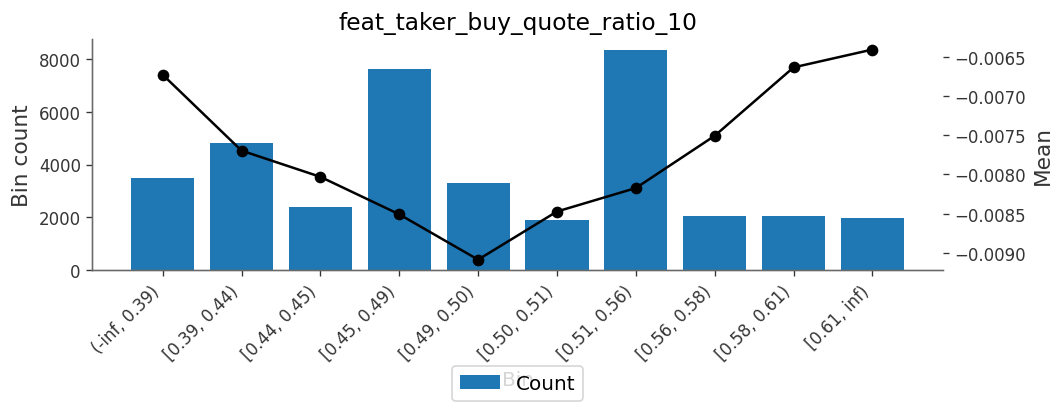




### feat_trade_count_accel_10_30




### feat_trade_count_rank_10


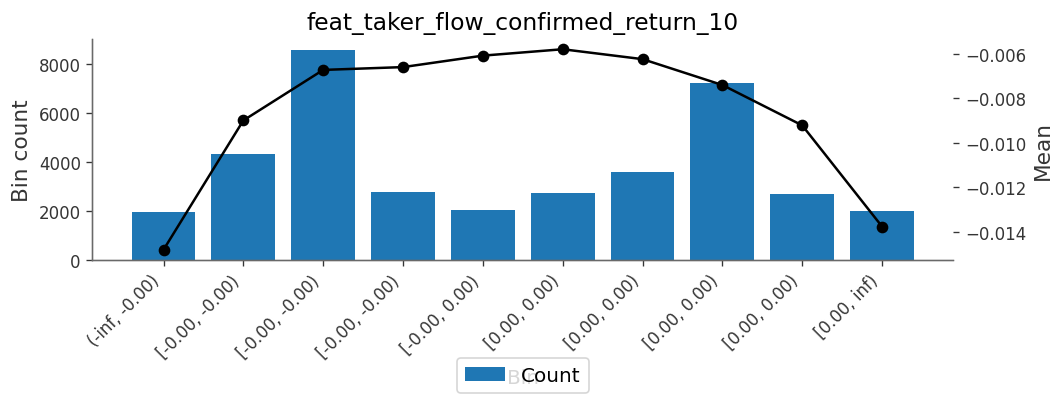
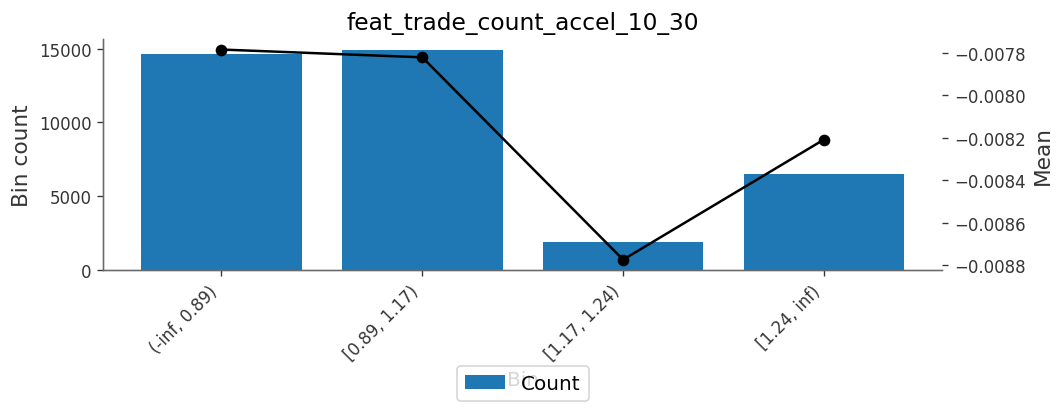




### feat_trade_count_rank_30


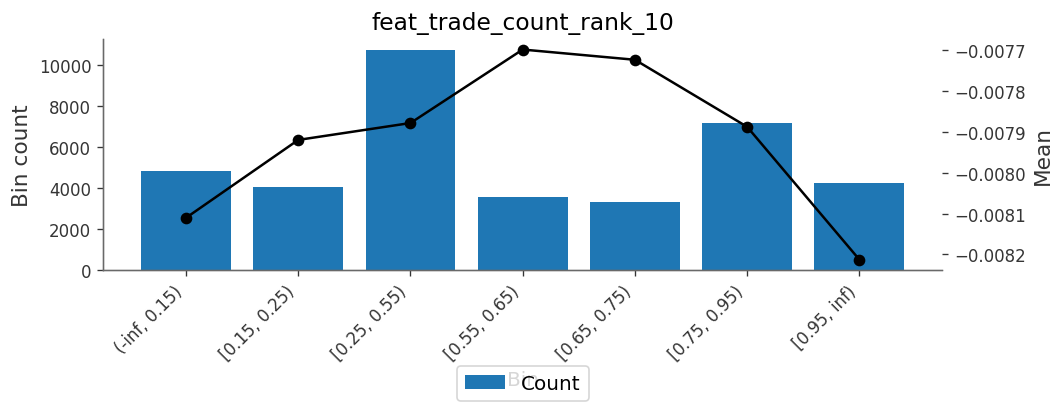




### feat_trade_count_ratio_30


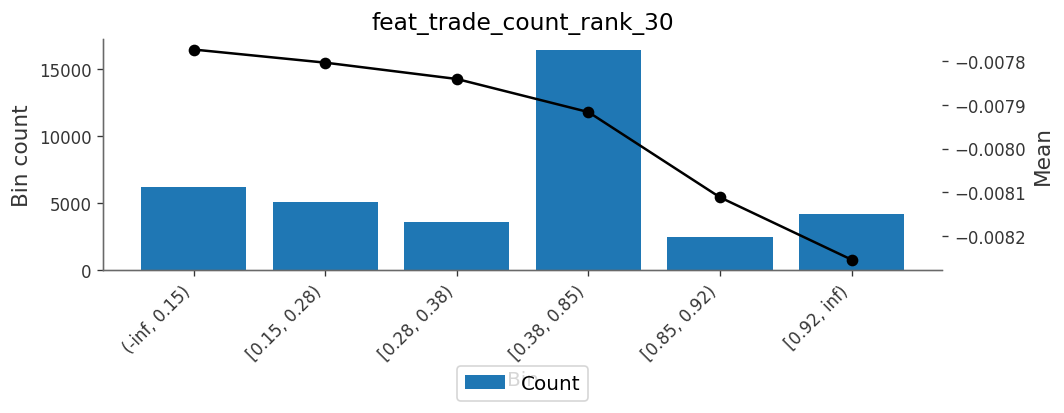



:::


## Momentum

**Momentum jellemzők** — a leggyakoribb technikai momentum-indikátorok.

- **RSI**: Wilder-EWM alapú relatív erőindex (0-100), com = W-1

- **ROC**: Rate of Change = %-os árváltozás W bár alatt

- **Stochastic %K/%D**: az ár helyzete a W-bári HH-LL tartományban, %D = %K 3-bári SMA-ja

- **Williams %R**: inverz Stochastic (-100..0)

- **CCI**: Typical Price és annak SMA-jától való MAD-normalizált eltérés

- **ADX/+DI/-DI**: Wilder-EWM alapú iránymutató erőindex (+DI = felfelé, -DI = lefelé)

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `cci_20` | CCI-20: (TP - SMA(TP,20)) / (0.015 * MAD(TP,20)) — TP=(H+L+C)/3 |
| `roc_14` | ROC-14: (close / close[-14] - 1) * 100 — 14-bari ar-ROC |
| `roc_140` | ROC-140: (close / close[-140] - 1) * 100 — 140-bari ar-ROC |
| `rsi_14` | RSI-14: 100 - 100/(1 + avg_gain/avg_loss) — Wilder EWM, com=13, min_samples=14 |
| `stoch_d_14` | Stochastic %D-14: %K_14 3-bari SMA-ja (signal) |
| `stoch_k_14` | Stochastic %K-14: (cl
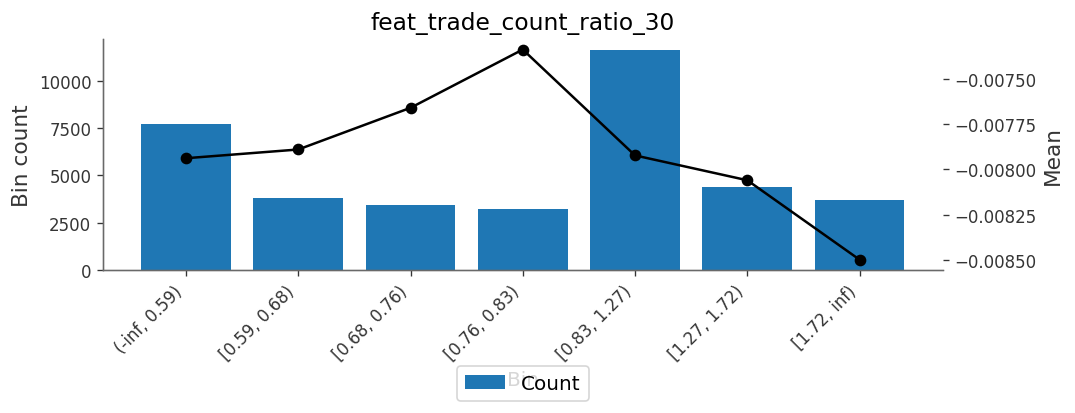



::: {.panel-tabset}


### feat_cci_20


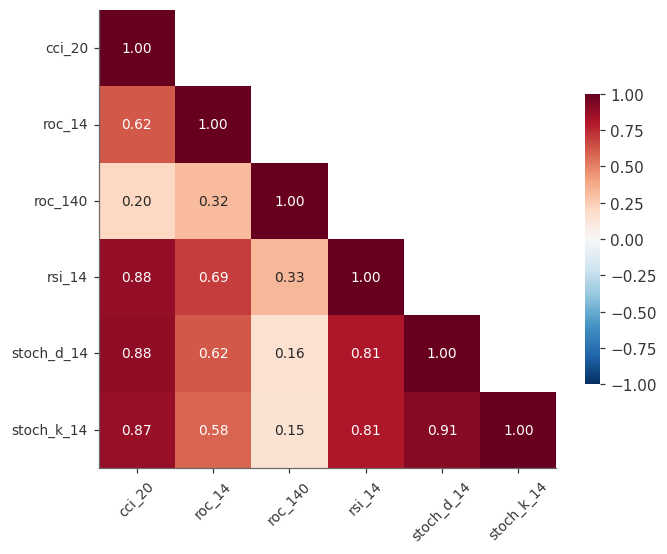




### feat_roc_14


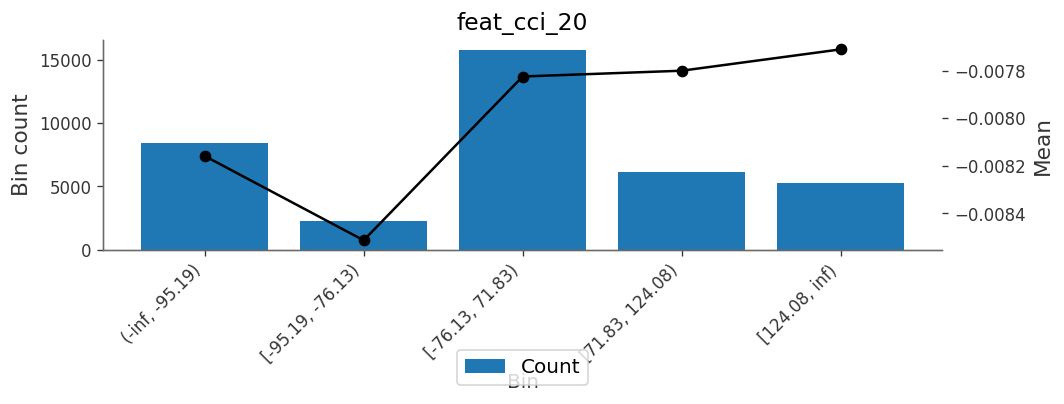




### feat_roc_140


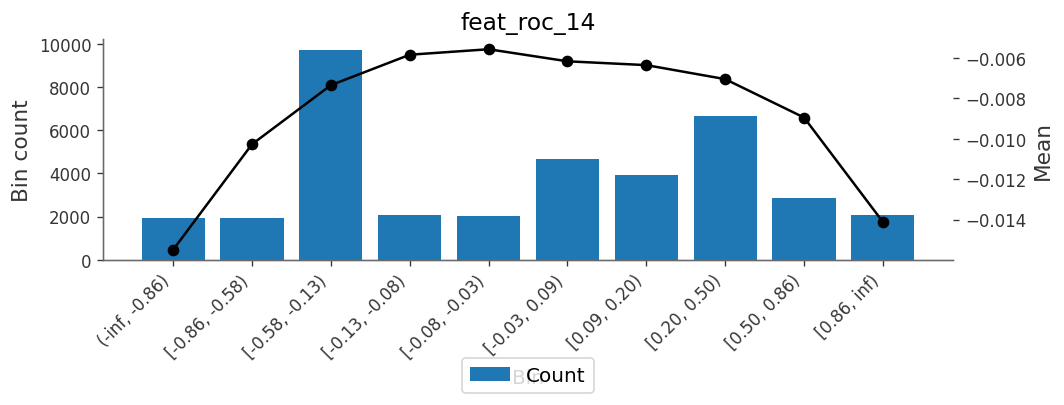




### feat_rsi_14


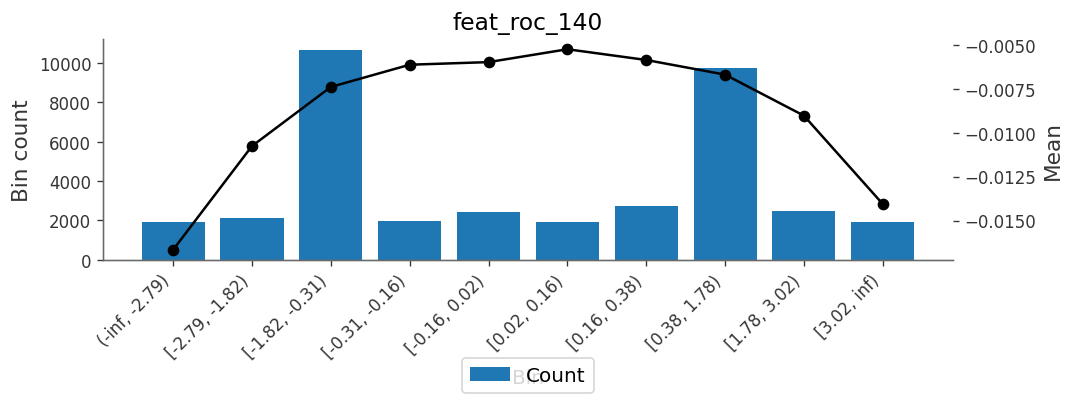




### feat_stoch_d_14


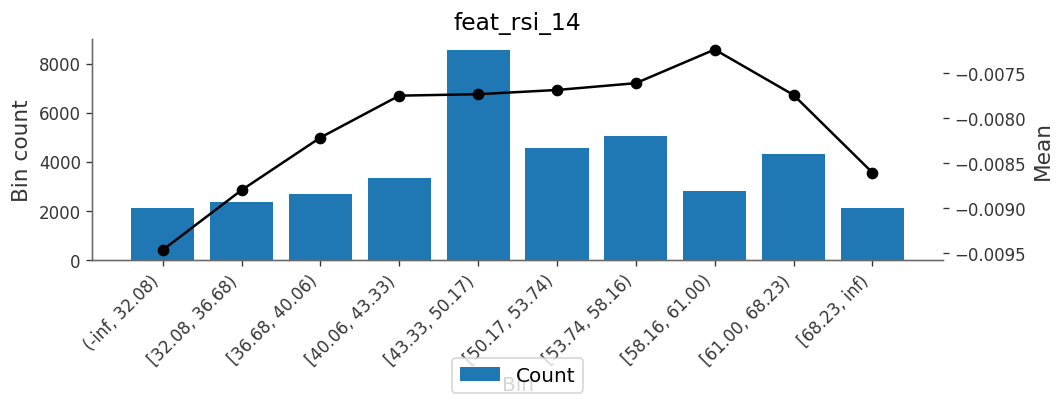




### feat_stoch_k_14


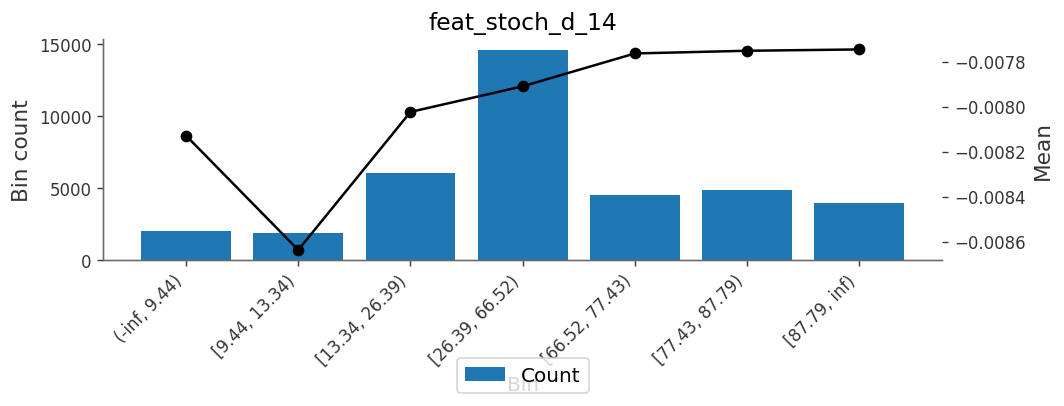



:::


## Trend

**Trend jellemzők** — mozgóátlag-alapú trend-indikátorok.

- **SMA/EMA/WMA/KAMA ratio**: close / MA — árpozíció a mozgóátlaghoz képest (1.0 = pontosan MA-n)

- **KAMA** (Kaufman Adaptive MA): az Efficiency Ratio alapján adaptív simítási faktort alkalmaz;
  gyors/lassú EMA közt interpolál a trendszerűség függvényében

- **MACD**: EMA_fast - EMA_slow, signal = MACD EWM-je, diff = MACD - signal (hisztogram)

- **ADX**: iránymutató mozgás erőssége

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `adx_14` | ADX-14: Wilder-EWM alapu DX simítasa — irányjelzett mozgáserő-index |
| `adx_neg_14` | -DI-14: 100 * EWM(-DM,14) / EWM(TR,14) — lefele iranyulo mozgas ereje |
| `adx_pos_14` | +DI-14: 100 * EWM(+DM,14) / EWM(TR,14) — felfele iranyulo mozgas ereje |
| `ema_ratio_14` | close / EMA_14 — ar / 14-bari EMA (span=14, adjust=False) |
| `ema_ratio_140` | close / EMA_140 — ar / 140-bari EMA (span=140, adjust=False) |
| `kama_ratio_10_2_30` | close / KAMA(W=10,fast=2
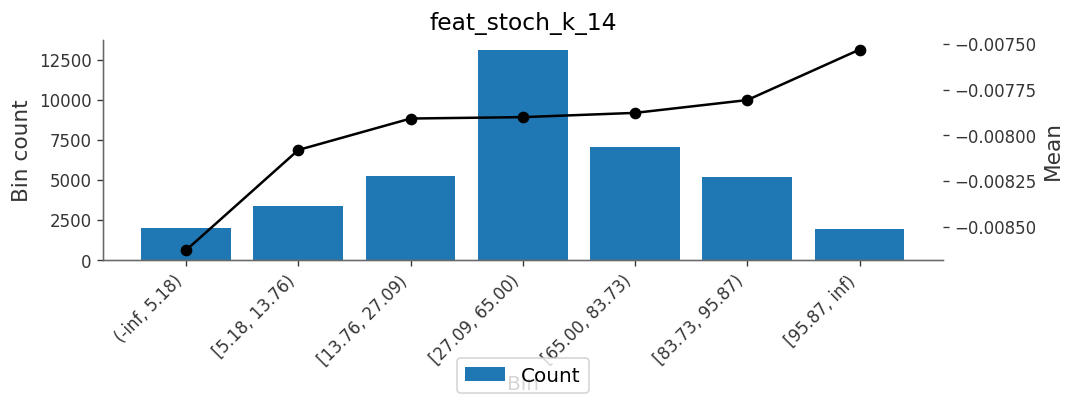



::: {.panel-tabset}


### feat_adx_14


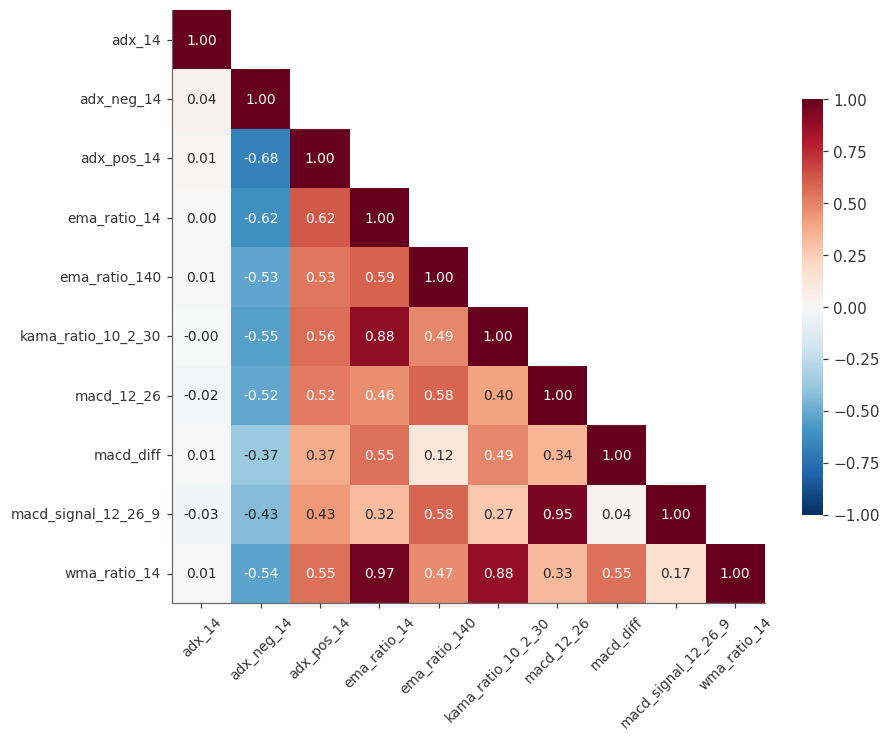




### feat_adx_neg_14


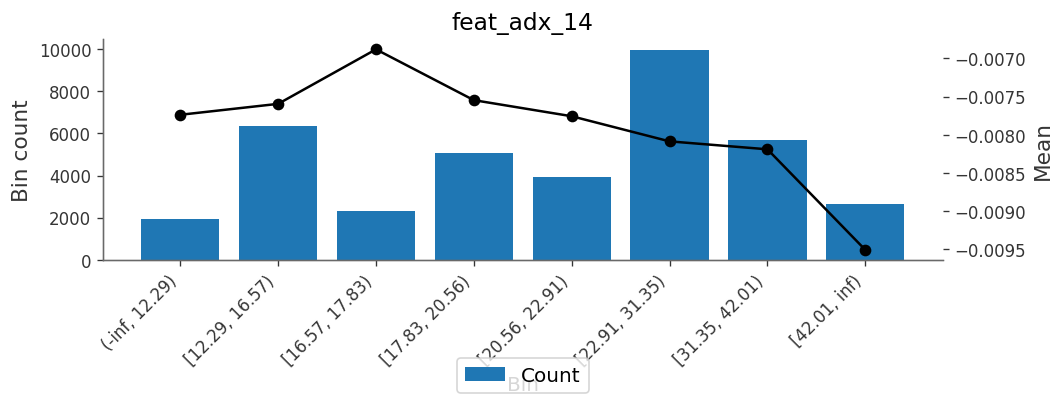




### feat_adx_pos_14


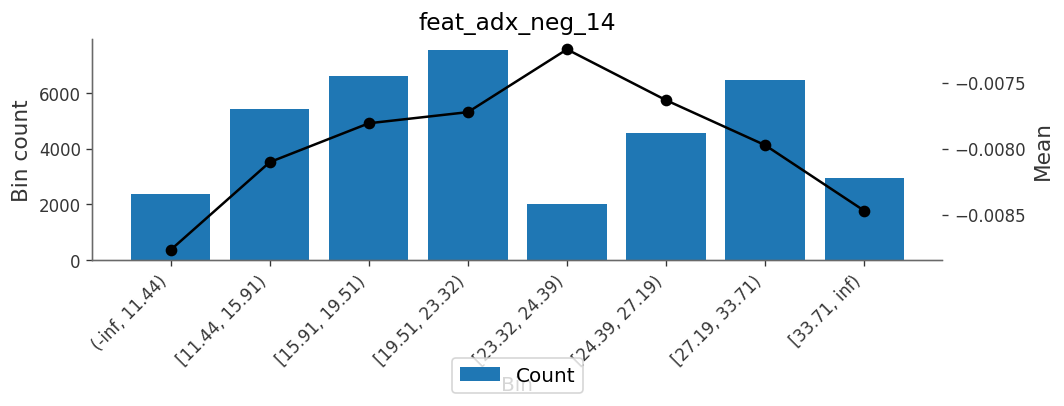




### feat_ema_ratio_14


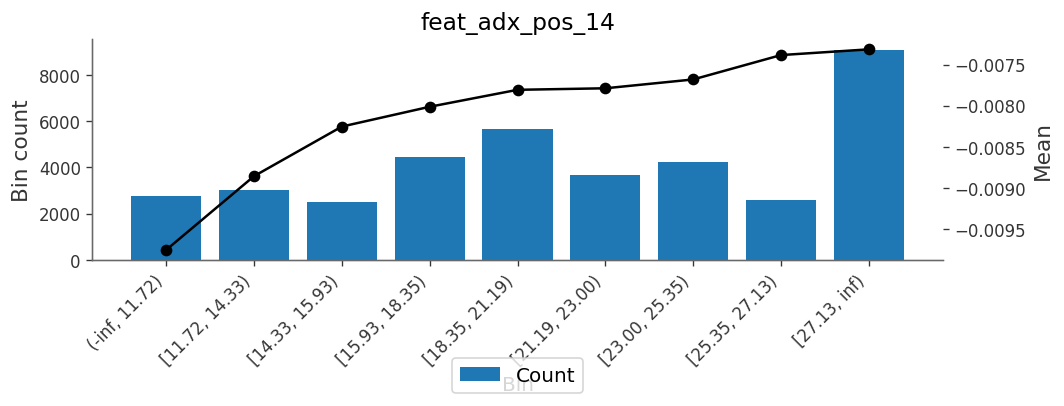




### feat_ema_ratio_140


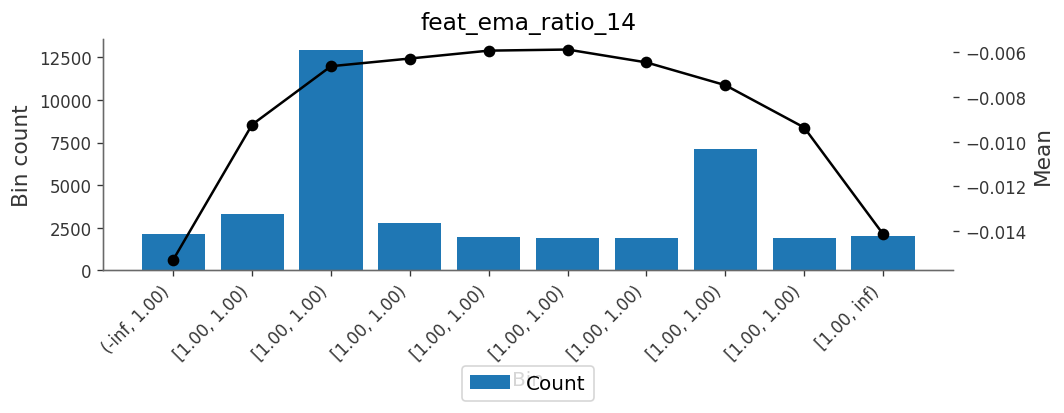




### feat_kama_ratio_10_2_30


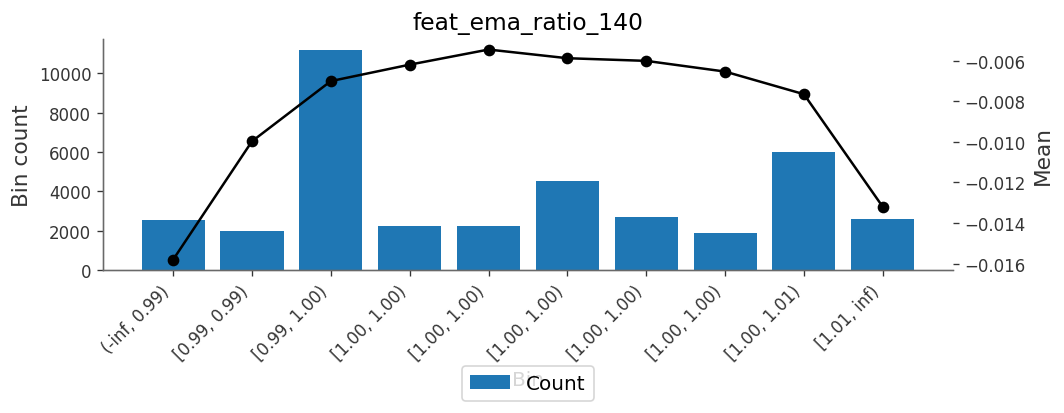




### feat_macd_12_26


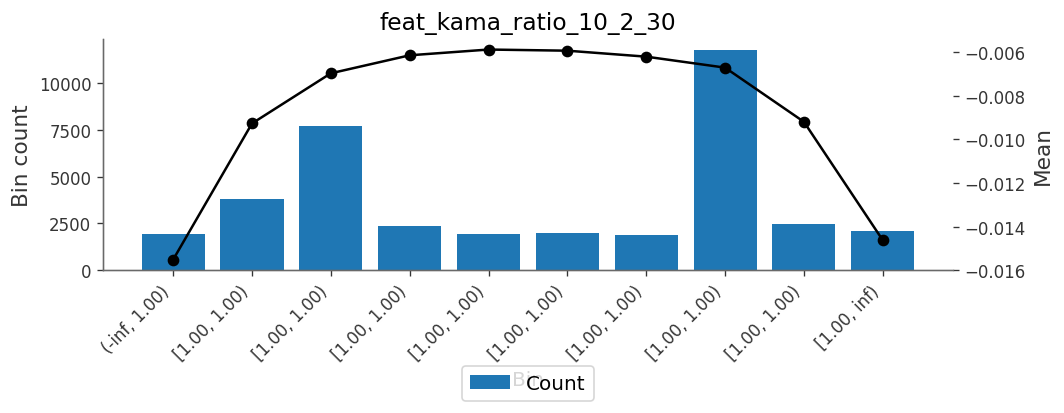




### feat_macd_diff


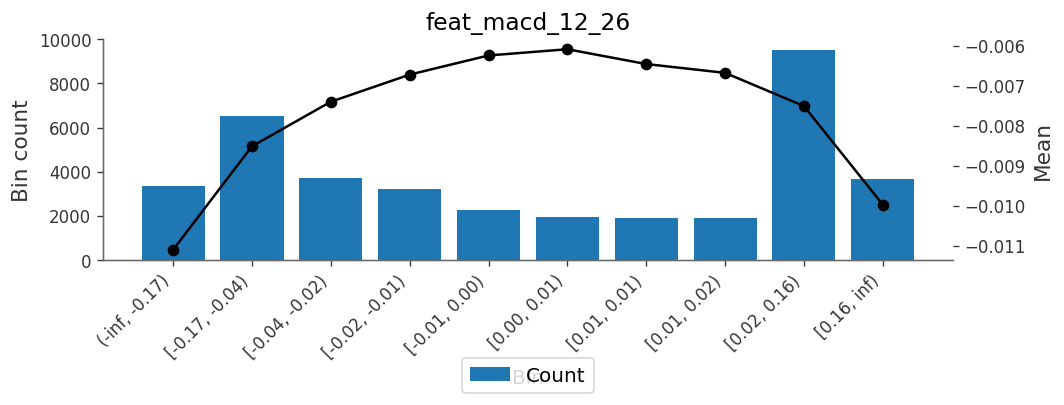




### feat_macd_signal_12_26_9


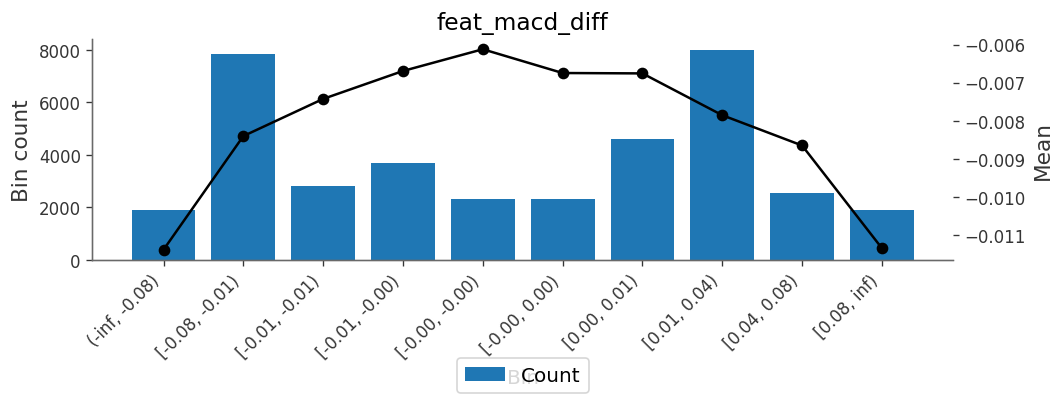




### feat_wma_ratio_14


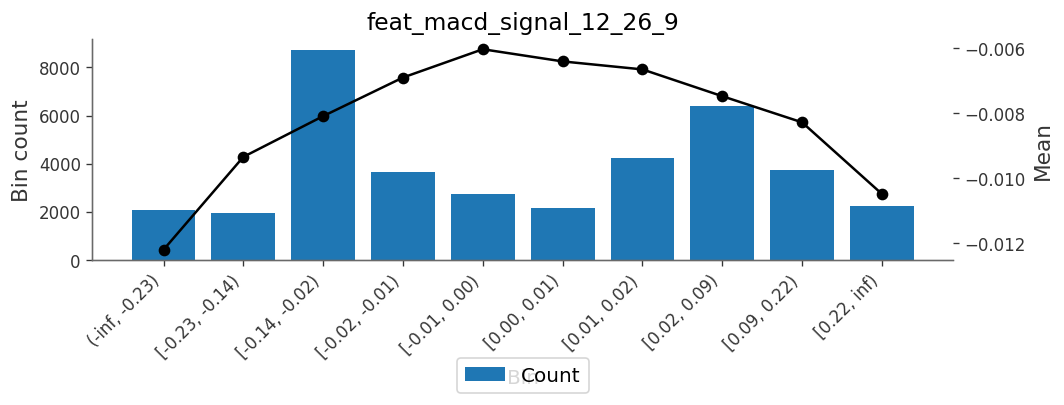



:::


## Autocorrelation

**Autokorrelációs jellemzők** — a log-return-sorozat önkorrelációja és varianciaarány-teszt.
Azt méri, hogy az egymást követő hozamok mennyire "emlékeznek" egymásra.
Pozitív autokorreláció → trend-tendencia, negatív → mean-reversion.
A variancia-arány (variance ratio) a random walk-hipotézis tesztje:
1.0 = véletlen bolyongás, >1 = trend, <1 = mean-reversion tendencia.
Lag-értékek: 1 és 5 bár; gördülő ablak: 30 és 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `return_autocorr_lag1_30` | Pearson-korr: ret(t) * ret(t-1) gordulo 30-bari ablakban — -1..+1 |
| `return_autocorr_lag1_60` | Pearson-korr: ret(t) * ret(t-1) gordulo 60-bari ablakban — -1..+1 |
| `return_autocorr_lag5_30` | Pearson-korr: ret(t) * ret(t-5) gordulo 30-bari ablakban — -1..+1 |
| `return_autocorr_lag5_60` | Pearson-korr: ret(t) * ret(t-5) gordulo 60-bari ablakban — -1..+1 |
| `variance_ratio_10_60` | Var(ret_10) / (Var(ret1)*10) — 60-bari ablak — 1.0=random walk, >1=
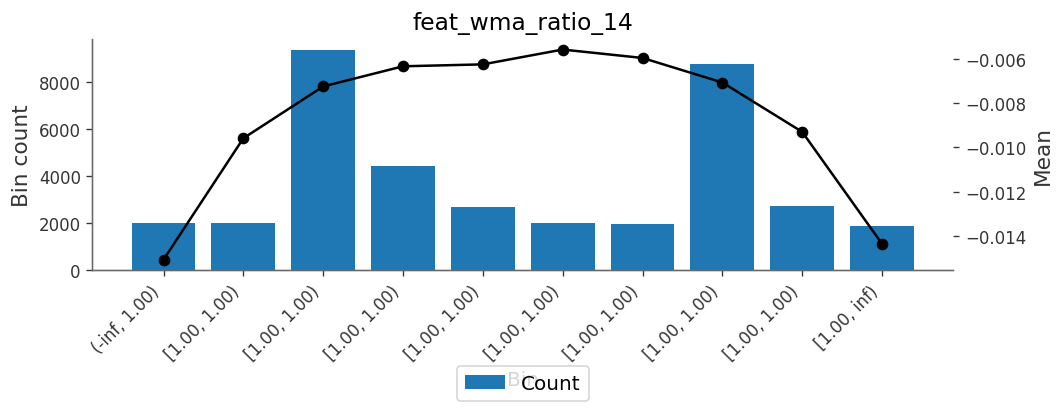



:::


## Market Structure

**Piaci struktúra (Market Structure)** — az ár pozíciója a közelmúltbeli csúcsokhoz és mélypontokhoz képest,
drawdown, recovery és hatékonysági mutatók.
ATR-normalizált távolságok a W-periódusos rolling high/low-tól, drawdown és recovery mérők,
az előző napi session high/low-tól vett ATR-távolság, valamint efficiency ratio
(mennyire "egyenes" az ármozgás, 0 = kaotikus, 1 = tökéletes trend).
Ablakméret: 10, 30, 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `atr_dist_high_10` | (rolling_max_10(H) - close) / ATR14 — tavolsag a 10-bari csucstol ATR-egysegben |
| `atr_dist_high_30` | (rolling_max_30(H) - close) / ATR14 — tavolsag a 30-bari csucstol ATR-egysegben |
| `atr_dist_high_60` | (rolling_max_60(H) - close) / ATR14 — tavolsag a 60-bari csucstol ATR-egysegben |
| `atr_dist_low_10` | (close - rolling_min_10(L)) / ATR14 — tavolsag a 10-bari melyponttol ATR-egysegben |
| `atr_dist_low_30` | (close - rolling_min_30(L)) / ATR14 — tavols
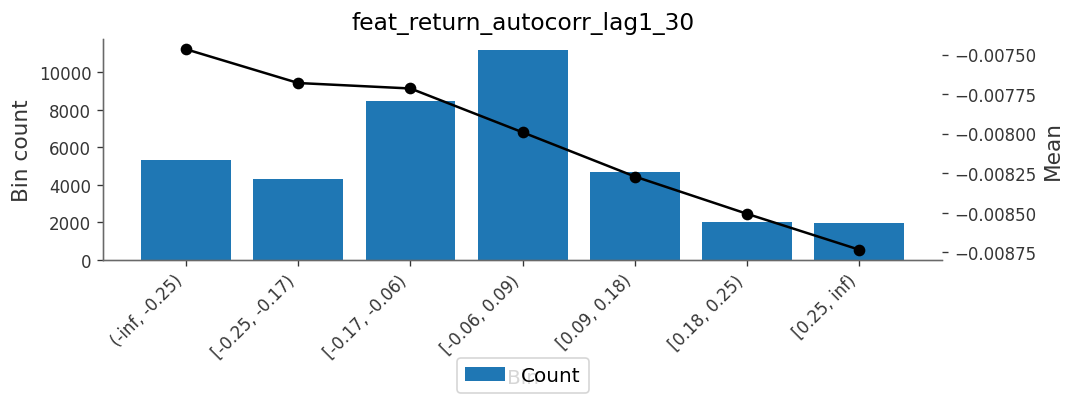



::: {.panel-tabset}


### feat_atr_dist_high_10


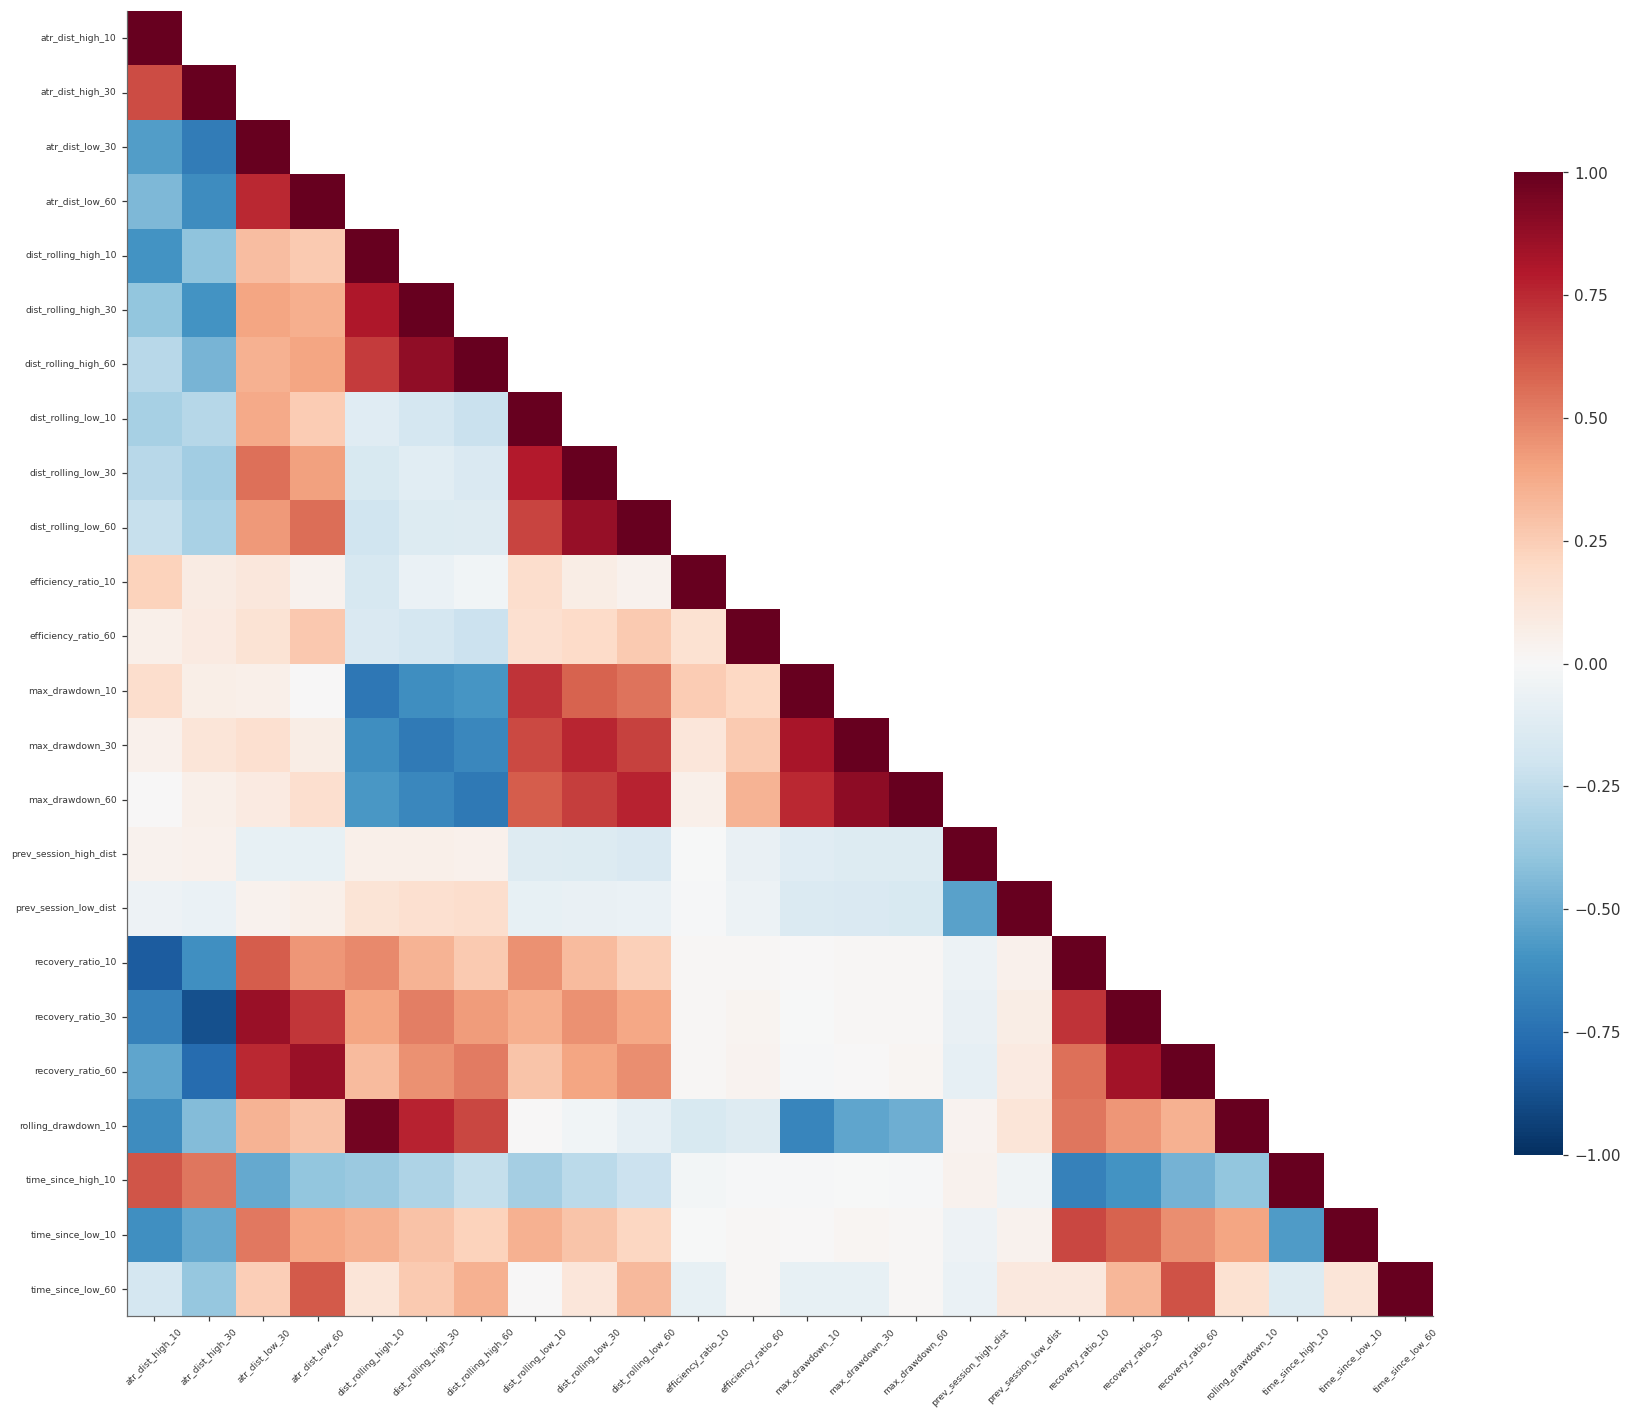




### feat_atr_dist_high_30


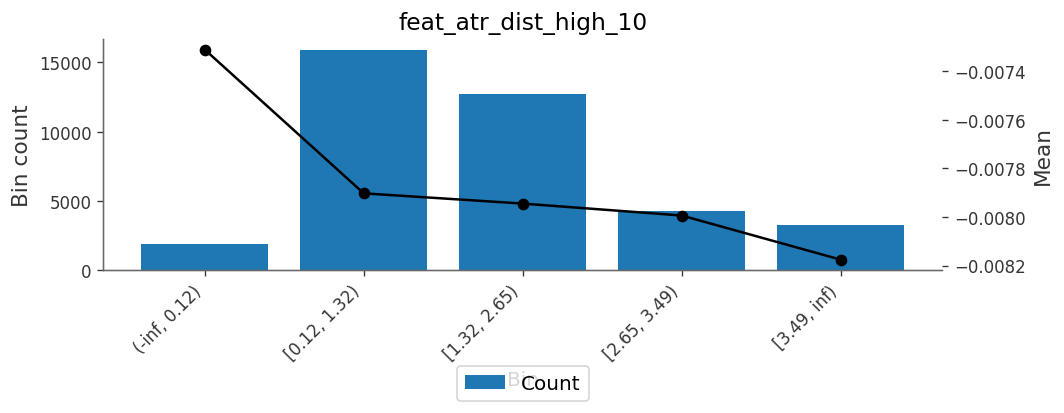




### feat_atr_dist_low_30


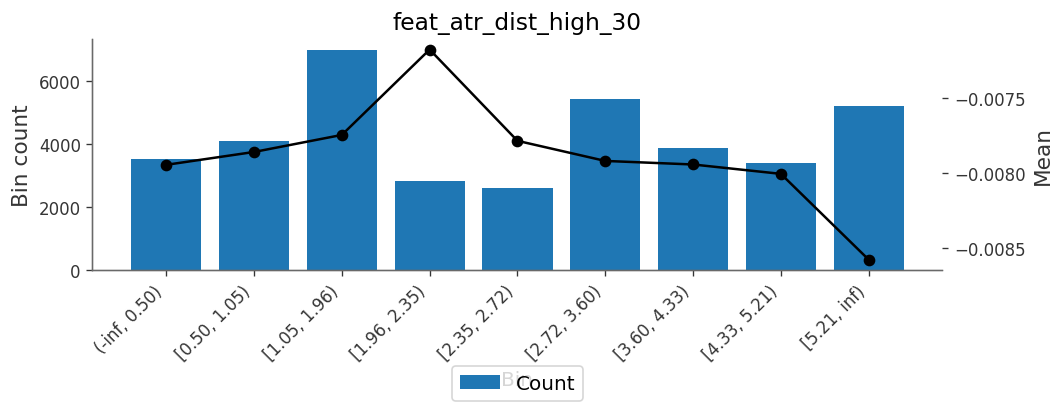




### feat_atr_dist_low_60


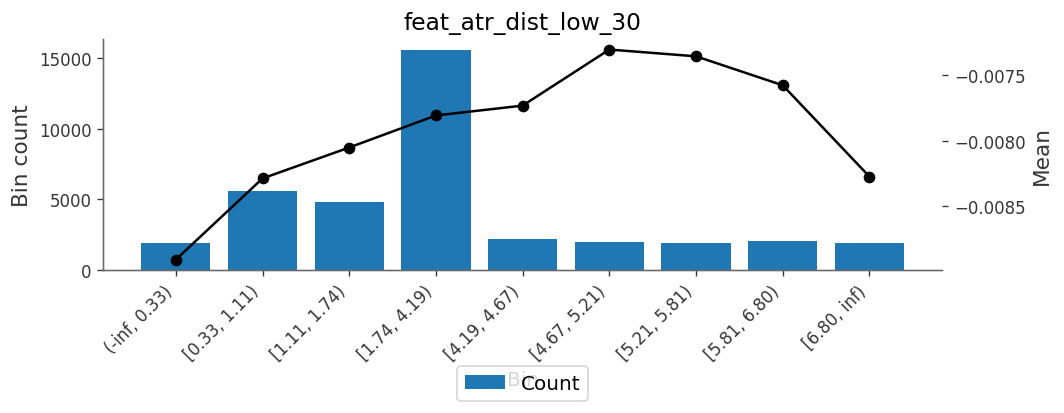




### feat_dist_rolling_high_10


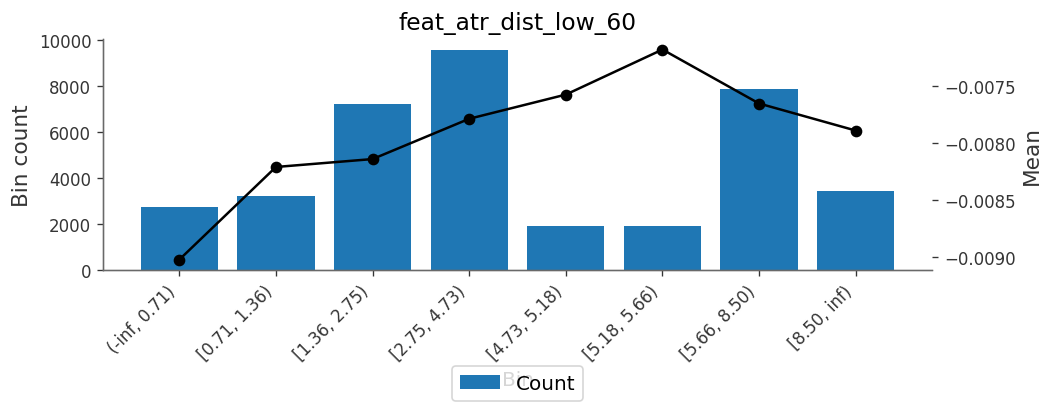




### feat_dist_rolling_high_30


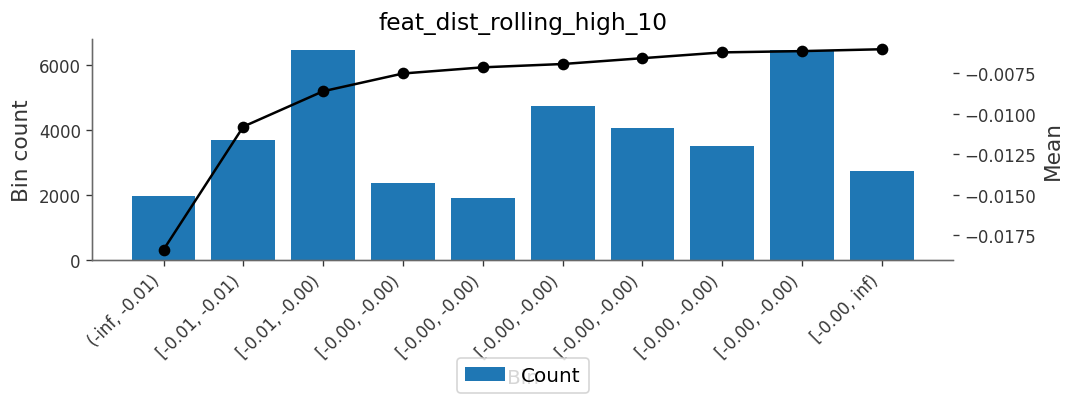




### feat_dist_rolling_high_60


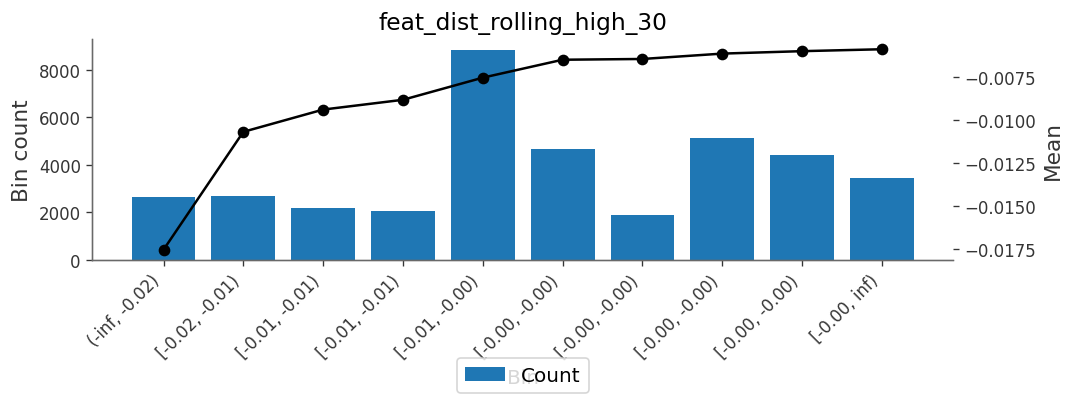




### feat_dist_rolling_low_10


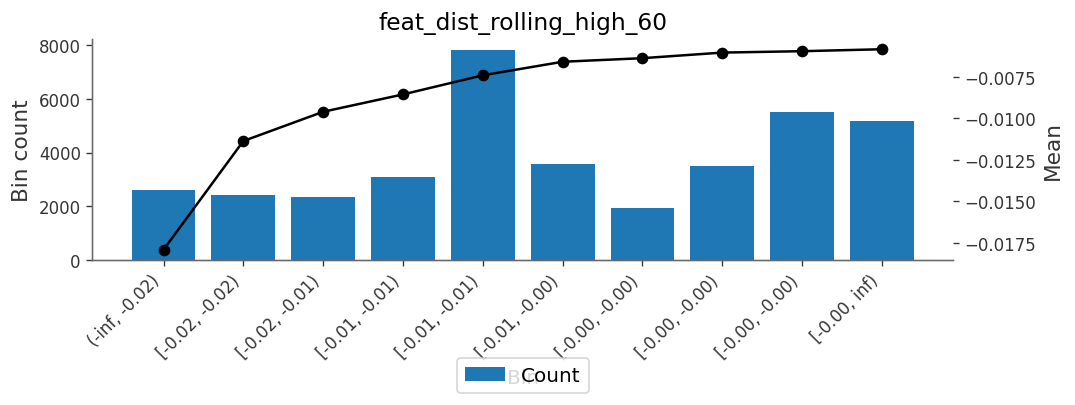




### feat_dist_rolling_low_30


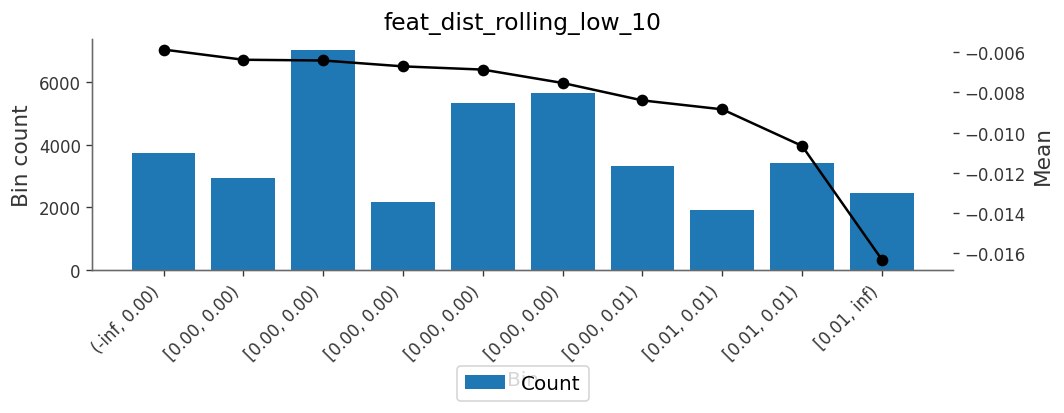




### feat_dist_rolling_low_60


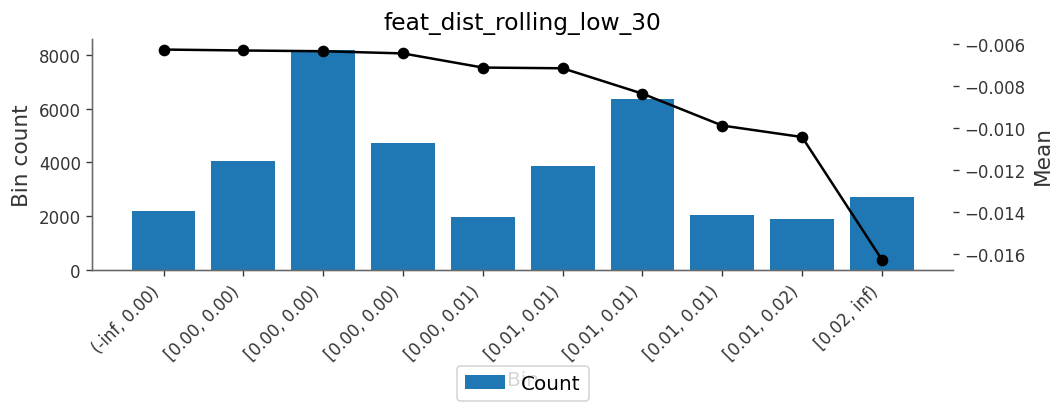




### feat_efficiency_ratio_10


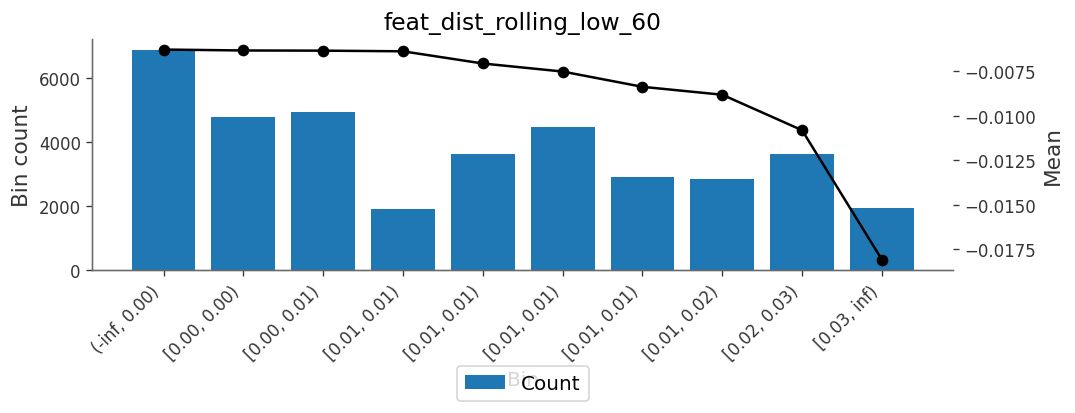




### feat_efficiency_ratio_60


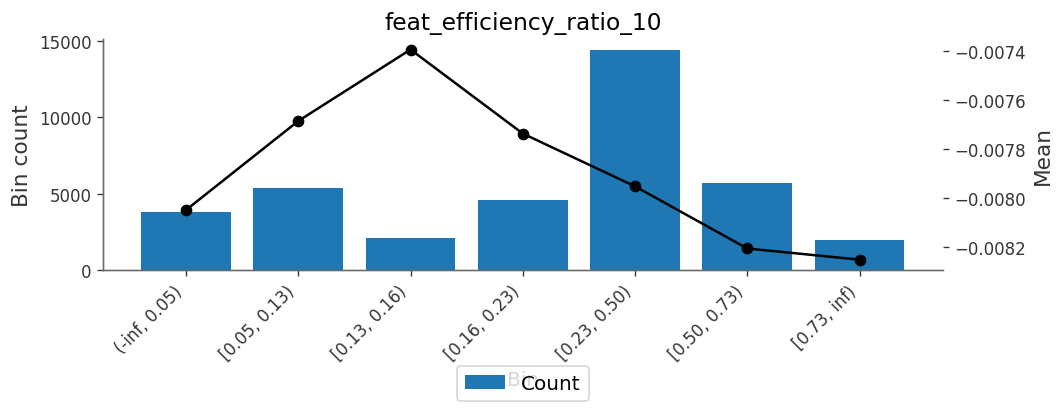




### feat_max_drawdown_10


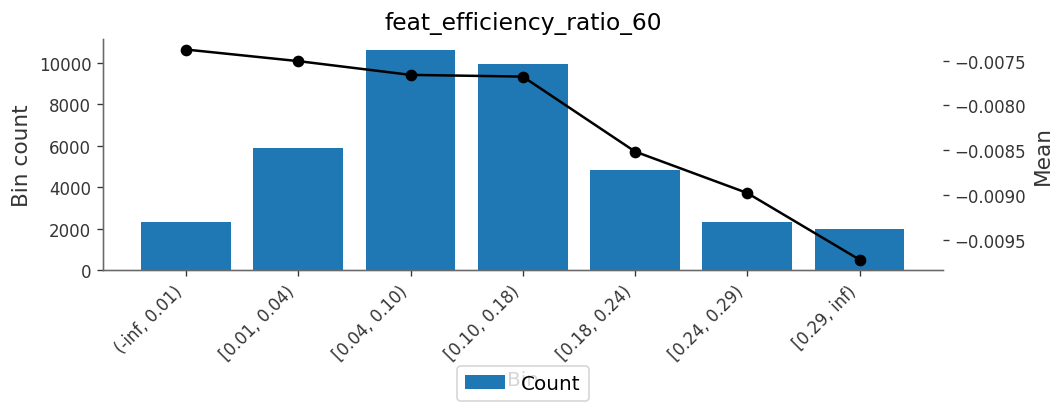




### feat_max_drawdown_30


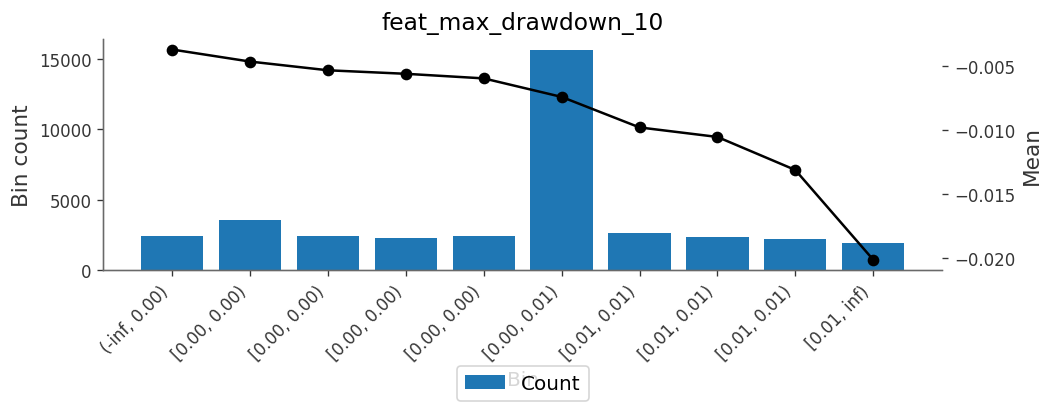




### feat_max_drawdown_60


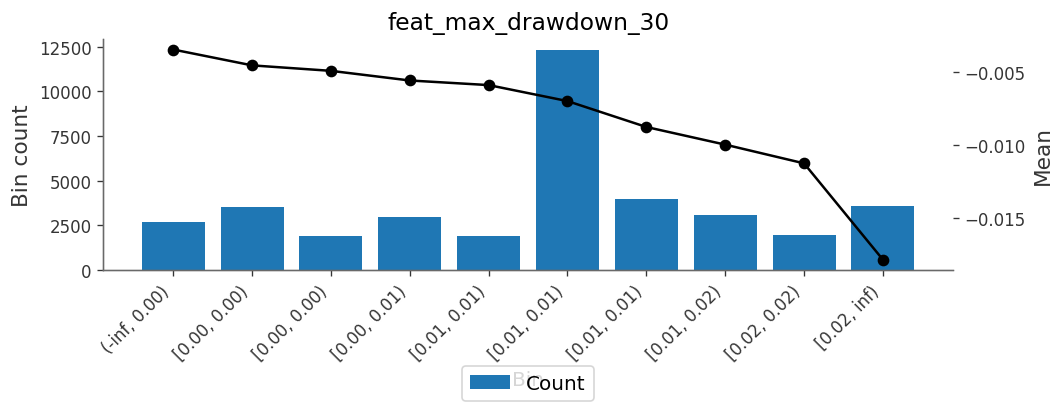




### feat_prev_session_high_dist




### feat_prev_session_low_dist


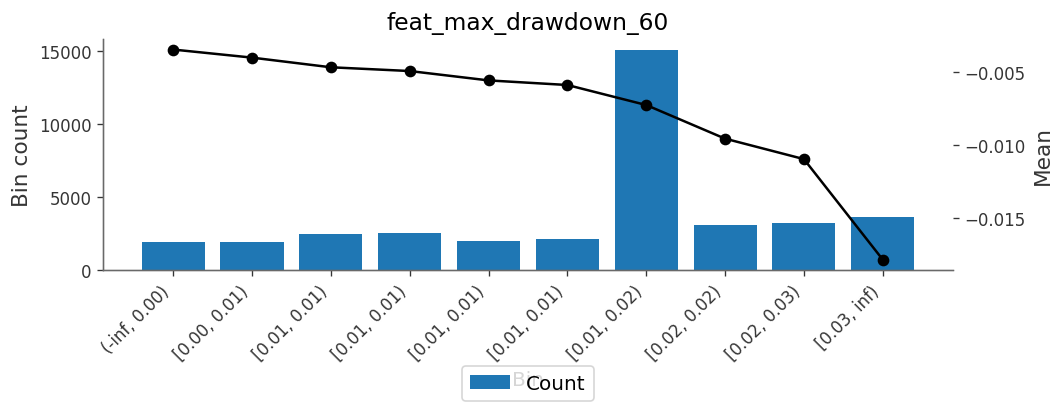
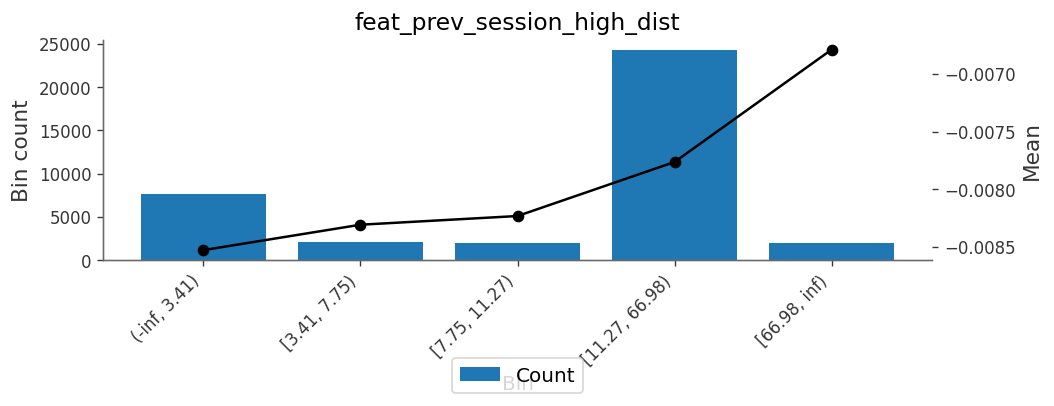




### feat_recovery_ratio_10




### feat_recovery_ratio_30


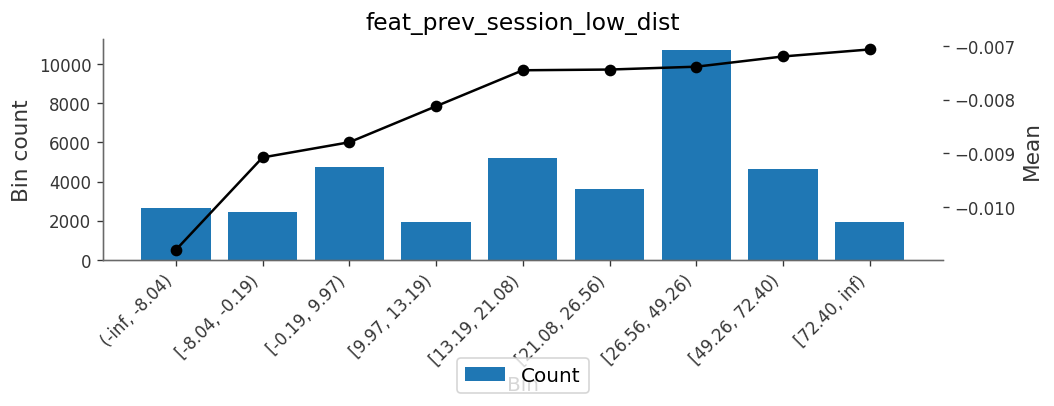
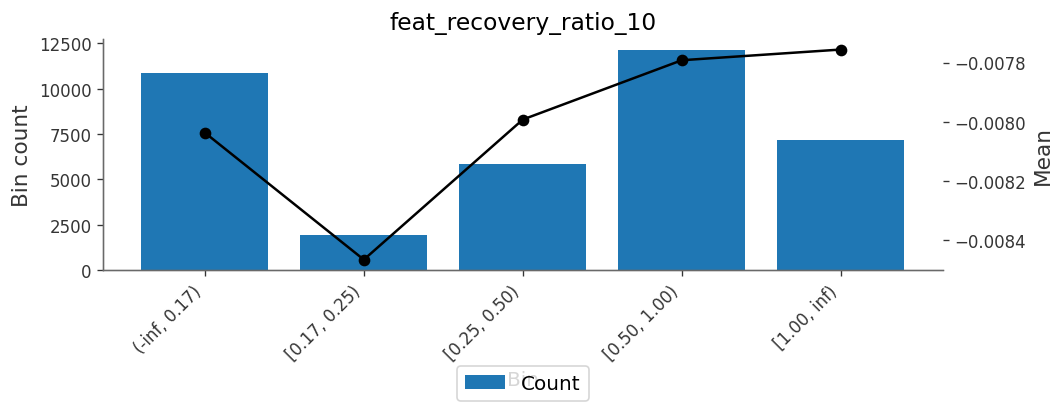




### feat_recovery_ratio_60


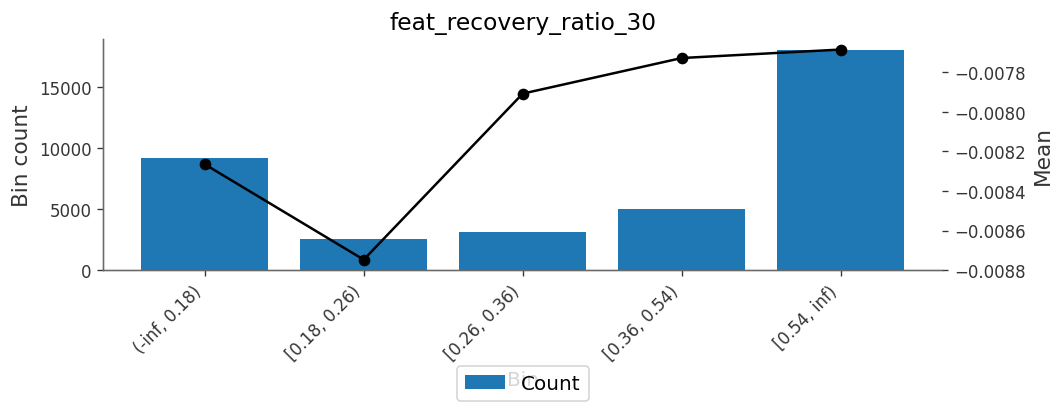




### feat_rolling_drawdown_10


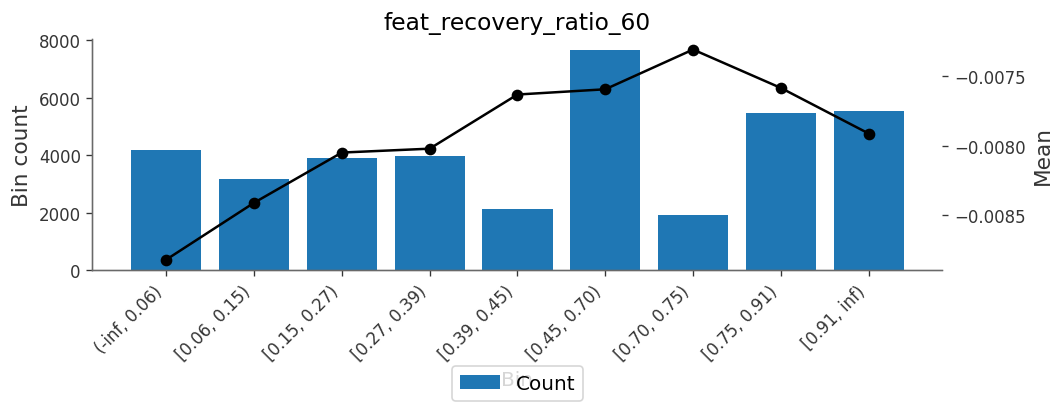




### feat_time_since_high_10


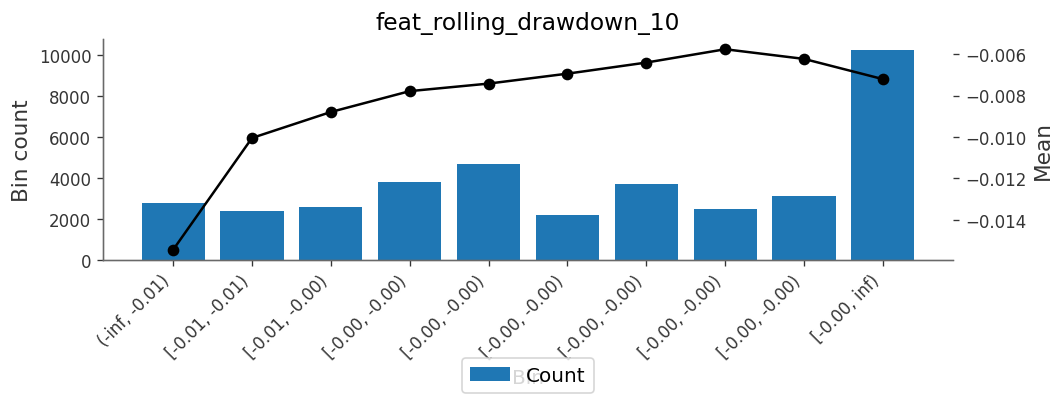




### feat_time_since_low_10




### feat_time_since_low_60


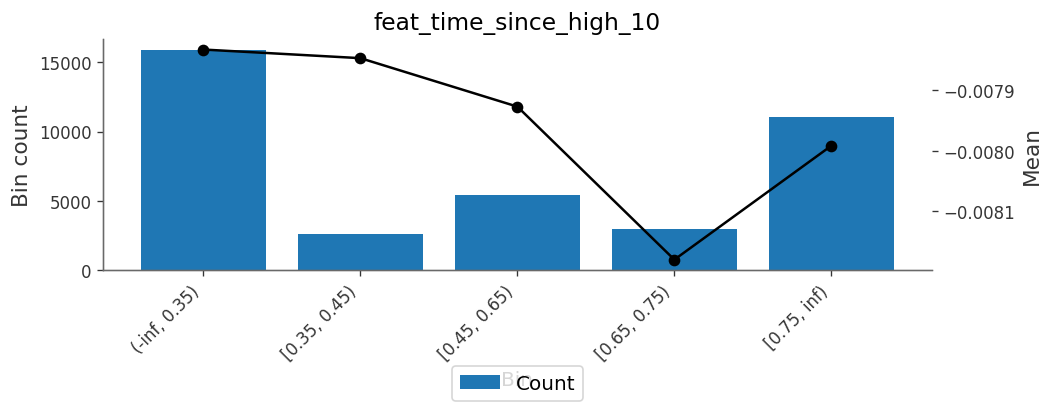
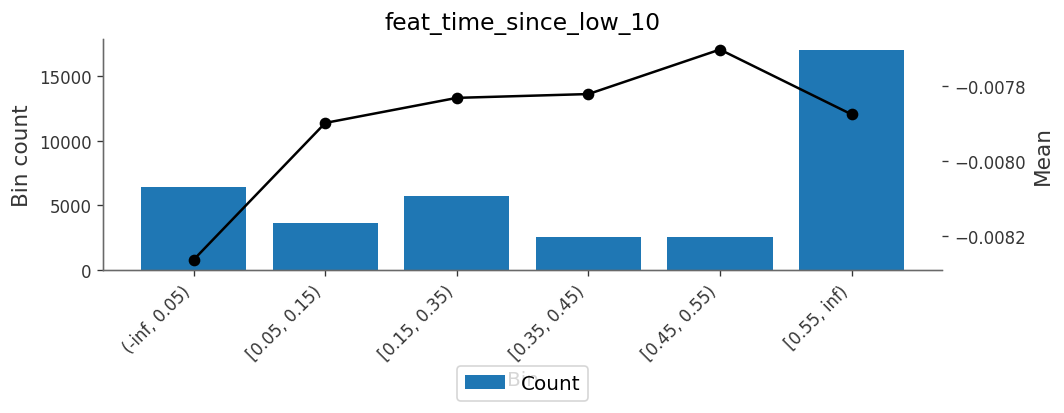



:::


## Swing

**Swing struktúra (Swing)** — higher high/low és lower high/low darabszáma W bár alatt,
swing pontok és irányzategyezés mérői.
A directional_agreement azt mutatja, hogy a rövid és közepes trend iránya egyezik-e:
+1 = mindkét irány azonos (trendkonszisztencia), -1 = ellentétes (potenciális fordulat).
Ablakméret: 10, 30, 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `directional_agreement_10_30` | sign(ret_10) * sign(ret_30) — 10 es 30 bari return iranyanak egyezese (+1/-1) |
| `higher_high_count_5` | high > prev_high esetek szama az utolso 5 barban |
| `higher_low_count_5` | low > prev_low esetek szama az utolso 5 barban |
| `lower_high_count_5` | high < prev_high esetek szama az utolso 5 barban |
| `lower_low_count_5` | low < prev_low esetek szama az utolso 5 barban |
| `swing_high_5` | high >= rolling_max(H, 5) => 5-bari swing high (1/0) |
| `swing_low_5` | low <= rolling_min(L, 5) => 5-bari swing low (1/0) |

<style type="text/css">
#T_8d9a7
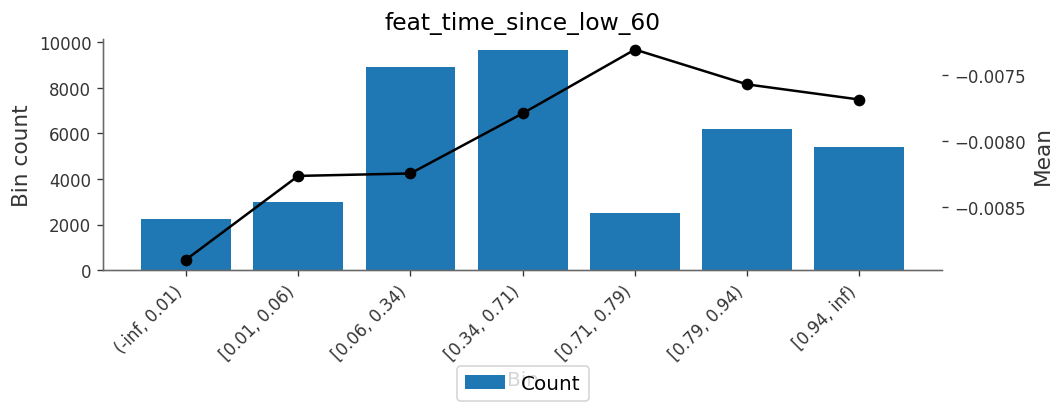
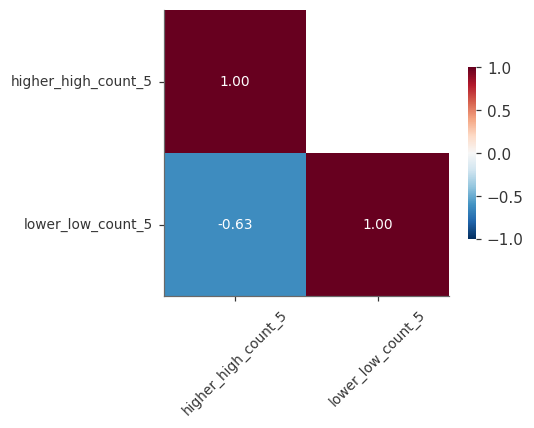




### feat_lower_low_count_5



:::


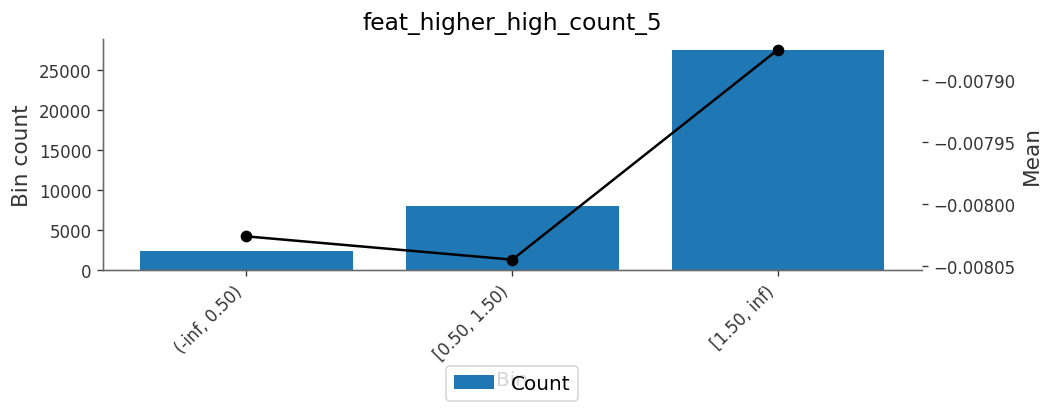
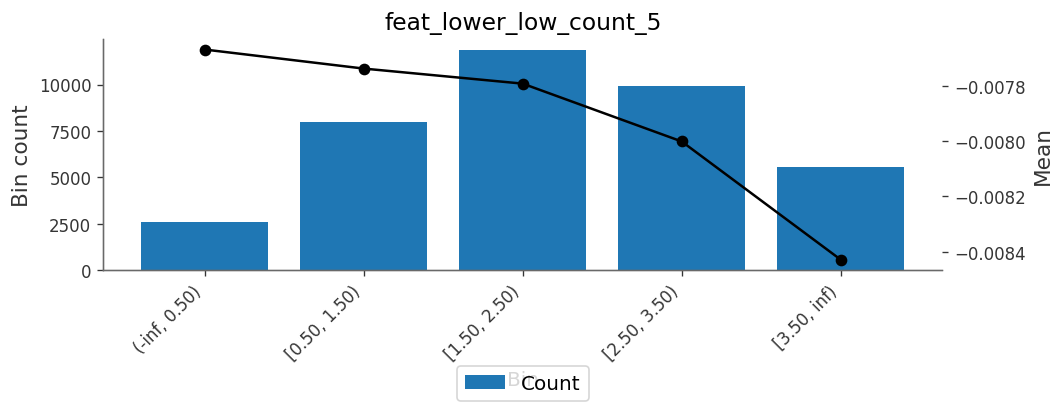


## Tail Risk

**Farok-kockázat (Tail Risk)** — az ár felfele és lefele irányú szélsőértékeinek aszimmetriája W bárra.
A return_asymmetry megmutatja, hogy a pozitív vagy a negatív irányú mozgások dominálnak-e.
Értéke > 1.0 => bullish aszimmetria (felfele nagyobb átlagos mozgás),
értéke < 1.0 => bearish aszimmetria.
Ablakméret: 10, 30, 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `neg_return_mean_10` | rolling_mean(|min(ret,0)|, 10) — negativ hozamok abszolut 10-bari atlaga (downside) |
| `neg_return_mean_30` | rolling_mean(|min(ret,0)|, 30) — negativ hozamok abszolut 30-bari atlaga (downside) |
| `neg_return_mean_60` | rolling_mean(|min(ret,0)|, 60) — negativ hozamok abszolut 60-bari atlaga (downside) |
| `pos_return_mean_10` | rolling_mean(max(ret,0), 10) — pozitiv hozamok 10-bari atlaga (upside intenzitas) |
| `pos_return_mean_30` | rolling_mean(max(ret,0), 30) — pozitiv hozamok 30-bari atlaga (upside intenzitas) |
| `pos_return_mean_60` | rolling_mean(max(r



::: {.panel-tabset}


### feat_neg_return_mean_10


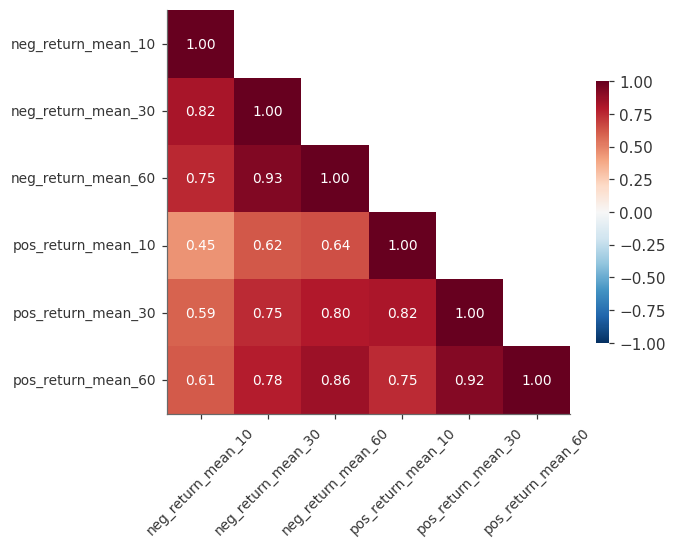




### feat_neg_return_mean_30


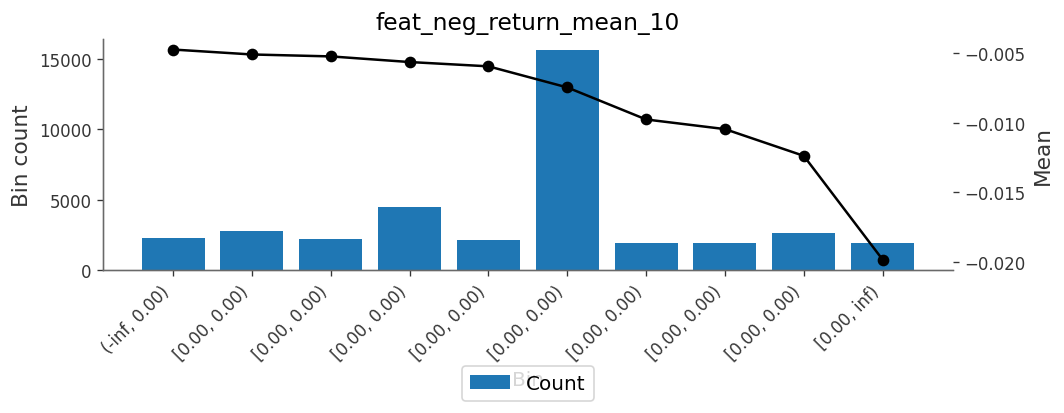




### feat_neg_return_mean_60


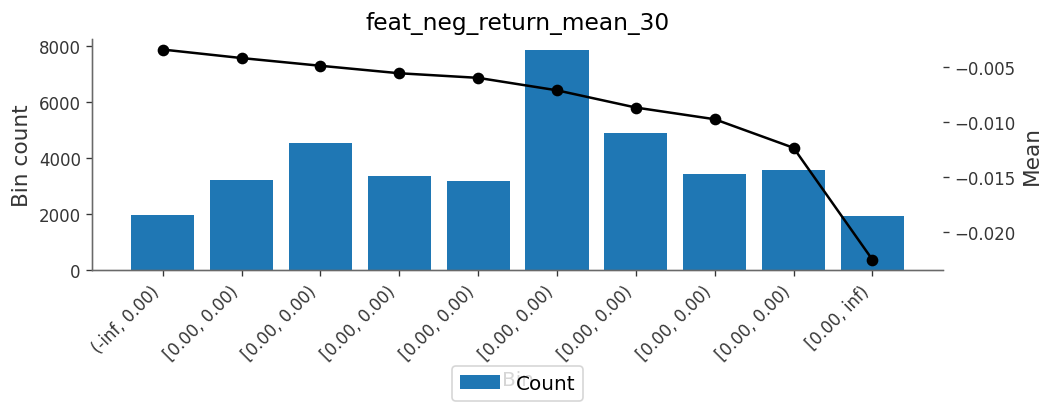




### feat_pos_return_mean_10


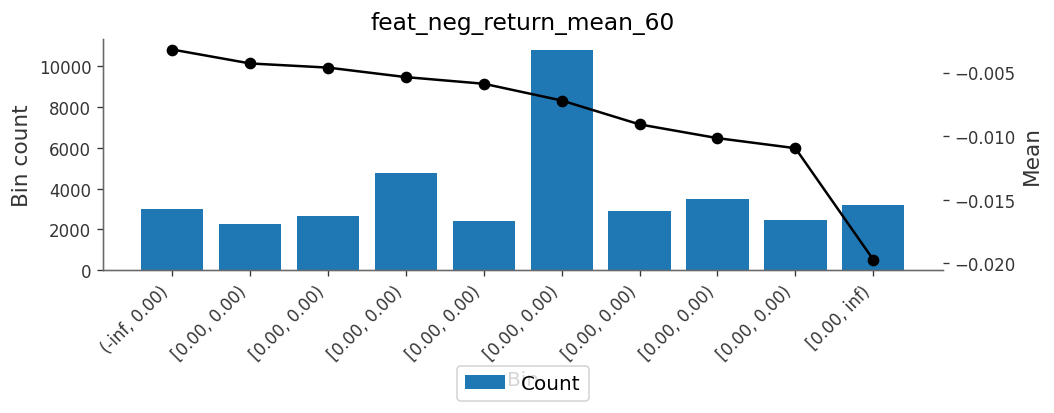




### feat_pos_return_mean_30


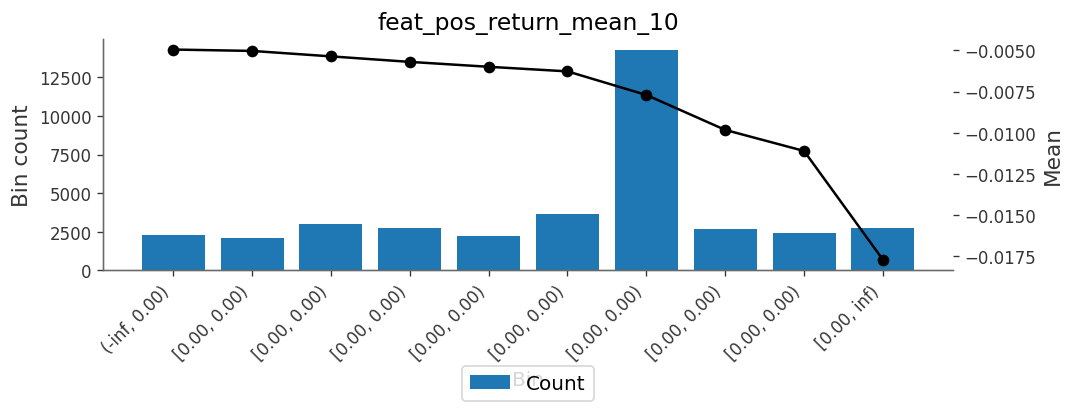




### feat_pos_return_mean_60


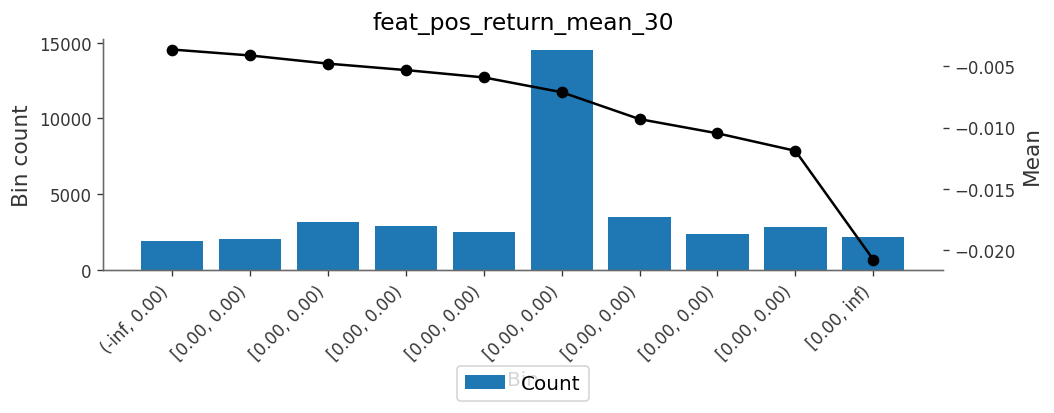



:::


## Ichimoku

**Ichimoku Cloud** — japán trendkövető rendszer 9/26/52-es periódusokkal.

- **Tenkan-sen** (Konverzió-vonal): (9-bár max + 9-bár min) / 2 — rövid trend

- **Kijun-sen** (Alap-vonal): (26-bár max + 26-bár min) / 2 — közepes trend

- **Senkou Span B** (Cloud határ): (52-bár max + 52-bár min) / 2

- A feature-ök az árhoz normalizált távolságokat adják vissza: (vonal / close) - 1

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `ichimoku_cloud_thickness` | ((tenkan+kijun)/2 - senkou_b) / close — felho vastagsaga (pozitiv = bullish cloud) |
| `kijun_ratio` | kijun_sen / close - 1 — Kijun-sen = (26-bar max + 26-bar min) / 2 |
| `price_vs_kijun` | (close - kijun) / close — ar vs. Kijun-sen pozicio |
| `price_vs_tenkan` | (close - tenkan) / close — ar vs. Tenkan-sen pozicio |
| `senkou_b_ratio` | senkou_b / close - 1 — Senkou Span B = (52-bar max + 52-bar min) / 2 |
| `tenkan_kijun_delta` | (tenkan - kijun) / close — TK-kulonbseg (cloud bias iranyjelzo) |
| 
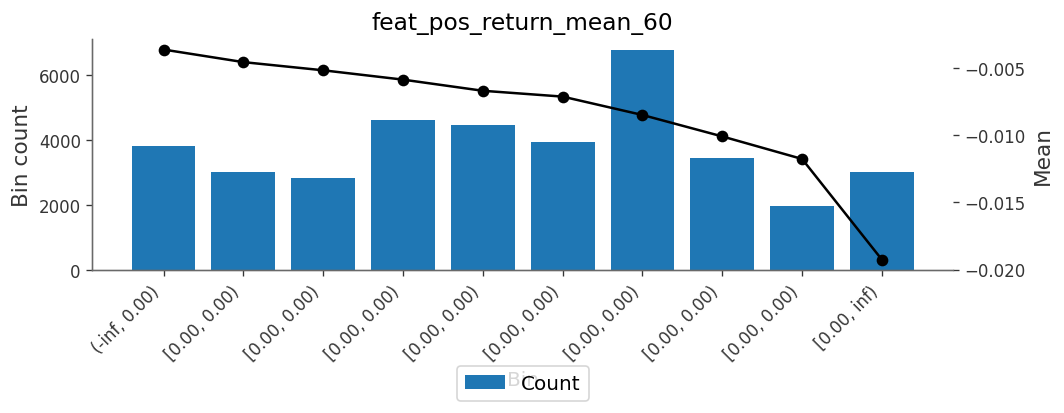



::: {.panel-tabset}


### feat_ichimoku_cloud_thickness


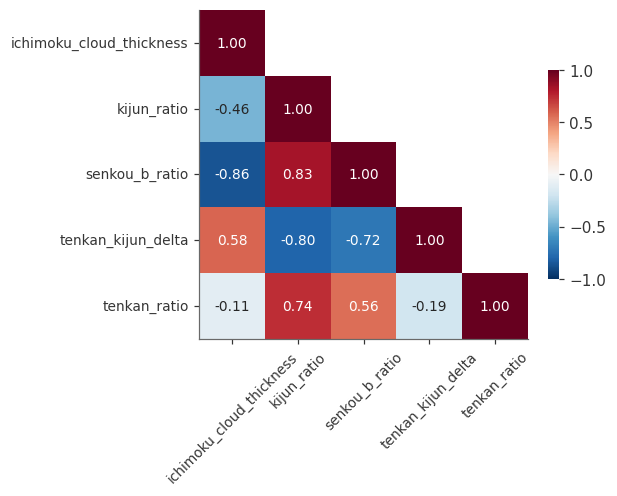




### feat_kijun_ratio


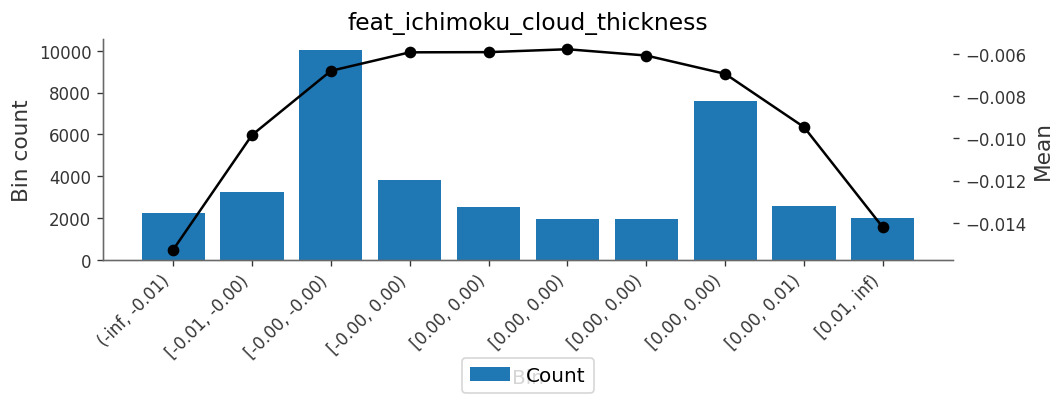




### feat_senkou_b_ratio


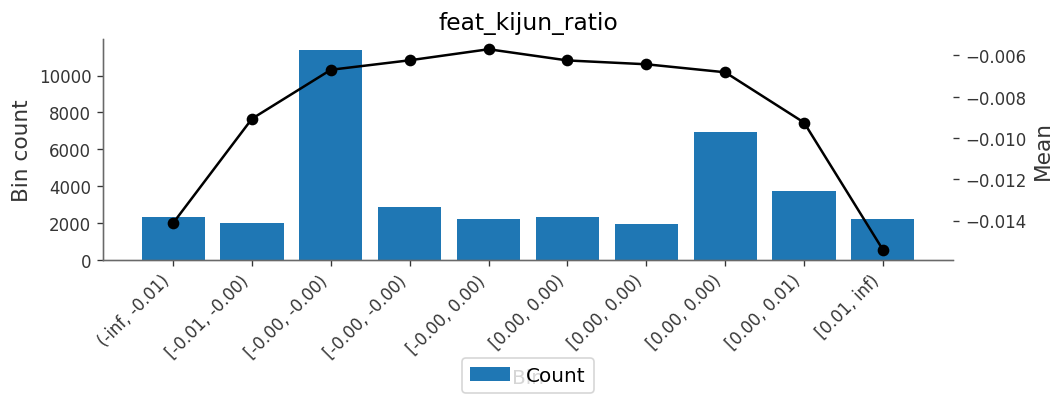




### feat_tenkan_kijun_delta


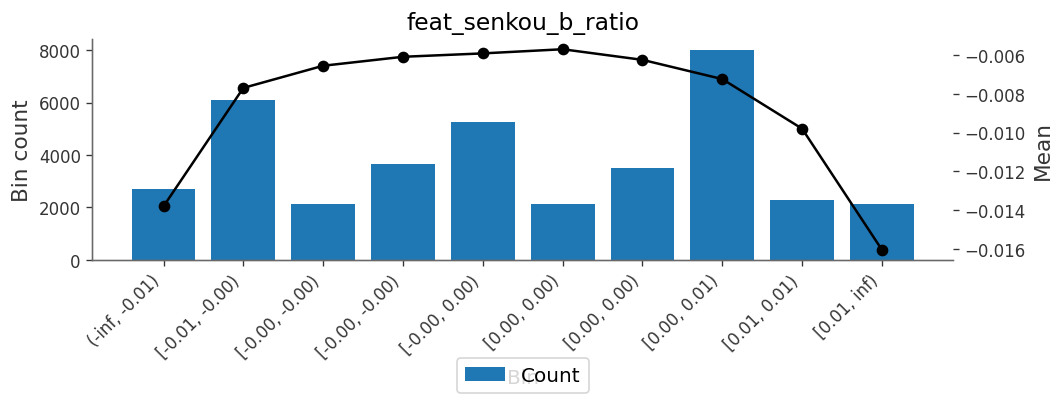




### feat_tenkan_ratio


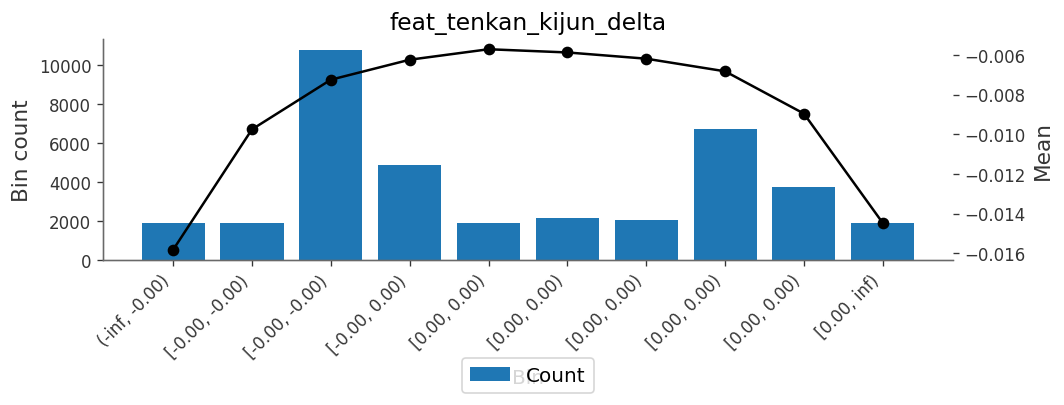



:::


## Donchian

**Donchian-csatorna (Donchian)** — az ár elhelyezkedése és a csatorna szélessége W bár alatt.
A Donchian-csatorna felső határa a W-periódusos gördülő maximum (rolling max),
alsó határa a gördülő minimum (rolling min).
Kitörés-jelzőként és range-volatilitás mérőként egyaránt használatos.
Ablakméret: 10, 30, 60 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `donchian_breakout_10` | close >= rolling_max_10(H) => 10-bari Donchian kitorés (1/0) |
| `donchian_breakout_30` | close >= rolling_max_30(H) => 30-bari Donchian kitorés (1/0) |
| `donchian_breakout_60` | close >= rolling_max_60(H) => 60-bari Donchian kitorés (1/0) |
| `donchian_position_10` | (close - rolling_min_10) / (rolling_max_10 - rolling_min_10) — pozicio a csatornan (0=aljan, 1=tetején) |
| `donchian_position_30` | (close - rolling_min_30) / (rolling_max_30 - rolling_min_30) — pozicio a csatornan (0=aljan, 1=tetején) |
| `donchian_position_60` | (close - rolling_min_60) / (rolling_max
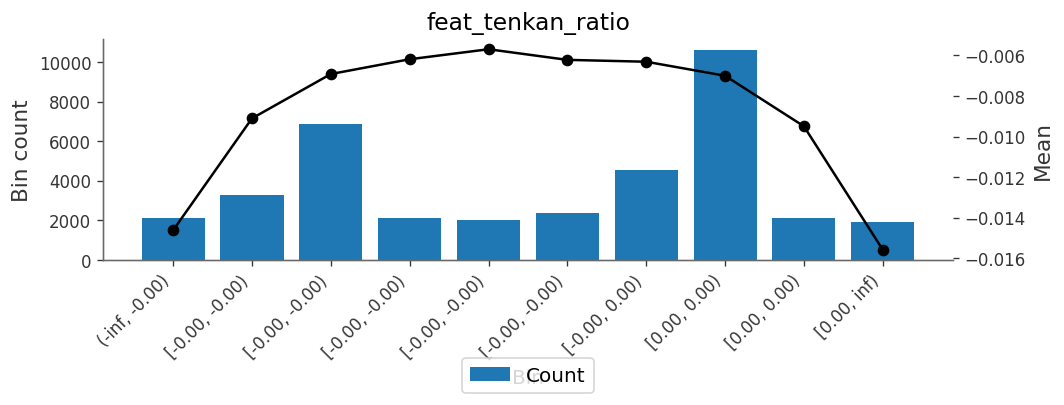



::: {.panel-tabset}


### feat_donchian_position_10




### feat_donchian_position_30


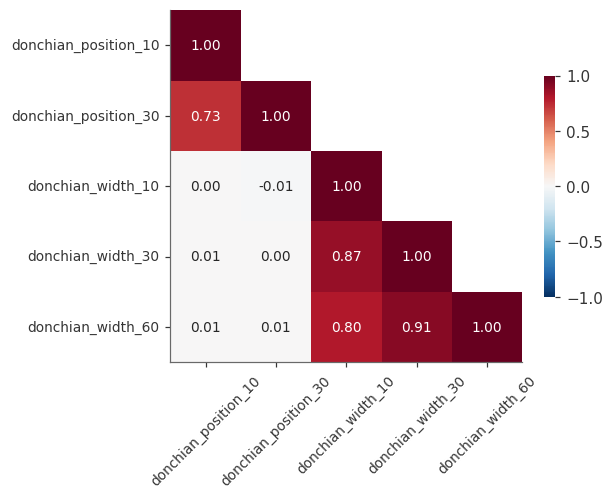
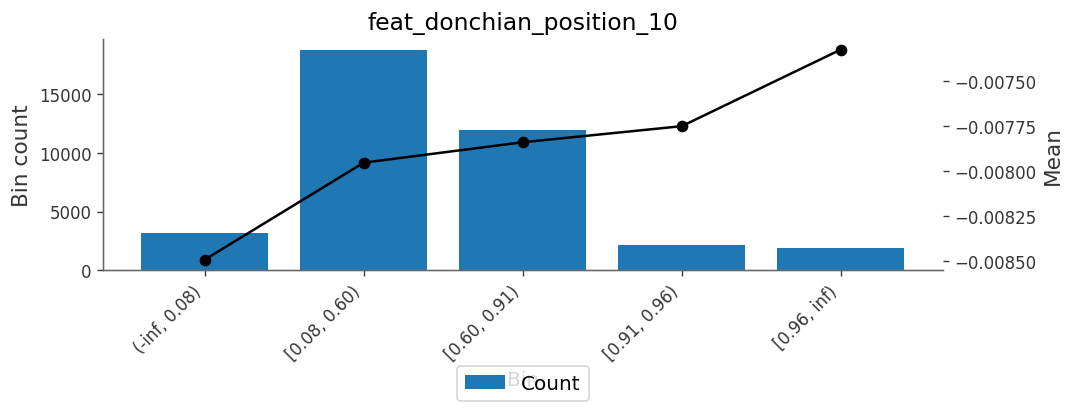




### feat_donchian_width_10


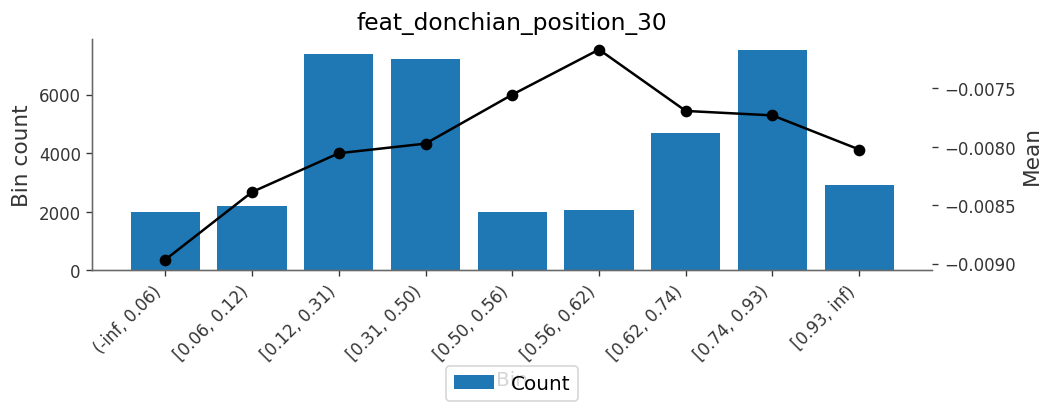




### feat_donchian_width_30


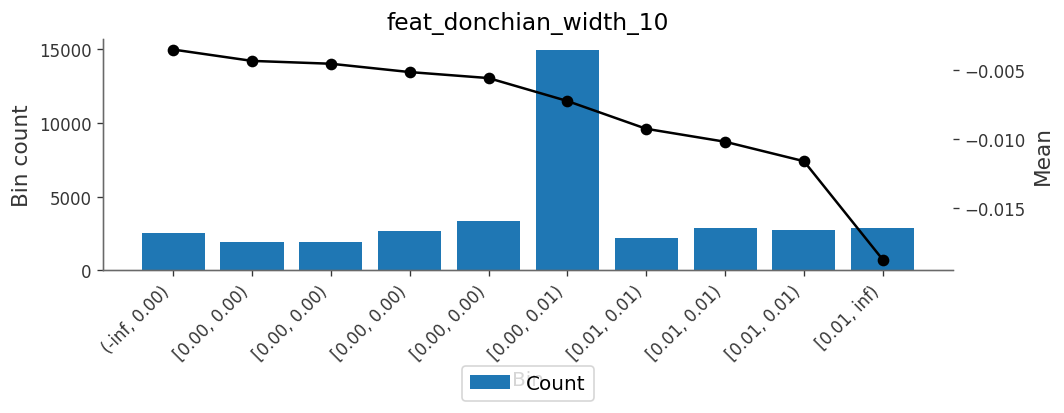




### feat_donchian_width_60


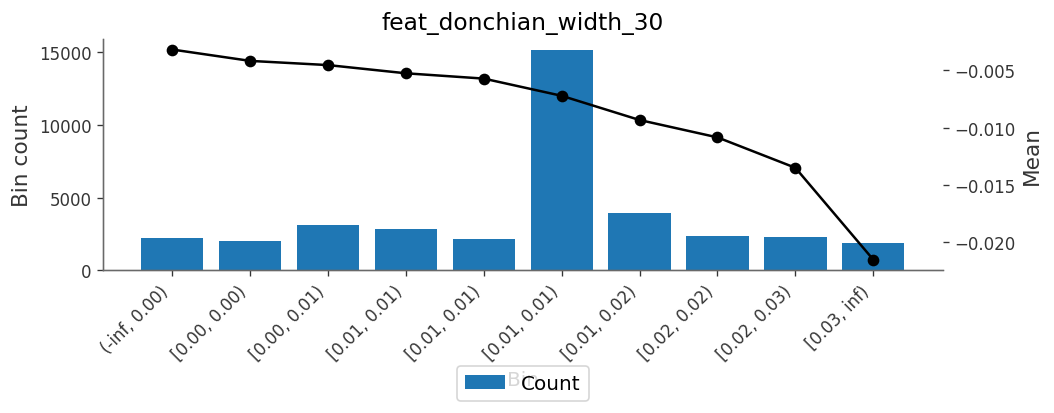



:::


## Trend Slope

**Trend meredeksége (Trend Slope)** — EMA változásának sebessége és lineáris regressziós jellemzők.

- **ema_slope_W**: (EMA_W(t) - EMA_W(t-1)) / close — pillanatnyi meredekség, normalizálva

- **lr_slope_W**: OLS lineáris regresszió meredeksége W bárra illesztve, close-szal normalizálva

- **lr_r2_W**: OLS R2 — mennyire "lineáris" a trend (0 = semmi, 1 = tökéletes)

- **lr_residual_W**: (close - OLS_hat) / close — ár eltérése a trendvonaltól

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `ema_slope_10` | (EMA_10(t) - EMA_10(t-1)) / close — EMA 10 pillanatnyi meredeksege (close-normalizalva) |
| `ema_slope_30` | (EMA_30(t) - EMA_30(t-1)) / close — EMA 30 pillanatnyi meredeksege (close-normalizalva) |
| `lr_r2_10` | OLS R2 10-barra — illeszkedés minősége (0=semmi, 1=tokéletes linearis trend) |
| `lr_r2_30` | OLS R2 30-barra — illeszkedés minősége (0=semmi, 1=tokéletes linearis trend) |
| `lr_r2_60` | OLS R2 60-barra — illeszkedés minősége (0=semmi
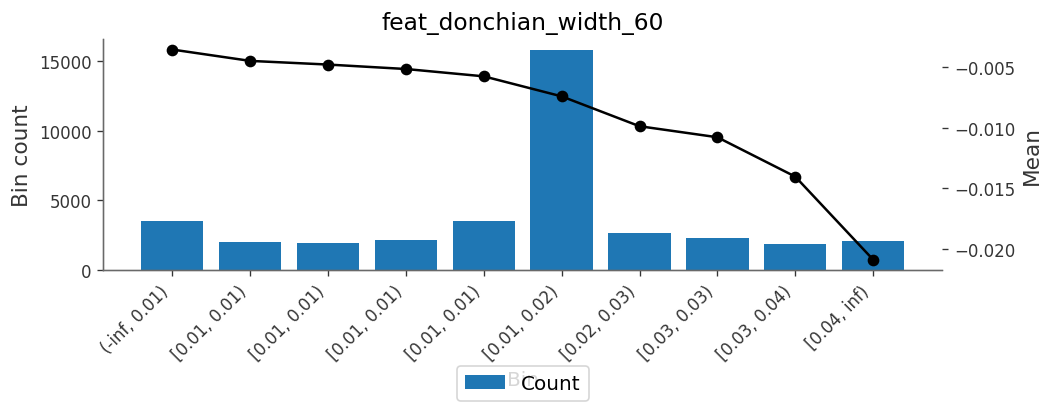



::: {.panel-tabset}


### feat_ema_slope_10


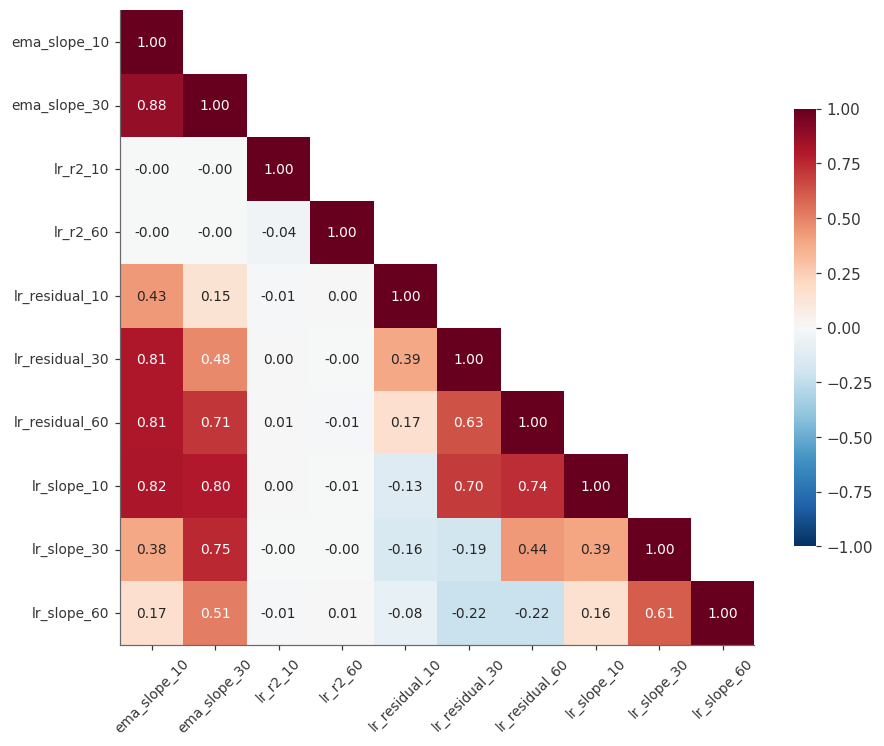




### feat_ema_slope_30


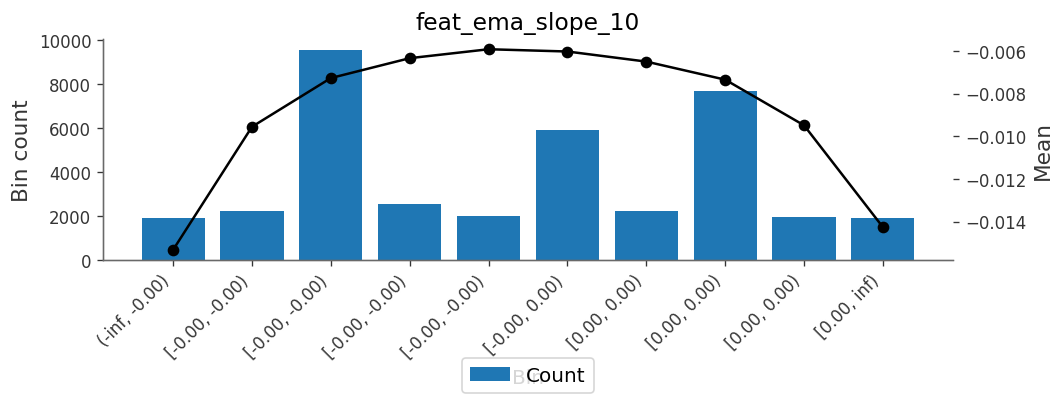




### feat_lr_r2_10


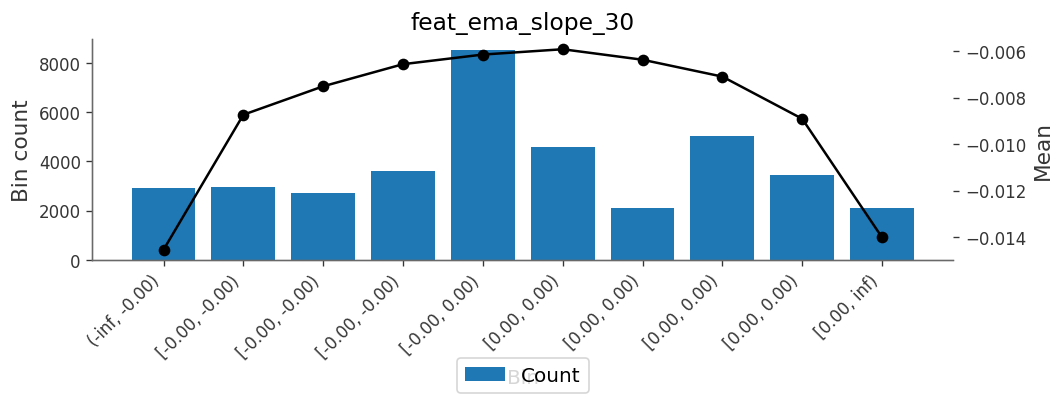




### feat_lr_r2_60


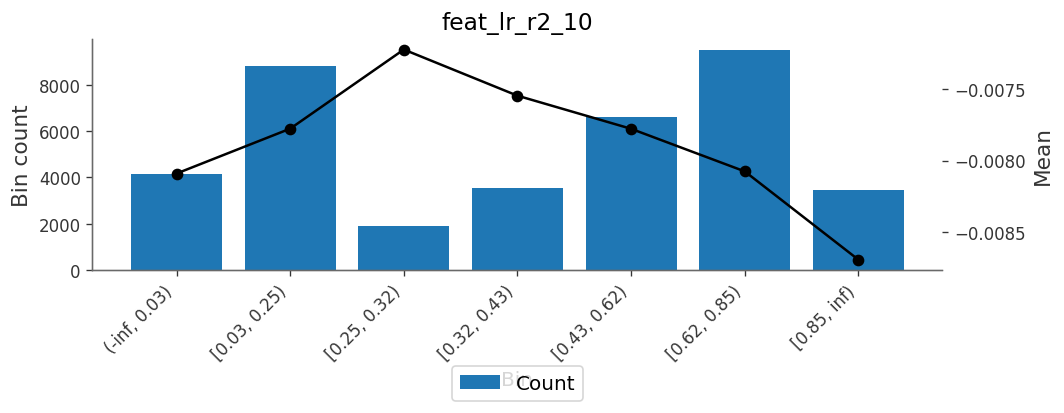




### feat_lr_residual_10


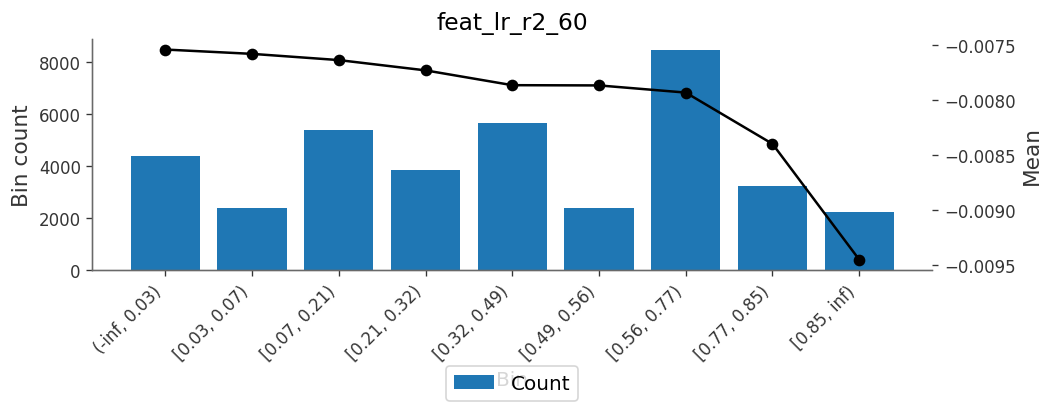




### feat_lr_residual_30


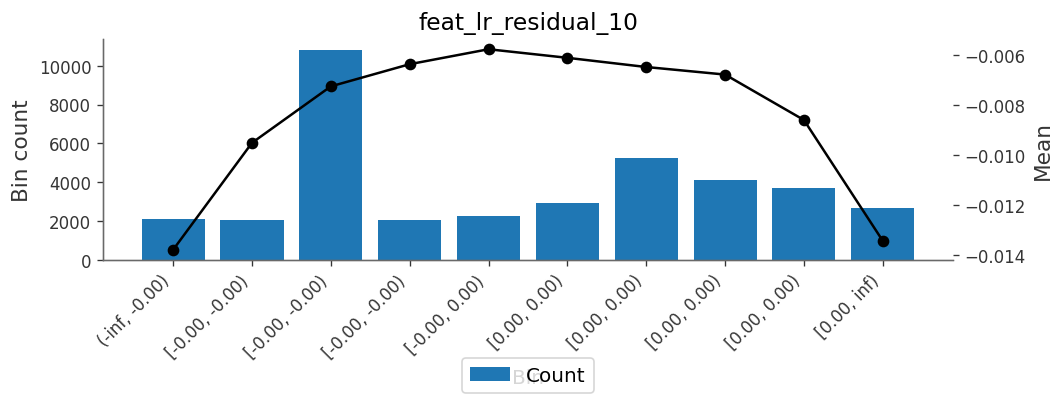




### feat_lr_residual_60


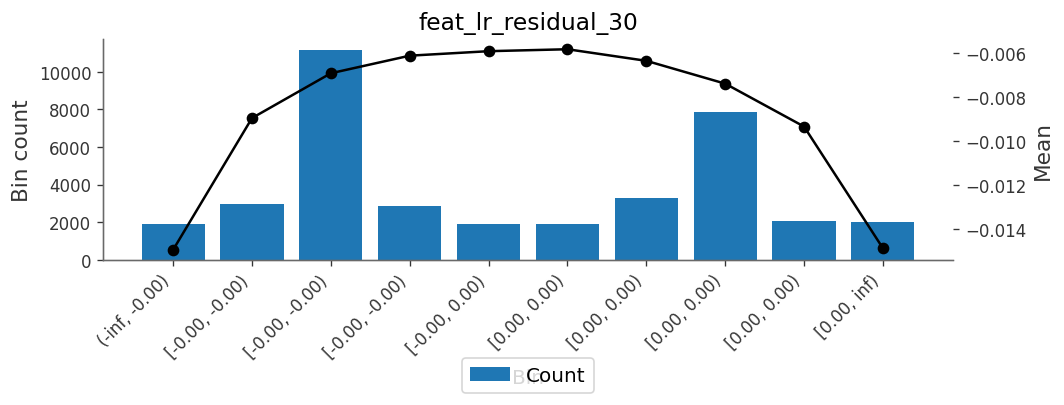




### feat_lr_slope_10


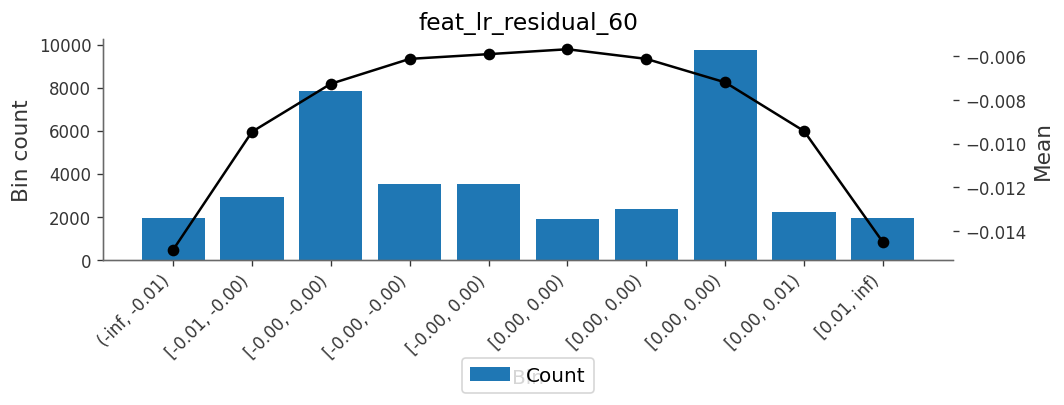




### feat_lr_slope_30


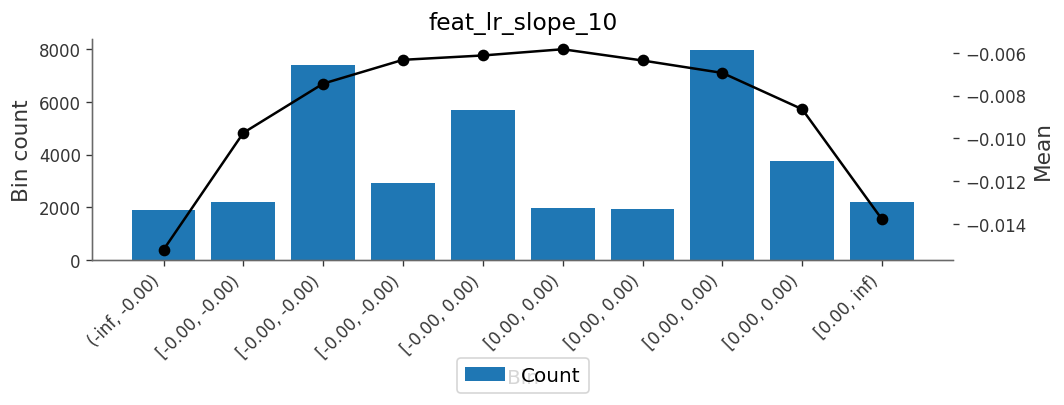




### feat_lr_slope_60


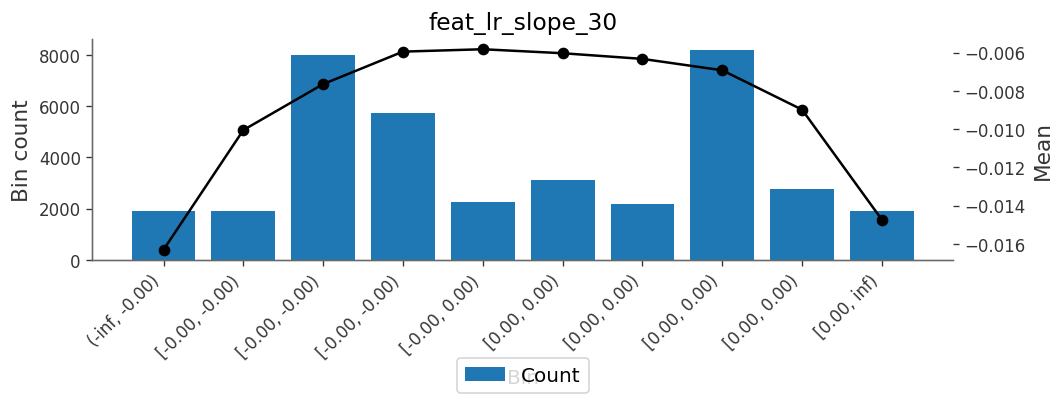



:::


## Accel

**Gyorsulás (Accel)** — momentum-indikátorok változásának sebessége (2. derivált).
Azt méri, hogy az RSI, ROC és a 10-bári return-momentum az előző W bárhoz képest mennyit változott.
Gyorsuló pozitív momentum erősödő trendet, gyorsuló negatív értékek lassulást vagy fordulatot jelezhetnek.
Ablakméret: 10 és 30 bár.

| Feature | Leírás & Képlet |
|:--------|:----------------|
| `return_momentum_delta_10` | ret10(t) - ret10(t-10) — ahol ret10 = close/close[-10]-1, 10-bari valtozasa |
| `return_momentum_delta_30` | ret10(t) - ret10(t-30) — ahol ret10 = close/close[-10]-1, 30-bari valtozasa |
| `roc_delta_10` | ROC14(t) - ROC14(t-10) — 14-periodusos ROC ertekenek 10-bari valtozasa |
| `roc_delta_30` | ROC14(t) - ROC14(t-30) — 14-periodusos ROC ertekenek 30-bari valtozasa |
| `roc_delta_5` | ROC14(t) - ROC14(t-5) — 14-periodusos ROC ertekenek 5-bari valtozasa |
| `rsi_delta_10` | RSI(t) - RSI(t-10) — Wilder EWM RSI-14 ertekenek 10-bari valtozasa |
| `rsi_delta_30` | RSI(t) 
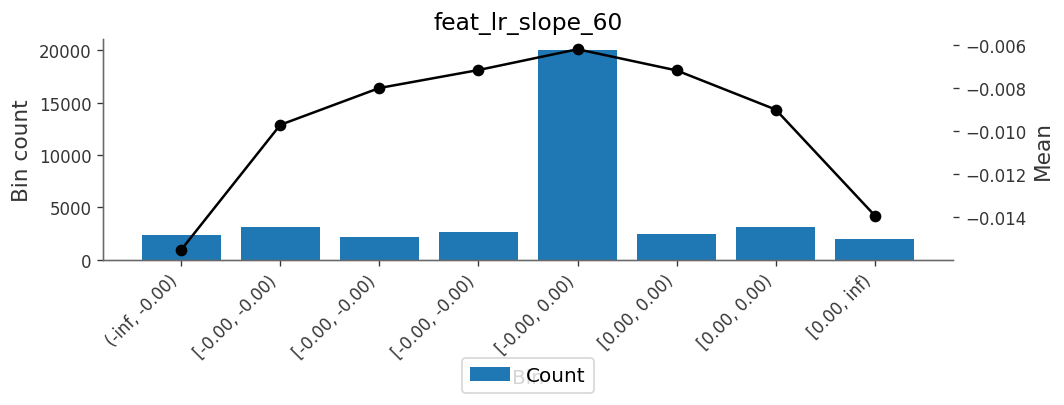



::: {.panel-tabset}


### feat_return_momentum_delta_10


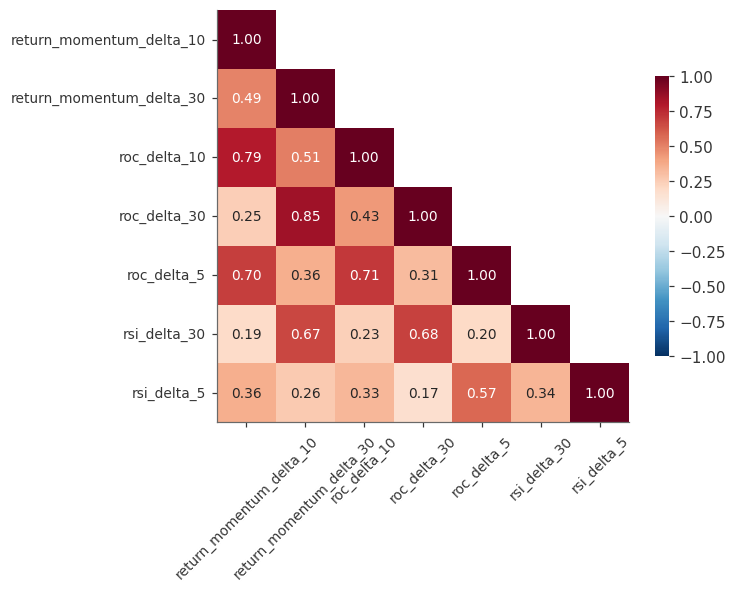




### feat_return_momentum_delta_30


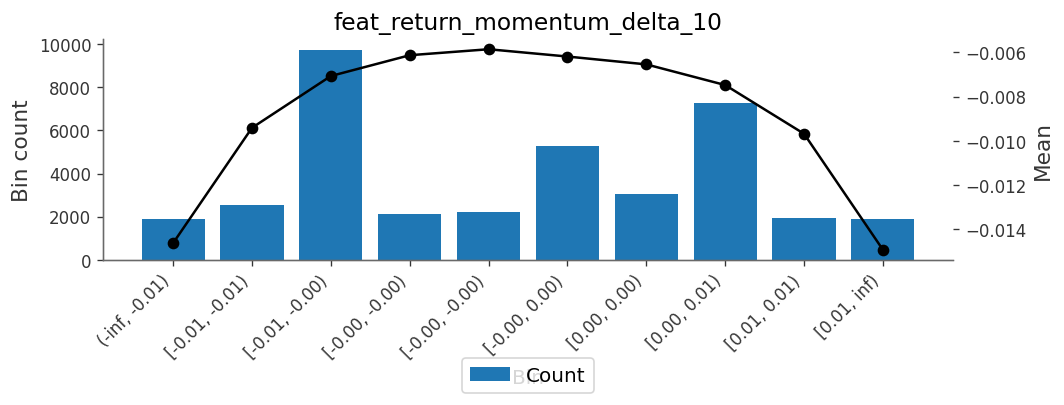




### feat_roc_delta_10


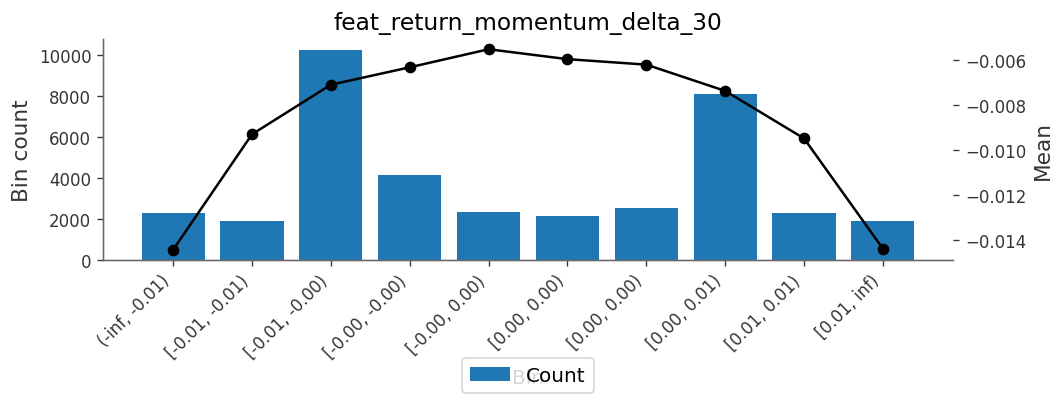




### feat_roc_delta_30


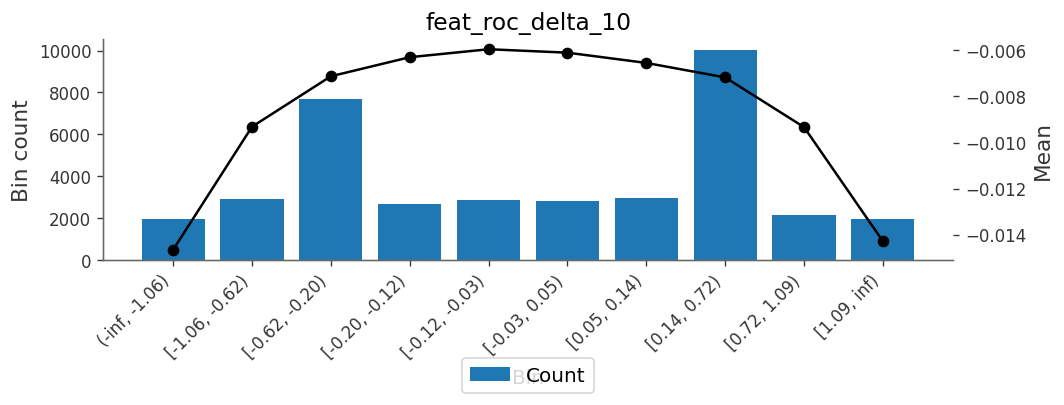




### feat_roc_delta_5


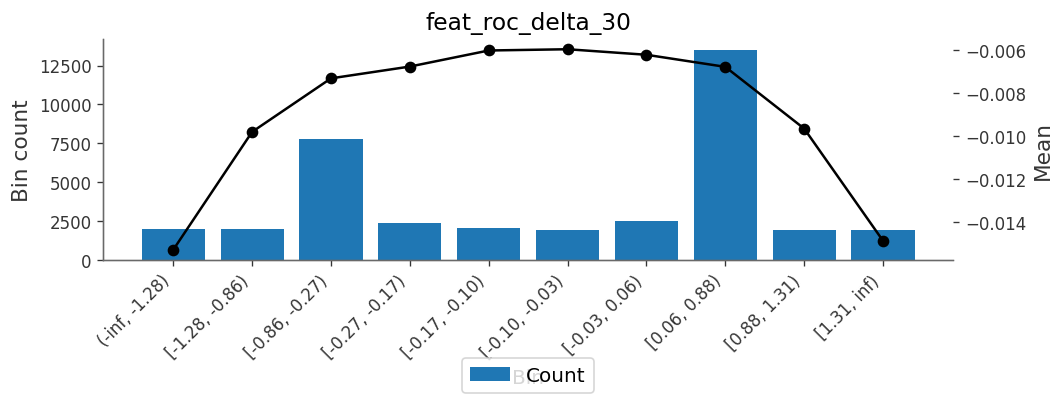




### feat_rsi_delta_30


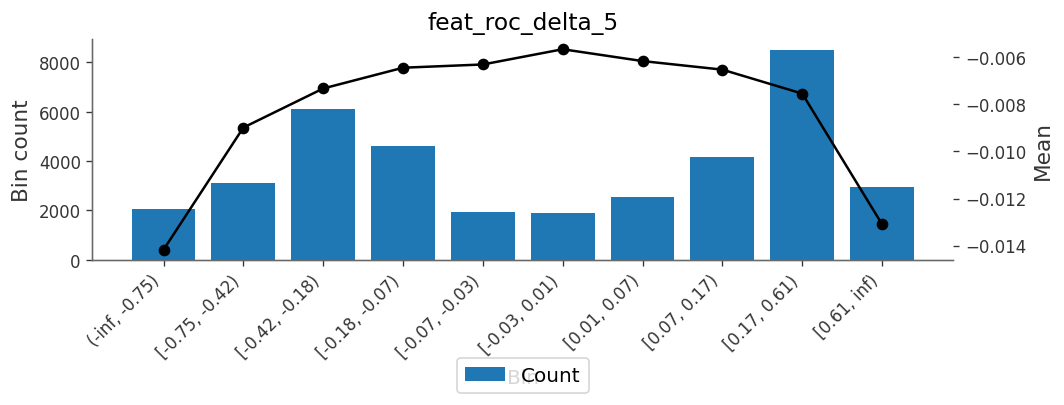




### feat_rsi_delta_5


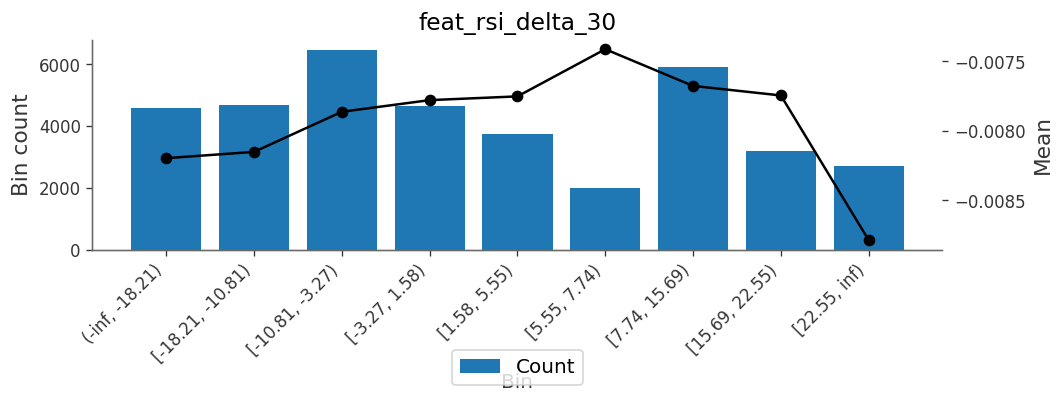



:::


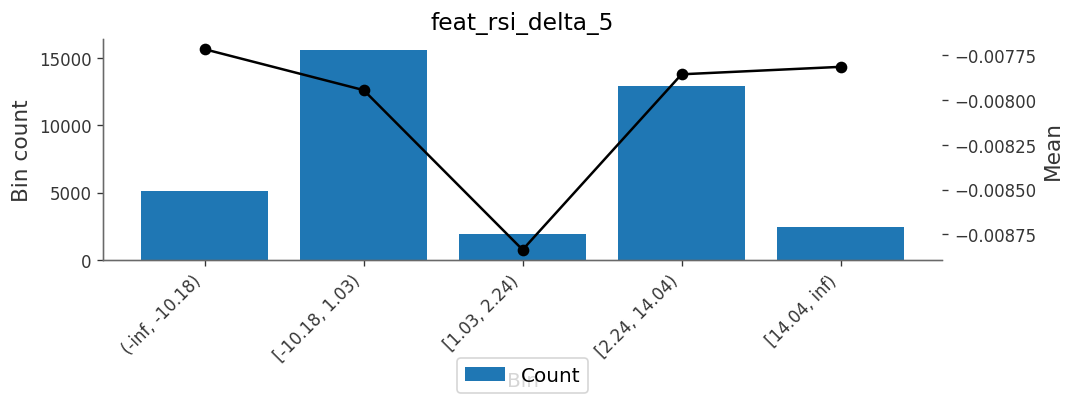

In [6]:
#| output: asis
#| echo: false
#| warning: false

TABSET_OPEN  = "::: {.panel-tabset}"
TABSET_CLOSE = ":::"

# Logikai sorrend: alapindikátorok előbb, levezetett indikátorok utána
GROUP_ORDER = [
    "Price Action",    # alap: log-return, range-arányok
    "Volatility",      # alap: ATR, BB, hist-vol — Market Structure is használja
    "Volume",          # alap: OBV, MFI, CMF
    "Gap",             # alap: nyitógap
    "Candle Pattern",  # alap: OHLC gyertyaalak
    "Time/Session",    # alap: időkódolás
    "Taker Flow",      # alap: exchange-specifikus taker adatok
    "Momentum",        # 1. szint: RSI, ROC, Stochastic — Accel is ezeket használja
    "Trend",           # 1. szint: MA-ratio, MACD — Trend Slope ezekre épül
    "Autocorrelation", # 1. szint: return autokorrelációk
    "Market Structure",# 2. szint: ATR-norm. távolságok, drawdown (használja Volatility ATR-jét)
    "Swing",           # 2. szint: higher high/low számolás
    "Tail Risk",       # 2. szint: return aszimmetria
    "Ichimoku",        # 2. szint: komplex trendrendszer (9/26/52)
    "Donchian",        # 2. szint: csatorna-alapú pozíció
    "Trend Slope",     # 3. szint: EMA/LR meredekség — Trend MA-ra épül
    "Accel",           # 3. szint: RSI/ROC delta — Momentum-ra épül
]

_available = set(groups_df["Group"].unique())
_ordered_groups = [g for g in GROUP_ORDER if g in _available] + \
                  sorted(g for g in _available if g not in set(GROUP_ORDER))

MI_THRESHOLD   = 0.001   # MI <= ennél: biztosan kizár (sem plot, sem korreláció)
CORR_THRESHOLD = 0.98    # |r| >= ennél: duplikátum-pár, a kisebb MI-jű kiesik

# ── Globális szelekciós akkumulátorok (feature_set.json-hoz) ────────────────
_fs_selected     = []   # feature neve
_fs_dropped_mi   = {}   # feat -> reason
_fs_dropped_corr = {}   # feat -> reason
_fs_dropped_qual = {f: 'quality: null/inf/variance' for f in feat_cols_quality_dropped}

for group in _ordered_groups:
    feats_in_group = sorted(groups_df[groups_df["Group"] == group]["Feature"].tolist())

    # ── Szűrési logika ────────────────────────────────────────────────────────
    # 1. lépés: MI küszöb
    feats_mi_ok = [f for f in feats_in_group
                   if iv_results.get(f, {}).get("mi", 0) > MI_THRESHOLD]

    # 2. lépés: korrelációs duplikátum-szűrés (csak MI-ok feature-ök között)
    corr_dedup = {}   # feat -> "duplikátuma X-nek"
    if len(feats_mi_ok) >= 2:
        _cm = df_train[feats_mi_ok].corr().abs()
        _seen = set()
        for i, fa in enumerate(feats_mi_ok):
            if fa in _seen:
                continue
            for fb in feats_mi_ok[i+1:]:
                if fb in _seen:
                    continue
                if _cm.loc[fa, fb] >= CORR_THRESHOLD:
                    mi_a = iv_results.get(fa, {}).get("mi", 0)
                    mi_b = iv_results.get(fb, {}).get("mi", 0)
                    drop = fb if mi_a >= mi_b else fa
                    keep = fa if mi_a >= mi_b else fb
                    corr_dedup[drop] = keep
                    _seen.add(drop)

    feats_pass = [f for f in feats_mi_ok if f not in corr_dedup]

    # ── Globális akkumulátor feltöltése ─────────────────────────────────────
    for _f in feats_in_group:
        _mi_val = iv_results.get(_f, {}).get('mi', 0)
        if _mi_val != _mi_val or _mi_val <= MI_THRESHOLD:
            _fs_dropped_mi[_f] = f'mi <= {MI_THRESHOLD} (mi={_mi_val:.5f})'
        elif _f in corr_dedup:
            _fs_dropped_corr[_f] = f'duplikatum -> {corr_dedup[_f]}'
        else:
            _fs_selected.append(_f)

    # ── Döntés map minden feature-hez ────────────────────────────────────────
    def _dontes(f):
        mi_val = iv_results.get(f, {}).get("mi", float("nan"))
        if mi_val != mi_val or mi_val <= MI_THRESHOLD:
            return "✗ kizár (MI)"
        if f in corr_dedup:
            return f"✗ duplikátum → {corr_dedup[f].replace('feat_','')}"
        return ""

    print(f"\n## {group}\n")

    # ── a) Csoport + feature leírás ──────────────────────────────────────────
    if group in GROUP_DOCS:
        doc = GROUP_DOCS[group].replace("\n- ", "\n\n- ")
        print(doc)
        print()

    feat_rows = []
    for f in feats_in_group:
        desc = _feat_desc(f).replace(" | ", " — ")
        if desc:
            short = f.replace("feat_", "")
            feat_rows.append(f"| `{short}` | {desc} |")

    if feat_rows:
        print("| Feature | Leírás & Képlet |")
        print("|:--------|:----------------|")
        for row in feat_rows:
            print(row)
        print()

    # ── b) IV + MI tábla (minden feature, döntés jelöléssel) ─────────────────
    group_iv_rows = []
    for f in feats_in_group:
        res = iv_results.get(f, {})
        mi_val = res.get("mi", float("nan"))
        group_iv_rows.append({
            "Feature": f,
            "IV":      round(res.get("iv", float("nan")), 5),
            "MI":      round(mi_val, 5),
            "N_bins":  res.get("n_bins", 0),
            "Döntés": _dontes(f),
        })
    group_iv_df = (
        pd.DataFrame(group_iv_rows)
        .sort_values("MI", ascending=False)
        .reset_index(drop=True)
    )
    print(analysis_table_html(group_iv_df))

    # ── c) Korrelációs mátrix (csak feats_pass) ───────────────────────────────
    if len(feats_pass) >= 2:
        corr_data = df_train[feats_pass].corr()

        n       = len(feats_pass)
        cell_sz = 0.55
        margin  = 2.0
        fig_h   = max(4.0, n * cell_sz + margin)
        fig_w   = max(5.0, n * cell_sz + margin + 1.0)
        lbl_sz  = max(6, min(9, 90 // n))
        ann_sz  = max(6, min(9, 100 // n))
        mask    = np.triu(np.ones_like(corr_data, dtype=bool), k=1)

        with plt.rc_context({"axes.grid": False}):
            fig_c, ax_c = plt.subplots(figsize=(fig_w, fig_h))
            sns.heatmap(
                corr_data,
                ax=ax_c,
                mask=mask,
                cmap="RdBu_r",
                center=0,
                vmin=-1, vmax=1,
                annot=(n <= 20),
                fmt=".2f",
                annot_kws={"size": ann_sz},
                linewidths=0,
                square=True,
                cbar_kws={"shrink": 0.6},
                xticklabels=[f.replace("feat_", "") for f in feats_pass],
                yticklabels=[f.replace("feat_", "") for f in feats_pass],
            )
            ax_c.tick_params(axis="x", rotation=45, labelsize=lbl_sz)
            ax_c.tick_params(axis="y", rotation=0,  labelsize=lbl_sz)
            for sp in ("top", "right"):
                ax_c.spines[sp].set_visible(False)
            for sp in ("left", "bottom"):
                ax_c.spines[sp].set_visible(True)
                ax_c.spines[sp].set_color(plt.rcParams["axes.edgecolor"])
            fig_c.tight_layout()

        buf_c = io.BytesIO()
        fig_c.savefig(buf_c, format="png", dpi=110, bbox_inches="tight")
        plt.close(fig_c)
        buf_c.seek(0)
        img_c_b64 = base64.b64encode(buf_c.read()).decode("utf-8")
        print(f'<img src="data:image/png;base64,{img_c_b64}" style="max-width:900px; margin-bottom:1rem;"/>\n')

    # ── d) Tabset — csak feats_pass ───────────────────────────────────────────
    if not feats_pass:
        print("*Minden feature kizárva (MI küszöb vagy duplikátum) — nincs megjeleníthető plot.*\n")
    else:
        print(TABSET_OPEN + "\n")

        for feat in feats_pass:
            print(f"\n### {feat}\n")

            res = iv_results.get(feat, {})
            ob  = res.get("ob")

            if ob is None:
                print("*Nem elégséges adat a binninghez.*\n")
                continue

            _show_bak = plt.show
            plt.show = lambda *a, **kw: None
            try:
                ob.binning_table.plot(
                    add_special=False,
                    add_missing=False,
                    show_bin_labels=True,
                    figsize=(9, 4),
                )
                fig = plt.gcf()
                for ax in fig.get_axes():
                    ax.grid(False)
                fig.tight_layout()
            finally:
                plt.show = _show_bak

            buf = io.BytesIO()
            fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
            plt.close(fig)
            buf.seek(0)
            img_b64 = base64.b64encode(buf.read()).decode("utf-8")

            print(f'<img src="data:image/png;base64,{img_b64}" style="max-width:820px;"/>\n')

        print(TABSET_CLOSE + "\n")

## Összefoglaló — Feature szelekció eredménye

Csoport-bajnokok (legjobb MI), Top 10, és teljes kizárási lista MI szerint rendezve.


In [7]:
#| label: tbl-summary
#| echo: false

import pandas as _pd

# ── Összes feature összefoglaló DataFrame ────────────────────────────────────
_summary_rows = []

# 1. Quality-passed features (van MI értékük, szerepelnek feat_cols-ban)
for _f in feat_cols:
    _mi  = iv_results.get(_f, {}).get("mi", float("nan"))
    _iv  = iv_results.get(_f, {}).get("iv", float("nan"))
    _grp = assign_group(_f)
    if _f in _fs_dropped_corr:
        _dec = f"duplikátum → {_fs_dropped_corr[_f].replace('feat_', '')}"
    elif _f in _fs_dropped_mi:
        _dec = f"MI ≤ {MI_THRESHOLD}"
    else:
        _dec = "✓ selected"
    _summary_rows.append({"feature": _f.replace("feat_", ""), "group": _grp,
                           "mi": _mi, "iv": _iv, "decision": _dec, "full_name": _f})

# 2. Quality-dropped features (nincs MI érték)
for _f in feat_cols_quality_dropped:
    _summary_rows.append({"feature": _f.replace("feat_", ""), "group": assign_group(_f),
                           "mi": float("nan"), "iv": float("nan"),
                           "decision": "quality: null/inf/variance", "full_name": _f})

summary_df = _pd.DataFrame(_summary_rows).sort_values("mi", ascending=False, na_position="last")
summary_df["mi_disp"] = summary_df["mi"].apply(lambda x: f"{x:.4f}" if x == x else "—")
summary_df["iv_disp"] = summary_df["iv"].apply(lambda x: f"{x:.5f}" if x == x else "—")

# ── Selected features MI sorrendben ──────────────────────────────────────────
_sel_df = summary_df[summary_df["decision"] == "✓ selected"].copy()

# ── Top 10 (MI szerint, selected) ────────────────────────────────────────────
top10_feats = _sel_df["full_name"].head(10).tolist()

# ── Csoport bajnokok: legjobb selected feature csoportonként (MI szerint) ─────
_grp_best_name = {}
_grp_best_feat = {}
for _, _row in _sel_df.iterrows():
    _g = _row["group"]
    if _g not in _grp_best_feat:
        _grp_best_feat[_g] = _row["full_name"]
        _grp_best_name[_g]  = _row["feature"]
top1_per_group_feats = list(_grp_best_feat.values())

# ─────────────────────────────────────────────────────────────────────────────
# TÁBLA 1 — Csoport bajnokok
# ─────────────────────────────────────────────────────────────────────────────
_champ_rows = []
for _g, _fname in _grp_best_name.items():
    _mi_v = _sel_df[_sel_df["feature"] == _fname]["mi_disp"].values[0]
    _champ_rows.append(f"| {_g} | {_fname} | {_mi_v} |")

display(Markdown(
    f"### Csoport bajnokok ({len(_grp_best_feat)} csoport, legjobb selected feature MI szerint)\n\n"
    "| Csoport | Feature | MI |\n"
    "|---------|---------|-----|\n"
    + "\n".join(_champ_rows)
))

# ─────────────────────────────────────────────────────────────────────────────
# TÁBLA 2 — Top 10
# ─────────────────────────────────────────────────────────────────────────────
_top10_rows = [
    f"| {i+1} | {r['feature']} | {r['group']} | {r['mi_disp']} | {r['iv_disp']} |"
    for i, (_, r) in enumerate(_sel_df.head(10).iterrows())
]
display(Markdown(
    "### Top 10 feature (MI szerint)\n\n"
    "| # | Feature | Csoport | MI | IV |\n"
    "|---|---------|---------|-----|-----|\n"
    + "\n".join(_top10_rows)
))

# ─────────────────────────────────────────────────────────────────────────────
# TÁBLA 3 — Teljes lista MI szerint (selected + dropped)
# ─────────────────────────────────────────────────────────────────────────────
_all_rows = [
    f"| {r['feature']} | {r['group']} | {r['mi_disp']} | {r['iv_disp']} | {r['decision']} |"
    for _, r in summary_df.iterrows()
]
display(Markdown(
    f"### Összes feature MI szerint rendezve ({len(summary_df)} db)\n\n"
    "| Feature | Csoport | MI | IV | Döntés |\n"
    "|---------|---------|-----|-----|--------|\n"
    + "\n".join(_all_rows)
))

### Csoport bajnokok (17 csoport, legjobb selected feature MI szerint)

| Csoport | Feature | MI |
|---------|---------|-----|
| Volatility | natr_14 | 0.1236 |
| Tail Risk | neg_return_mean_60 | 0.1098 |
| Price Action | returns_std_14 | 0.1089 |
| Market Structure | max_drawdown_60 | 0.1008 |
| Donchian | donchian_width_60 | 0.0957 |
| Trend | ema_ratio_140 | 0.0509 |
| Ichimoku | kijun_ratio | 0.0493 |
| Momentum | roc_14 | 0.0471 |
| Trend Slope | lr_slope_60 | 0.0470 |
| Volume | ad_line | 0.0458 |
| Time/Session | day_open_return | 0.0415 |
| Accel | roc_delta_5 | 0.0412 |
| Taker Flow | taker_flow_confirmed_return_10 | 0.0331 |
| Gap | gap_open | 0.0239 |
| Candle Pattern | signed_body_ratio | 0.0176 |
| Autocorrelation | return_autocorr_lag1_30 | 0.0030 |
| Swing | higher_high_count_5 | 0.0021 |

### Top 10 feature (MI szerint)

| # | Feature | Csoport | MI | IV |
|---|---------|---------|-----|-----|
| 1 | natr_14 | Volatility | 0.1236 | 0.00295 |
| 2 | gk_vol_30 | Volatility | 0.1191 | 0.00298 |
| 3 | parkinson_vol_60 | Volatility | 0.1177 | 0.00296 |
| 4 | gk_vol_10 | Volatility | 0.1119 | 0.00299 |
| 5 | hist_vol_20 | Volatility | 0.1118 | 0.00273 |
| 6 | neg_return_mean_60 | Tail Risk | 0.1098 | 0.00295 |
| 7 | returns_std_14 | Price Action | 0.1089 | 0.00288 |
| 8 | pos_return_mean_60 | Tail Risk | 0.1032 | 0.00280 |
| 9 | max_drawdown_60 | Market Structure | 0.1008 | 0.00270 |
| 10 | donchian_width_60 | Donchian | 0.0957 | 0.00267 |

### Összes feature MI szerint rendezve (208 db)

| Feature | Csoport | MI | IV | Döntés |
|---------|---------|-----|-----|--------|
| natr_14 | Volatility | 0.1236 | 0.00295 | ✓ selected |
| gk_vol_30 | Volatility | 0.1191 | 0.00298 | ✓ selected |
| parkinson_vol_30 | Volatility | 0.1177 | 0.00294 | duplikátum → duplikatum -> gk_vol_30 |
| parkinson_vol_60 | Volatility | 0.1177 | 0.00296 | ✓ selected |
| gk_vol_60 | Volatility | 0.1165 | 0.00286 | duplikátum → duplikatum -> parkinson_vol_60 |
| gk_vol_10 | Volatility | 0.1119 | 0.00299 | ✓ selected |
| hist_vol_20 | Volatility | 0.1118 | 0.00273 | ✓ selected |
| neg_return_mean_60 | Tail Risk | 0.1098 | 0.00295 | ✓ selected |
| returns_std_14 | Price Action | 0.1089 | 0.00288 | ✓ selected |
| parkinson_vol_10 | Volatility | 0.1060 | 0.00298 | duplikátum → duplikatum -> gk_vol_10 |
| pos_return_mean_60 | Tail Risk | 0.1032 | 0.00280 | ✓ selected |
| max_drawdown_60 | Market Structure | 0.1008 | 0.00270 | ✓ selected |
| donchian_width_60 | Donchian | 0.0957 | 0.00267 | ✓ selected |
| donchian_width_30 | Donchian | 0.0951 | 0.00269 | ✓ selected |
| pos_return_mean_30 | Tail Risk | 0.0948 | 0.00265 | ✓ selected |
| hml_range | Price Action | 0.0947 | 0.00233 | ✓ selected |
| ohlc_range | Price Action | 0.0947 | 0.00231 | duplikátum → duplikatum -> hml_range |
| donchian_width_10 | Donchian | 0.0942 | 0.00265 | ✓ selected |
| max_drawdown_30 | Market Structure | 0.0904 | 0.00273 | ✓ selected |
| neg_return_mean_30 | Tail Risk | 0.0851 | 0.00285 | ✓ selected |
| max_drawdown_10 | Market Structure | 0.0842 | 0.00242 | ✓ selected |
| bb_width_140 | Volatility | 0.0758 | 0.00250 | ✓ selected |
| bb_width_14 | Volatility | 0.0755 | 0.00260 | ✓ selected |
| pos_return_mean_10 | Tail Risk | 0.0658 | 0.00209 | ✓ selected |
| neg_return_mean_10 | Tail Risk | 0.0640 | 0.00226 | ✓ selected |
| dist_rolling_low_10 | Market Structure | 0.0522 | 0.00176 | ✓ selected |
| dist_rolling_high_60 | Market Structure | 0.0516 | 0.00211 | ✓ selected |
| ema_ratio_140 | Trend | 0.0509 | 0.00201 | ✓ selected |
| dist_rolling_high_30 | Market Structure | 0.0506 | 0.00200 | ✓ selected |
| kijun_ratio | Ichimoku | 0.0493 | 0.00201 | ✓ selected |
| price_vs_kijun | Ichimoku | 0.0493 | 0.00201 | duplikátum → duplikatum -> kijun_ratio |
| tenkan_ratio | Ichimoku | 0.0487 | 0.00190 | ✓ selected |
| price_vs_tenkan | Ichimoku | 0.0486 | 0.00190 | duplikátum → duplikatum -> tenkan_ratio |
| senkou_b_ratio | Ichimoku | 0.0477 | 0.00197 | ✓ selected |
| sma_ratio_140 | Trend | 0.0476 | 0.00203 | duplikátum → duplikatum -> ema_ratio_140 |
| returns_sma_14 | Price Action | 0.0471 | 0.00185 | ✓ selected |
| roc_14 | Momentum | 0.0471 | 0.00185 | ✓ selected |
| lr_slope_60 | Trend Slope | 0.0470 | 0.00203 | ✓ selected |
| kama_ratio_10_2_30 | Trend | 0.0463 | 0.00195 | ✓ selected |
| ad_line | Volume | 0.0458 | 0.00053 | ✓ selected |
| return_10 | Price Action | 0.0440 | 0.00183 | ✓ selected |
| returns_log | Price Action | 0.0436 | 0.00180 | ✓ selected |
| return_60 | Price Action | 0.0436 | 0.00207 | ✓ selected |
| ema_slope_30 | Trend Slope | 0.0432 | 0.00199 | ✓ selected |
| lr_slope_10 | Trend Slope | 0.0429 | 0.00176 | ✓ selected |
| rolling_drawdown_60 | Market Structure | 0.0421 | 0.00199 | duplikátum → duplikatum -> dist_rolling_high_60 |
| lr_residual_30 | Trend Slope | 0.0419 | 0.00176 | ✓ selected |
| day_open_return | Time/Session | 0.0415 | 0.00193 | ✓ selected |
| ichimoku_cloud_thickness | Ichimoku | 0.0414 | 0.00206 | ✓ selected |
| roc_delta_5 | Accel | 0.0412 | 0.00166 | ✓ selected |
| dist_rolling_low_60 | Market Structure | 0.0409 | 0.00181 | ✓ selected |
| dist_rolling_high_10 | Market Structure | 0.0409 | 0.00187 | ✓ selected |
| roc_delta_30 | Accel | 0.0404 | 0.00184 | ✓ selected |
| atr_14 | Volatility | 0.0400 | 0.00132 | ✓ selected |
| roc_140 | Momentum | 0.0398 | 0.00196 | ✓ selected |
| lr_slope_30 | Trend Slope | 0.0398 | 0.00189 | ✓ selected |
| wma_ratio_14 | Trend | 0.0395 | 0.00178 | ✓ selected |
| return_30 | Price Action | 0.0392 | 0.00185 | ✓ selected |
| tenkan_kijun_delta | Ichimoku | 0.0389 | 0.00184 | ✓ selected |
| dist_rolling_low_30 | Market Structure | 0.0377 | 0.00180 | ✓ selected |
| rolling_drawdown_30 | Market Structure | 0.0370 | 0.00184 | duplikátum → duplikatum -> dist_rolling_high_30 |
| roc_delta_10 | Accel | 0.0363 | 0.00173 | ✓ selected |
| ema_slope_10 | Trend Slope | 0.0354 | 0.00175 | ✓ selected |
| ema_ratio_14 | Trend | 0.0351 | 0.00185 | ✓ selected |
| lr_residual_60 | Trend Slope | 0.0347 | 0.00179 | ✓ selected |
| return_momentum_delta_10 | Accel | 0.0346 | 0.00175 | ✓ selected |
| lr_residual_10 | Trend Slope | 0.0340 | 0.00173 | ✓ selected |
| return_momentum_delta_30 | Accel | 0.0340 | 0.00177 | ✓ selected |
| taker_flow_confirmed_return_10 | Taker Flow | 0.0331 | 0.00176 | ✓ selected |
| rolling_drawdown_10 | Market Structure | 0.0328 | 0.00150 | ✓ selected |
| sma_ratio_14 | Trend | 0.0317 | 0.00171 | duplikátum → duplikatum -> ema_ratio_14 |
| taker_flow_confirmed_return_30 | Taker Flow | 0.0303 | 0.00176 | duplikátum → duplikatum -> taker_flow_confirmed_return_10 |
| volume_sma_14 | Volume | 0.0276 | 0.00154 | ✓ selected |
| weekly_open_return | Time/Session | 0.0275 | 0.00151 | ✓ selected |
| gap_open | Gap | 0.0239 | 0.00108 | ✓ selected |
| obv | Volume | 0.0218 | 0.00050 | ✓ selected |
| volume_confirmed_return_30 | Volume | 0.0214 | 0.00129 | ✓ selected |
| macd_signal_12_26_9 | Trend | 0.0202 | 0.00107 | ✓ selected |
| volume_confirmed_return_10 | Volume | 0.0202 | 0.00124 | ✓ selected |
| macd_diff | Trend | 0.0191 | 0.00099 | ✓ selected |
| signed_body_ratio | Candle Pattern | 0.0176 | 0.00030 | ✓ selected |
| close_position | Price Action | 0.0134 | 0.00045 | ✓ selected |
| macd_12_26 | Trend | 0.0133 | 0.00116 | ✓ selected |
| body_ratio | Candle Pattern | 0.0130 | 0.00027 | ✓ selected |
| obv_roc_14 | Volume | 0.0122 | 0.00088 | ✓ selected |
| body_ratio_sma_30 | Candle Pattern | 0.0103 | 0.00080 | ✓ selected |
| atr_dist_low_30 | Market Structure | 0.0102 | 0.00028 | ✓ selected |
| bars_into_session_norm | Time/Session | 0.0095 | 0.00070 | ✓ selected |
| day_range_position | Time/Session | 0.0086 | 0.00056 | ✓ selected |
| adx_14 | Trend | 0.0083 | 0.00039 | ✓ selected |
| stoch_k_14 | Momentum | 0.0082 | 0.00010 | ✓ selected |
| williams_r_14 | Momentum | 0.0082 | 0.00010 | duplikátum → duplikatum -> stoch_k_14 |
| hour_sin | Time/Session | 0.0079 | 0.00080 | ✓ selected |
| volume_ratio_14 | Volume | 0.0071 | 0.00036 | ✓ selected |
| lower_wick_ratio | Candle Pattern | 0.0069 | 0.00061 | ✓ selected |
| time_since_low_60 | Market Structure | 0.0069 | 0.00033 | ✓ selected |
| dayofweek_sin | Time/Session | 0.0066 | 0.00050 | ✓ selected |
| recovery_ratio_10 | Market Structure | 0.0066 | 0.00014 | ✓ selected |
| cmf_20 | Volume | 0.0065 | 0.00016 | ✓ selected |
| trade_count_rank_30 | Taker Flow | 0.0064 | 0.00010 | ✓ selected |
| bb_width_rank_60 | Volatility | 0.0063 | 0.00013 | ✓ selected |
| prev_session_high_dist | Market Structure | 0.0063 | 0.00032 | ✓ selected |
| weekend | Time/Session | 0.0062 | 0.00062 | ✓ selected |
| prev_session_low_dist | Market Structure | 0.0062 | 0.00079 | ✓ selected |
| body_ratio_sma_10 | Candle Pattern | 0.0061 | 0.00061 | ✓ selected |
| upper_wick_ratio | Candle Pattern | 0.0059 | 0.00049 | ✓ selected |
| atr_dist_low_60 | Market Structure | 0.0058 | 0.00029 | ✓ selected |
| rsi_delta_5 | Accel | 0.0057 | 0.00011 | ✓ selected |
| avg_trade_quote_30 | Taker Flow | 0.0055 | 0.00057 | ✓ selected |
| donchian_position_10 | Donchian | 0.0051 | 0.00013 | ✓ selected |
| quote_volume_rank_10 | Taker Flow | 0.0050 | 0.00005 | ✓ selected |
| recovery_ratio_30 | Market Structure | 0.0050 | 0.00028 | ✓ selected |
| efficiency_ratio_60 | Market Structure | 0.0048 | 0.00047 | ✓ selected |
| quote_volume_ratio_60 | Taker Flow | 0.0046 | 0.00036 | ✓ selected |
| rsi_14 | Momentum | 0.0042 | 0.00040 | ✓ selected |
| adx_neg_14 | Trend | 0.0042 | 0.00026 | ✓ selected |
| recovery_ratio_60 | Market Structure | 0.0041 | 0.00033 | ✓ selected |
| time_since_high_10 | Market Structure | 0.0039 | 0.00008 | ✓ selected |
| trade_count_ratio_30 | Taker Flow | 0.0037 | 0.00015 | ✓ selected |
| taker_buy_quote_ratio_10 | Taker Flow | 0.0035 | 0.00062 | ✓ selected |
| donchian_position_30 | Donchian | 0.0035 | 0.00025 | ✓ selected |
| vol_adj_return_10 | Price Action | 0.0035 | 0.00016 | ✓ selected |
| volume_rank_10 | Volume | 0.0035 | 0.00006 | ✓ selected |
| bb_position_14 | Volatility | 0.0033 | 0.00015 | ✓ selected |
| atr_dist_high_10 | Market Structure | 0.0033 | 0.00008 | ✓ selected |
| return_z_10 | Price Action | 0.0033 | 0.00016 | duplikátum → duplikatum -> vol_adj_return_10 |
| taker_buy_base_ratio_30 | Taker Flow | 0.0031 | 0.00052 | ✓ selected |
| bb_position_140 | Volatility | 0.0031 | 0.00065 | ✓ selected |
| return_autocorr_lag1_30 | Autocorrelation | 0.0030 | 0.00027 | ✓ selected |
| wick_imbalance_sma_10 | Candle Pattern | 0.0030 | 0.00017 | ✓ selected |
| bull_bars_ratio_30 | Candle Pattern | 0.0030 | 0.00016 | ✓ selected |
| trade_count_accel_10_30 | Taker Flow | 0.0029 | 0.00018 | ✓ selected |
| trade_count_rank_10 | Taker Flow | 0.0029 | 0.00011 | ✓ selected |
| rsi_delta_30 | Accel | 0.0028 | 0.00025 | ✓ selected |
| lr_r2_10 | Trend Slope | 0.0027 | 0.00025 | ✓ selected |
| stoch_d_14 | Momentum | 0.0025 | 0.00013 | ✓ selected |
| taker_buy_base_ratio_10 | Taker Flow | 0.0025 | 0.00061 | duplikátum → duplikatum -> taker_buy_quote_ratio_10 |
| taker_buy_quote_ratio_30 | Taker Flow | 0.0024 | 0.00051 | duplikátum → duplikatum -> taker_buy_base_ratio_30 |
| hist_vol_rank_60 | Volatility | 0.0024 | 0.00028 | ✓ selected |
| higher_high_count_5 | Swing | 0.0021 | 0.00007 | ✓ selected |
| efficiency_ratio_10 | Market Structure | 0.0021 | 0.00017 | ✓ selected |
| time_since_low_10 | Market Structure | 0.0019 | 0.00012 | ✓ selected |
| mfi_14 | Volume | 0.0018 | 0.00014 | ✓ selected |
| atr_dist_high_30 | Market Structure | 0.0017 | 0.00021 | ✓ selected |
| hour_cos | Time/Session | 0.0015 | 0.00048 | ✓ selected |
| adx_pos_14 | Trend | 0.0015 | 0.00048 | ✓ selected |
| quote_volume_ratio_30 | Taker Flow | 0.0013 | 0.00030 | ✓ selected |
| dayofweek_cos | Time/Session | 0.0013 | 0.00050 | ✓ selected |
| lr_r2_60 | Trend Slope | 0.0012 | 0.00027 | ✓ selected |
| lower_low_count_5 | Swing | 0.0012 | 0.00019 | ✓ selected |
| cci_20 | Momentum | 0.0011 | 0.00018 | ✓ selected |
| engulf_bull | Candle Pattern | 0.0010 | 0.00000 | MI ≤ 0.001 |
| efficiency_ratio_30 | Market Structure | 0.0009 | 0.00036 | MI ≤ 0.001 |
| quote_volume_rank_30 | Taker Flow | 0.0009 | 0.00010 | MI ≤ 0.001 |
| time_since_high_60 | Market Structure | 0.0009 | 0.00038 | MI ≤ 0.001 |
| rsi_delta_10 | Accel | 0.0007 | 0.00009 | MI ≤ 0.001 |
| swing_high_5 | Swing | 0.0006 | 0.00015 | MI ≤ 0.001 |
| doji | Candle Pattern | 0.0005 | 0.00000 | MI ≤ 0.001 |
| shooting_star | Candle Pattern | 0.0005 | 0.00000 | MI ≤ 0.001 |
| swing_low_5 | Swing | 0.0004 | 0.00011 | MI ≤ 0.001 |
| wick_imbalance_sma_30 | Candle Pattern | 0.0004 | 0.00013 | MI ≤ 0.001 |
| return_asymmetry_10 | Tail Risk | 0.0002 | 0.00021 | MI ≤ 0.001 |
| trade_count_ratio_60 | Taker Flow | 0.0002 | 0.00025 | MI ≤ 0.001 |
| volume_accel_10_30 | Volume | 0.0001 | 0.00020 | MI ≤ 0.001 |
| donchian_breakout_10 | Donchian | 0.0001 | 0.00000 | MI ≤ 0.001 |
| natr_rank_20 | Volatility | 0.0000 | 0.00028 | MI ≤ 0.001 |
| returns_kurt_14 | Price Action | 0.0000 | 0.00015 | MI ≤ 0.001 |
| returns_skew_14 | Price Action | 0.0000 | 0.00011 | MI ≤ 0.001 |
| lower_high_count_5 | Swing | 0.0000 | 0.00028 | MI ≤ 0.001 |
| higher_low_count_5 | Swing | 0.0000 | 0.00015 | MI ≤ 0.001 |
| return_z_30 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| return_z_60 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| trade_count_ratio_10 | Taker Flow | 0.0000 | 0.00009 | MI ≤ 0.001 |
| quote_volume_ratio_10 | Taker Flow | 0.0000 | 0.00036 | MI ≤ 0.001 |
| bb_width_rank_20 | Volatility | 0.0000 | 0.00008 | MI ≤ 0.001 |
| hist_vol_rank_20 | Volatility | 0.0000 | 0.00014 | MI ≤ 0.001 |
| natr_rank_60 | Volatility | 0.0000 | 0.00039 | MI ≤ 0.001 |
| variance_ratio_10_60 | Autocorrelation | 0.0000 | 0.00024 | MI ≤ 0.001 |
| return_autocorr_lag5_60 | Autocorrelation | 0.0000 | 0.00012 | MI ≤ 0.001 |
| session_europe | Time/Session | 0.0000 | 0.00014 | MI ≤ 0.001 |
| return_autocorr_lag1_60 | Autocorrelation | 0.0000 | 0.00037 | MI ≤ 0.001 |
| return_autocorr_lag5_30 | Autocorrelation | 0.0000 | 0.00015 | MI ≤ 0.001 |
| session_us | Time/Session | 0.0000 | 0.00060 | MI ≤ 0.001 |
| session_asia | Time/Session | 0.0000 | 0.00041 | MI ≤ 0.001 |
| volume_rank_30 | Volume | 0.0000 | 0.00010 | MI ≤ 0.001 |
| range_expansion_10_30 | Market Structure | 0.0000 | 0.00021 | MI ≤ 0.001 |
| directional_agreement_10_30 | Swing | 0.0000 | 0.00016 | MI ≤ 0.001 |
| signed_body_sma_10 | Candle Pattern | 0.0000 | 0.00015 | MI ≤ 0.001 |
| signed_body_sma_30 | Candle Pattern | 0.0000 | 0.00040 | MI ≤ 0.001 |
| vol_adj_return_30 | Price Action | 0.0000 | 0.00016 | MI ≤ 0.001 |
| hammer | Candle Pattern | 0.0000 | 0.00000 | MI ≤ 0.001 |
| time_since_low_30 | Market Structure | 0.0000 | 0.00023 | MI ≤ 0.001 |
| time_since_high_30 | Market Structure | 0.0000 | 0.00026 | MI ≤ 0.001 |
| return_asymmetry_60 | Tail Risk | 0.0000 | 0.00055 | MI ≤ 0.001 |
| inside_bar | Candle Pattern | 0.0000 | 0.00009 | MI ≤ 0.001 |
| bull_bars_ratio_10 | Candle Pattern | 0.0000 | 0.00009 | MI ≤ 0.001 |
| engulf_bear | Candle Pattern | 0.0000 | 0.00000 | MI ≤ 0.001 |
| atr_dist_low_10 | Market Structure | 0.0000 | 0.00017 | MI ≤ 0.001 |
| bull_bars_ratio_60 | Candle Pattern | 0.0000 | 0.00014 | MI ≤ 0.001 |
| return_asymmetry_30 | Tail Risk | 0.0000 | 0.00051 | MI ≤ 0.001 |
| atr_dist_high_60 | Market Structure | 0.0000 | 0.00033 | MI ≤ 0.001 |
| outside_bar | Candle Pattern | 0.0000 | 0.00003 | MI ≤ 0.001 |
| donchian_breakout_30 | Donchian | 0.0000 | 0.00000 | MI ≤ 0.001 |
| lr_r2_30 | Trend Slope | 0.0000 | 0.00026 | MI ≤ 0.001 |
| donchian_position_60 | Donchian | 0.0000 | 0.00035 | MI ≤ 0.001 |
| donchian_breakout_60 | Donchian | 0.0000 | 0.00000 | MI ≤ 0.001 |
| gap_open_abs_sma_10 | Gap | — | — | quality: null/inf/variance |
| gap_open_abs_sma_30 | Gap | — | — | quality: null/inf/variance |

In [8]:
#| label: tbl-output-summary
#| echo: false

import json as _json
from datetime import datetime as _dt

_created_at = _dt.now().strftime('%Y-%m-%d %H:%M:%S')
_run_id     = _dt.now().strftime('run_%Y%m%d_%H%M%S')

_all_dropped = []
for _f, _r in _fs_dropped_qual.items():
    _all_dropped.append({'col': _f, 'reason': _r})
for _f, _r in _fs_dropped_mi.items():
    if _f not in _fs_dropped_qual:
        _all_dropped.append({'col': _f, 'reason': _r})
for _f, _r in _fs_dropped_corr.items():
    _all_dropped.append({'col': _f, 'reason': _r})

_asset_id   = MODEL_ID.split('_')[1] if len(MODEL_ID.split('_')) > 1 else 'solusdt'
_direction  = MODEL_ID.split('_')[2] if len(MODEL_ID.split('_')) > 2 else 'l'
_target_col = 'long_mfe_fw60' if _direction == 'l' else 'short_mfe_fw60'

feature_set = {
    'run_id'     : _run_id,
    'asset_id'   : _asset_id,
    'model_id'   : MODEL_ID,
    'target_col' : _target_col,
    'created_at' : _created_at,
    'target_cols': [_target_col],
    'selected'         : sorted(_fs_selected),
    'top10'            : top10_feats,
    'top1_per_group'   : top1_per_group_feats,
    'dropped'          : _all_dropped,
    'review'           : [],
    'provenance' : {
        'snapshot_id'  : SNAPSHOT_ID,
        'sample_rows'  : len(df_train),
        'min_open_time': str(df_train['open_time'].min()),
        'max_open_time': str(df_train['open_time'].max()),
    },
    'thresholds' : {
        'mi_threshold'  : MI_THRESHOLD,
        'corr_threshold': CORR_THRESHOLD,
        'max_null_rate' : 0.01,
        'max_inf_rate'  : 0.001,
        'min_variance'  : 1e-8,
    },
}

_fe_dir = ARTIFACT_DIR_PATH / 'feature_engineering'
_fe_dir.mkdir(parents=True, exist_ok=True)
_out_path = _fe_dir / 'feature_set.json'
_out_path.write_text(_json.dumps(feature_set, indent=4, ensure_ascii=False), encoding='utf-8')

display(Markdown(
    f'**Feature szelekció eredménye**\n\n'
    f'| Kategória | Darab |\n'
    f'|-----------|-------|\n'
    f'| selected  | {len(feature_set["selected"])} |\n'
    f'| top10     | {len(feature_set["top10"])} |\n'
    f'| top1_per_group | {len(feature_set["top1_per_group"])} |\n'
    f'| dropped (quality)    | {len(_fs_dropped_qual)} |\n'
    f'| dropped (MI)         | {len(_fs_dropped_mi)} |\n'
    f'| dropped (duplikátum) | {len(_fs_dropped_corr)} |\n'
    f'\n**Output:** `{_out_path}` \u2713'
))

**Feature szelekció eredménye**

| Kategória | Darab |
|-----------|-------|
| selected  | 136 |
| top10     | 10 |
| top1_per_group | 17 |
| dropped (quality)    | 2 |
| dropped (MI)         | 57 |
| dropped (duplikátum) | 15 |

**Output:** `D:\repos\chronoquant\artifacts\lgbm_solusdt_s_fw60_2101_2605\feature_engineering\feature_set.json` ✓